In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [3]:
activity_col = "Activity_S3_1"

# Shuffles

Shuffle position info

In [4]:
shuffle_vars = sog1_helpers.return_activities("_shuffle_size")
shuffle_vars#["Other"].value_counts()

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,NaN,NaN
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,NaN,NaN
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2489.0,1675.930350,NaN,1.0,NaN,NaN
3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,NaN,NaN
4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3568,410,449,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,NaN,NaN,NaN,NaN,NaN,NaN
3569,410,449,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,5709.0,3603.470121,NaN,1.0,NaN,NaN
3570,410,449,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,NaN,NaN,NaN,NaN,NaN,NaN
3571,410,449,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# There are 5 tiles
# 33-35 and 41, 42
shuffle_vars["Description"].str.split("_").str[0].value_counts()

Description
41    738
34    712
35    712
33    711
42    700
Name: count, dtype: int64

In [6]:
# WT tiles
BasicArTh = sog1_helpers.return_activities("BasicArTh", pos_regex = r'\.(\d+)')
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211


In [7]:
shuffle_vars_with_diff = sog1_helpers.add_all_var_positions(shuffle_vars, BasicArTh, activity_col, add_AAs = True)
shuffle_vars_with_diff.head(3)

,Start,End,Description_var,Other_var,mid,tile_var,Unnamed: 0_var,Activity_S3_1_var,Error_var,BC Count_var,...,Other_wt,tile_wt,Unnamed: 0_wt,Activity_S3_1_wt,Error_wt,BC Count_wt,activ_err_start_wt,activ_err_end_wt,vars,AAs
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2388,1002.138898,695.599801,18,306.539098,1697.738699,"[321, 322]","[E, M]"
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2388,1002.138898,695.599801,18,306.539098,1697.738699,"[323, 324]","[L, D]"
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2489.0,1675.93035,NaN,1.0,...,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2388,1002.138898,695.599801,18,306.539098,1697.738699,"[325, 326]","[D, K]"


In [8]:
shuffle_vars_with_diff["tile"] = shuffle_vars_with_diff["Description_var"].str.split("_").str[0].astype(int)
shuffle_vars_with_diff["shuffle_size"] = shuffle_vars_with_diff["Other_var"].str.split("shuffle_size").str[1].str.split("_").str[0].astype(int)
shuffle_vars_with_diff

,Start,End,Description_var,Other_var,mid,tile_var,Unnamed: 0_var,Activity_S3_1_var,Error_var,BC Count_var,...,Unnamed: 0_wt,Activity_S3_1_wt,Error_wt,BC Count_wt,activ_err_start_wt,activ_err_end_wt,vars,AAs,tile,shuffle_size
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,2388,1002.138898,695.599801,18,306.539098,1697.738699,"[321, 322]","[E, M]",33,2
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,2388,1002.138898,695.599801,18,306.539098,1697.738699,"[323, 324]","[L, D]",33,2
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2489.0,1675.930350,NaN,1.0,...,2388,1002.138898,695.599801,18,306.539098,1697.738699,"[325, 326]","[D, K]",33,2
3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,2388,1002.138898,695.599801,18,306.539098,1697.738699,"[329, 330]","[Q, E]",33,2
4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,2388,1002.138898,695.599801,18,306.539098,1697.738699,"[331, 332]","[K, D]",33,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,410,449,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,NaN,NaN,NaN,NaN,...,5672,2099.332725,1626.511035,19,472.821690,3725.843759,"[440, 441, 442, 443, 444, 445, 446, 447, 449]","[F, L, A, W, G, T, G, K, D]",42,10
3569,410,449,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,5709.0,3603.470121,NaN,1.0,...,5672,2099.332725,1626.511035,19,472.821690,3725.843759,"[440, 441, 442, 443, 444, 445, 446, 447, 448, ...","[F, L, A, W, G, T, G, K, T, D]",42,10
3570,410,449,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,NaN,NaN,NaN,NaN,...,5672,2099.332725,1626.511035,19,472.821690,3725.843759,"[440, 442, 443, 445, 447, 449]","[F, A, W, T, K, D]",42,10
3571,410,449,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,NaN,NaN,NaN,NaN,...,5672,2099.332725,1626.511035,19,472.821690,3725.843759,"[440, 441, 442, 443, 445, 446, 447, 448, 449]","[F, L, A, W, T, G, K, T, D]",42,10


In [9]:
shuffle_vars_with_diff.iloc[-1]

Start                                                                410
End                                                                  449
Description_var                           42_shuffle_size10_ss2_pos15_10
Other_var                                    shuffle_size10_ss2_pos15_10
mid                                                                  430
tile_var                        QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLFTKAGDTWG
Unnamed: 0_var                                                       NaN
Activity_S3_1_var                                                    NaN
Error_var                                                            NaN
BC Count_var                                                         NaN
activ_err_start_var                                                  NaN
activ_err_end_var                                                    NaN
Description_wt                                              BasicArTh.42
Other_wt                                           

In [10]:
shuffle_vars_with_diff["coordinates"] = shuffle_vars_with_diff["Description_var"].str.split("pos").str[-1]
shuffle_vars_with_diff["pos_start"] = shuffle_vars_with_diff["coordinates"].str.split("_").str[0].astype(int) 
shuffle_vars_with_diff["pos_start"] = shuffle_vars_with_diff["Start"] + 2 * shuffle_vars_with_diff["pos_start"]

shuffle_vars_with_diff["pos_end"] = shuffle_vars_with_diff["pos_start"] + shuffle_vars_with_diff["shuffle_size"]
shuffle_vars_with_diff

,Start,End,Description_var,Other_var,mid,tile_var,Unnamed: 0_var,Activity_S3_1_var,Error_var,BC Count_var,...,BC Count_wt,activ_err_start_wt,activ_err_end_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[321, 322]","[E, M]",33,2,0_1,321,323
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[323, 324]","[L, D]",33,2,1_1,323,325
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2489.0,1675.930350,NaN,1.0,...,18,306.539098,1697.738699,"[325, 326]","[D, K]",33,2,2_1,325,327
3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[329, 330]","[Q, E]",33,2,4_1,329,331
4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[331, 332]","[K, D]",33,2,5_1,331,333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,410,449,42_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSLWTGADFGTK,NaN,NaN,NaN,NaN,...,19,472.821690,3725.843759,"[440, 441, 442, 443, 444, 445, 446, 447, 449]","[F, L, A, W, G, T, G, K, D]",42,10,15_6,440,450
3569,410,449,42_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTTKGDALWFG,5709.0,3603.470121,NaN,1.0,...,19,472.821690,3725.843759,"[440, 441, 442, 443, 444, 445, 446, 447, 448, ...","[F, L, A, W, G, T, G, K, T, D]",42,10,15_7,440,450
3570,410,449,42_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTLDFGKGATW,NaN,NaN,NaN,NaN,...,19,472.821690,3725.843759,"[440, 442, 443, 445, 447, 449]","[F, A, W, T, K, D]",42,10,15_8,440,450
3571,410,449,42_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSTWFTGGADLK,NaN,NaN,NaN,NaN,...,19,472.821690,3725.843759,"[440, 441, 442, 443, 445, 446, 447, 448, 449]","[F, L, A, W, T, G, K, T, D]",42,10,15_9,440,450


In [11]:
# Load in shuffles for one tile 
one_tile_shuffles = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 33]
one_tile_shuffles

,Start,End,Description_var,Other_var,mid,tile_var,Unnamed: 0_var,Activity_S3_1_var,Error_var,BC Count_var,...,BC Count_wt,activ_err_start_wt,activ_err_end_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end
0,321,360,33_shuffle_size2_ss2_pos0_1,shuffle_size2_ss2_pos0_1,341,MELDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[321, 322]","[E, M]",33,2,0_1,321,323
1,321,360,33_shuffle_size2_ss2_pos1_1,shuffle_size2_ss2_pos1_1,341,EMDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[323, 324]","[L, D]",33,2,1_1,323,325
2,321,360,33_shuffle_size2_ss2_pos2_1,shuffle_size2_ss2_pos2_1,341,EMLDKDEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2489.0,1675.930350,NaN,1.0,...,18,306.539098,1697.738699,"[325, 326]","[D, K]",33,2,2_1,325,327
3,321,360,33_shuffle_size2_ss2_pos4_1,shuffle_size2_ss2_pos4_1,341,EMLDDKEEEQKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[329, 330]","[Q, E]",33,2,4_1,329,331
4,321,360,33_shuffle_size2_ss2_pos5_1,shuffle_size2_ss2_pos5_1,341,EMLDDKEEQEDKRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[331, 332]","[K, D]",33,2,5_1,331,333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1810,321,360,33_shuffle_size10_ss2_pos15_6,shuffle_size10_ss2_pos15_6,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQQILLQFVSN,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[352, 355, 356, 357, 358, 359, 360]","[F, N, S, Q, Q, L, V]",33,10,15_6,351,361
1811,321,360,33_shuffle_size10_ss2_pos15_7,shuffle_size10_ss2_pos15_7,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSVLQSIQQNLF,2411.0,468.008284,NaN,1.0,...,18,306.539098,1697.738699,"[351, 352, 353, 354, 355, 356, 358, 360]","[Q, F, I, L, N, S, Q, V]",33,10,15_7,351,361
1812,321,360,33_shuffle_size10_ss2_pos15_8,shuffle_size10_ss2_pos15_8,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSSLNQVFQLIQ,2409.0,1002.153913,497.630045,3.0,...,18,306.539098,1697.738699,"[351, 352, 353, 354, 355, 356, 358, 359, 360]","[Q, F, I, L, N, S, Q, L, V]",33,10,15_8,351,361
1813,321,360,33_shuffle_size10_ss2_pos15_9,shuffle_size10_ss2_pos15_9,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSIQQSQLVFNL,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[351, 352, 353, 354, 355, 356, 357, 358, 359, ...","[Q, F, I, L, N, S, Q, Q, L, V]",33,10,15_9,351,361


In [12]:
one_tile_shuffles["shuffle_size"].value_counts()

shuffle_size
4     183
6     180
8     170
10    160
2      18
Name: count, dtype: int64

In [13]:
sog1_aa_features = pd.read_csv("../data/Sog1_AA_features.csv", index_col = 0)
sog1_aa_features

,pos,aa,part,PS_lib1,PS_lib2,charge_lib1,charge_lib2,hydrophob_lib1,hydrophob_lib2
0,1,M,NTD,NaN,NaN,NaN,NaN,NaN,NaN
1,2,A,NTD,NaN,NaN,NaN,NaN,NaN,NaN
2,3,G,NTD,NaN,NaN,NaN,NaN,NaN,NaN
3,4,R,NTD,NaN,NaN,NaN,positive,NaN,NaN
4,5,S,NTD,potential,potential,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
444,445,T,CTD,potential,potential,NaN,NaN,NaN,NaN
445,446,G,CTD,NaN,NaN,NaN,NaN,NaN,NaN
446,447,K,CTD,NaN,NaN,NaN,positive,NaN,NaN
447,448,T,CTD,potential,potential,NaN,NaN,NaN,NaN


In [14]:
def plot_shuffles(one_tile_shuffles):
    fig, axs = plt.subplots(2, 1, sharex = True, figsize = (5,2.5), dpi = 300, gridspec_kw={'height_ratios': [1, 0.06]})

    ax1, ax2 = axs[0], axs[1]
    
    max_y = 0
    for i in range(len(one_tile_shuffles)):
        #row_vars = one_tile_shuffles["vars"].iloc[i]
        ax1.hlines(y=one_tile_shuffles[activity_col + "_var"].iloc[i], 
                   xmin=one_tile_shuffles["pos_start"].iloc[i], 
                   xmax=one_tile_shuffles["pos_end"].iloc[i], 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-', alpha = 0.6, lw = 0.2)
        max_y = max(max_y, one_tile_shuffles[activity_col + "_var"].iloc[i])
        


    #display(one_tile_shuffles)
    ax1.axhline(one_tile_shuffles[activity_col + "_wt"].iloc[0], lw = 1, color = 'black', alpha = 0.5)
    # print(one_tile_shuffles["Start"].iloc[0] )
    # print(one_tile_shuffles["End"].iloc[0] )
    
    ax1.set_xlim(one_tile_shuffles["Start"].iloc[0] - 0.5, one_tile_shuffles["End"].iloc[0])    
    ax1.set_ylim(0, max_y)
    ax1.text(x = one_tile_shuffles["End"].iloc[0], y = one_tile_shuffles[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "black")
    
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(one_tile_shuffles["Start"].iloc[i],
        one_tile_shuffles["End"].iloc[i] ):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax2.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')

    ax2.set_ylim(0.8, 1)
                
    ax1.set_title("Tile " + str(one_tile_shuffles["tile"].iloc[i]) + " Shuffle Variants")
    plt.tight_layout(pad=0)

    sns.despine(ax = ax1, left = False)
    sns.despine(ax = ax2, left = True, bottom = True)

    #ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax1.set_ylabel("Activity")
    ax2.set_xlabel("Position")


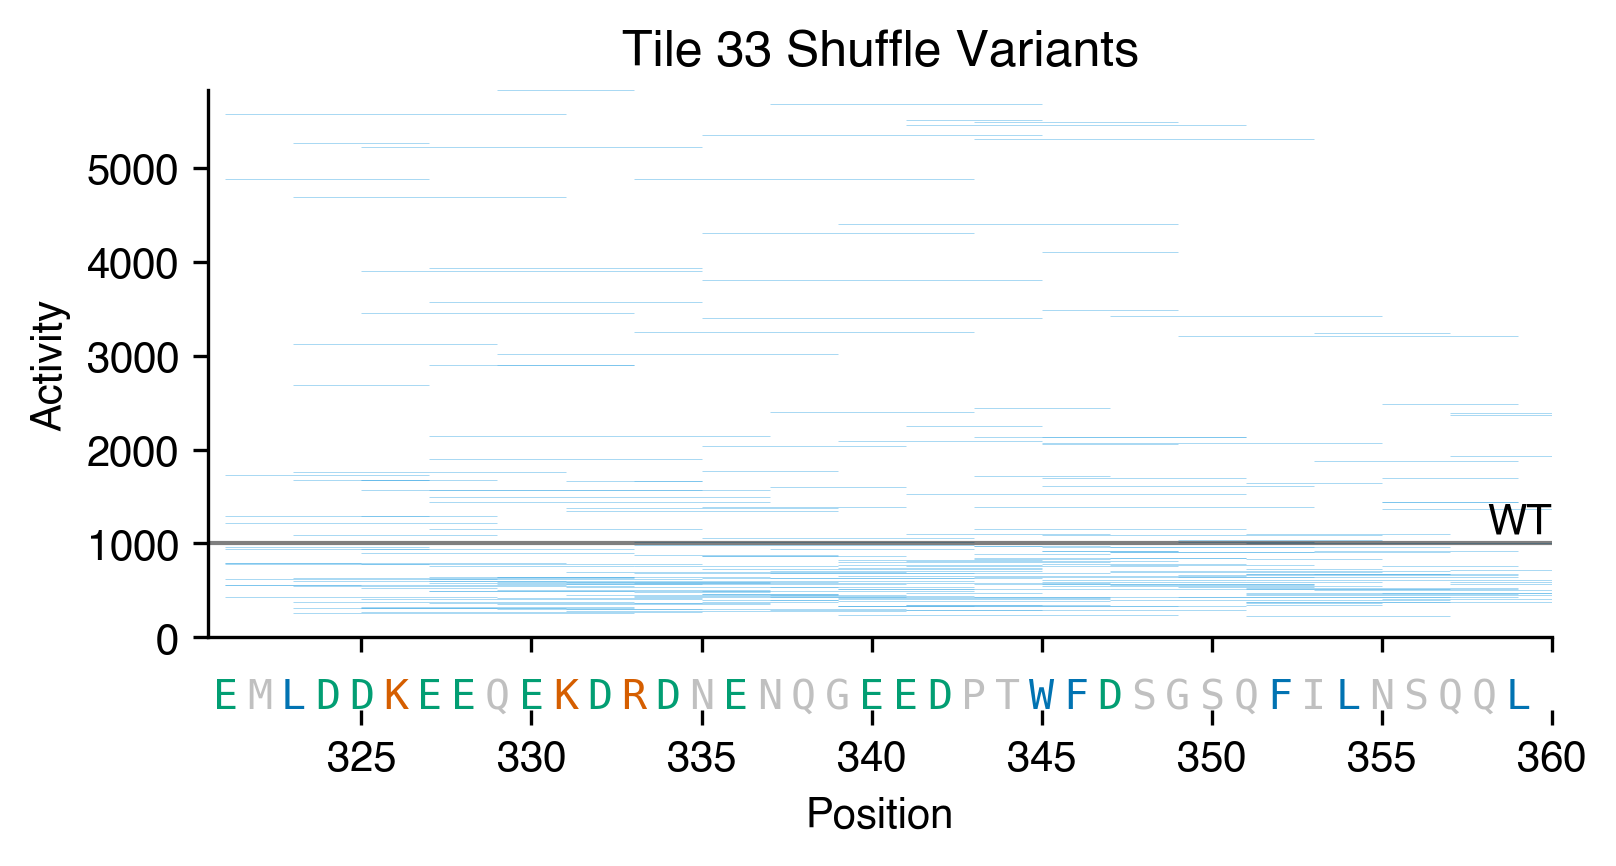

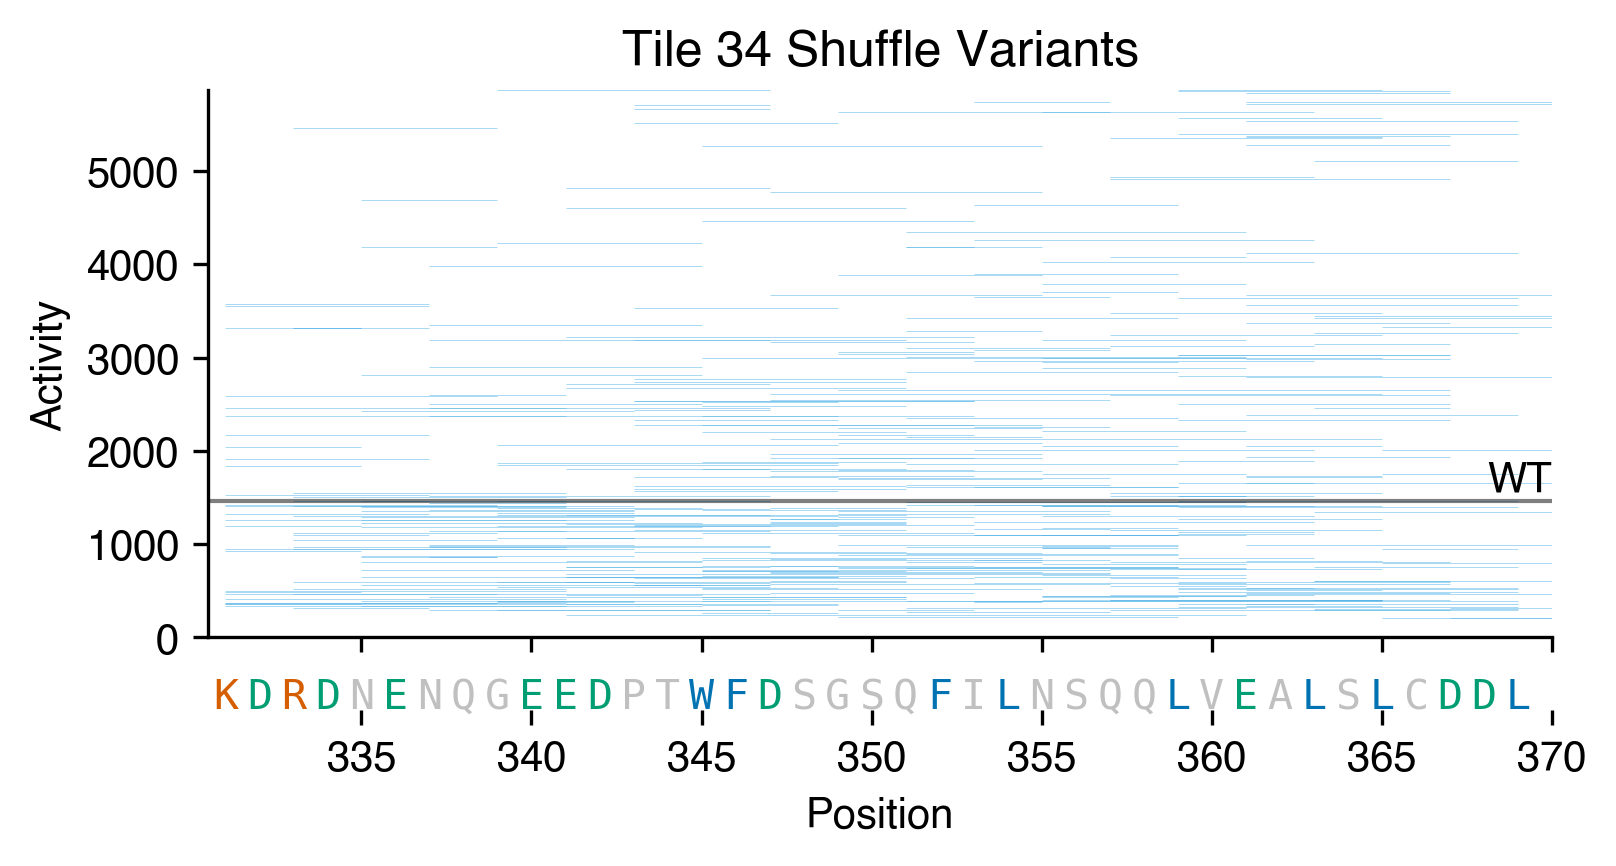

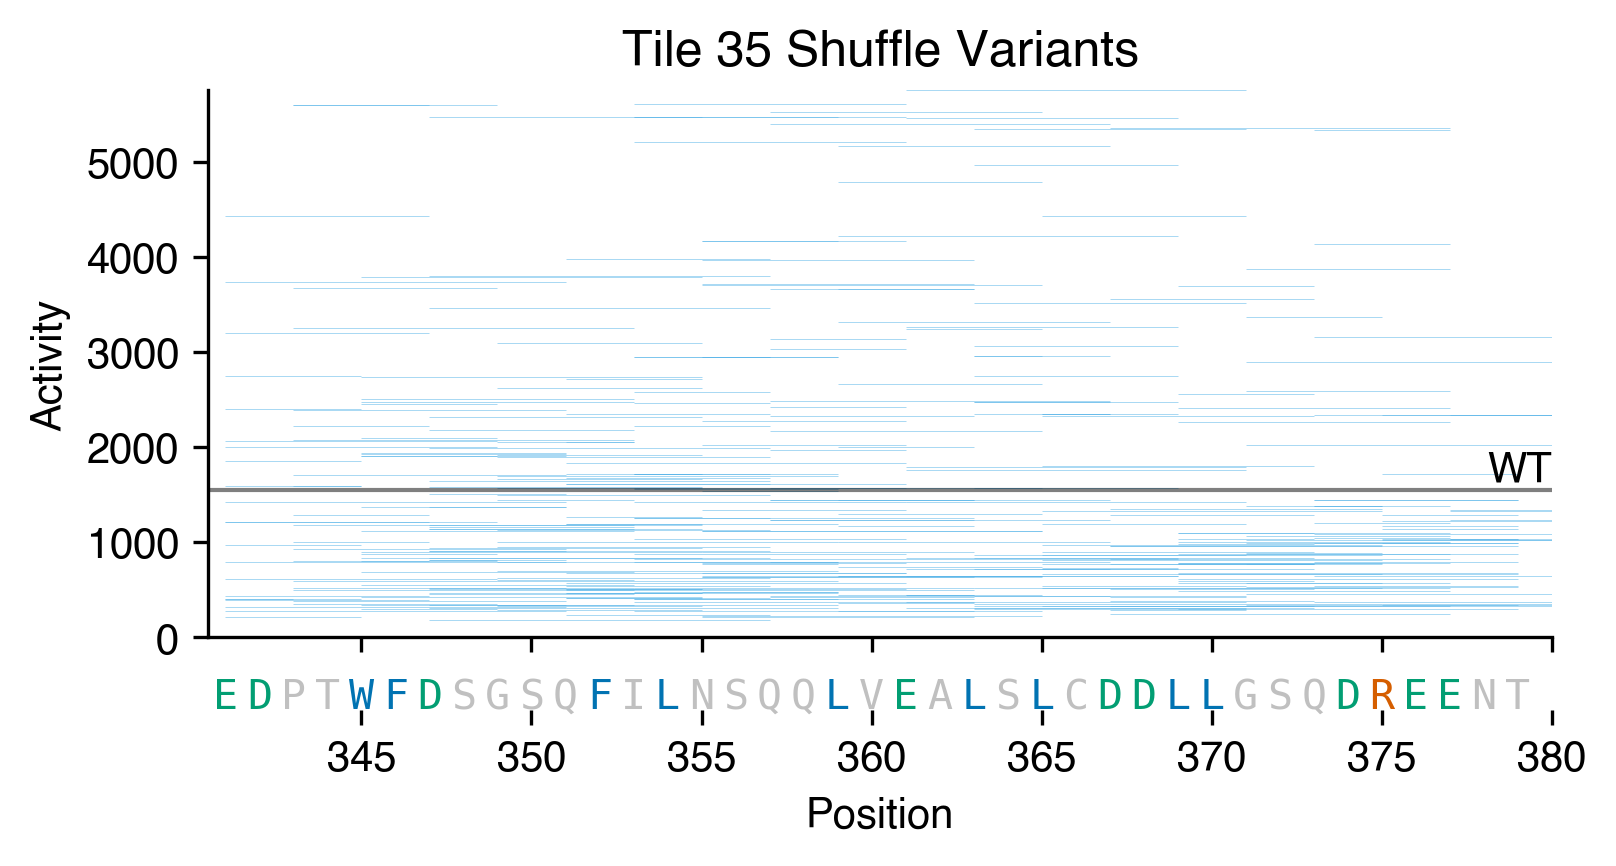

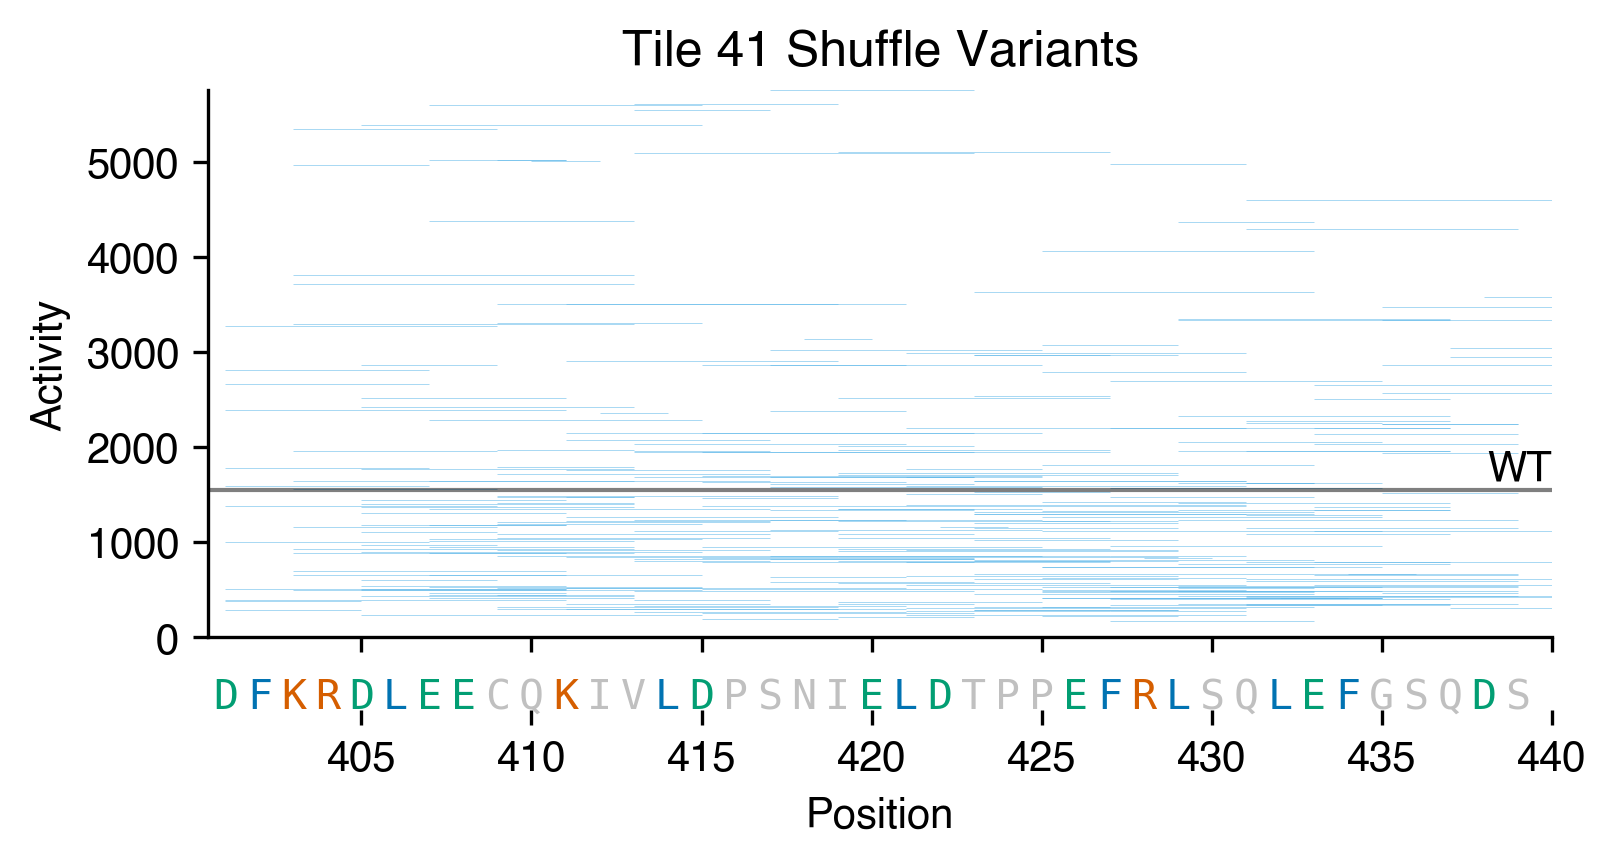

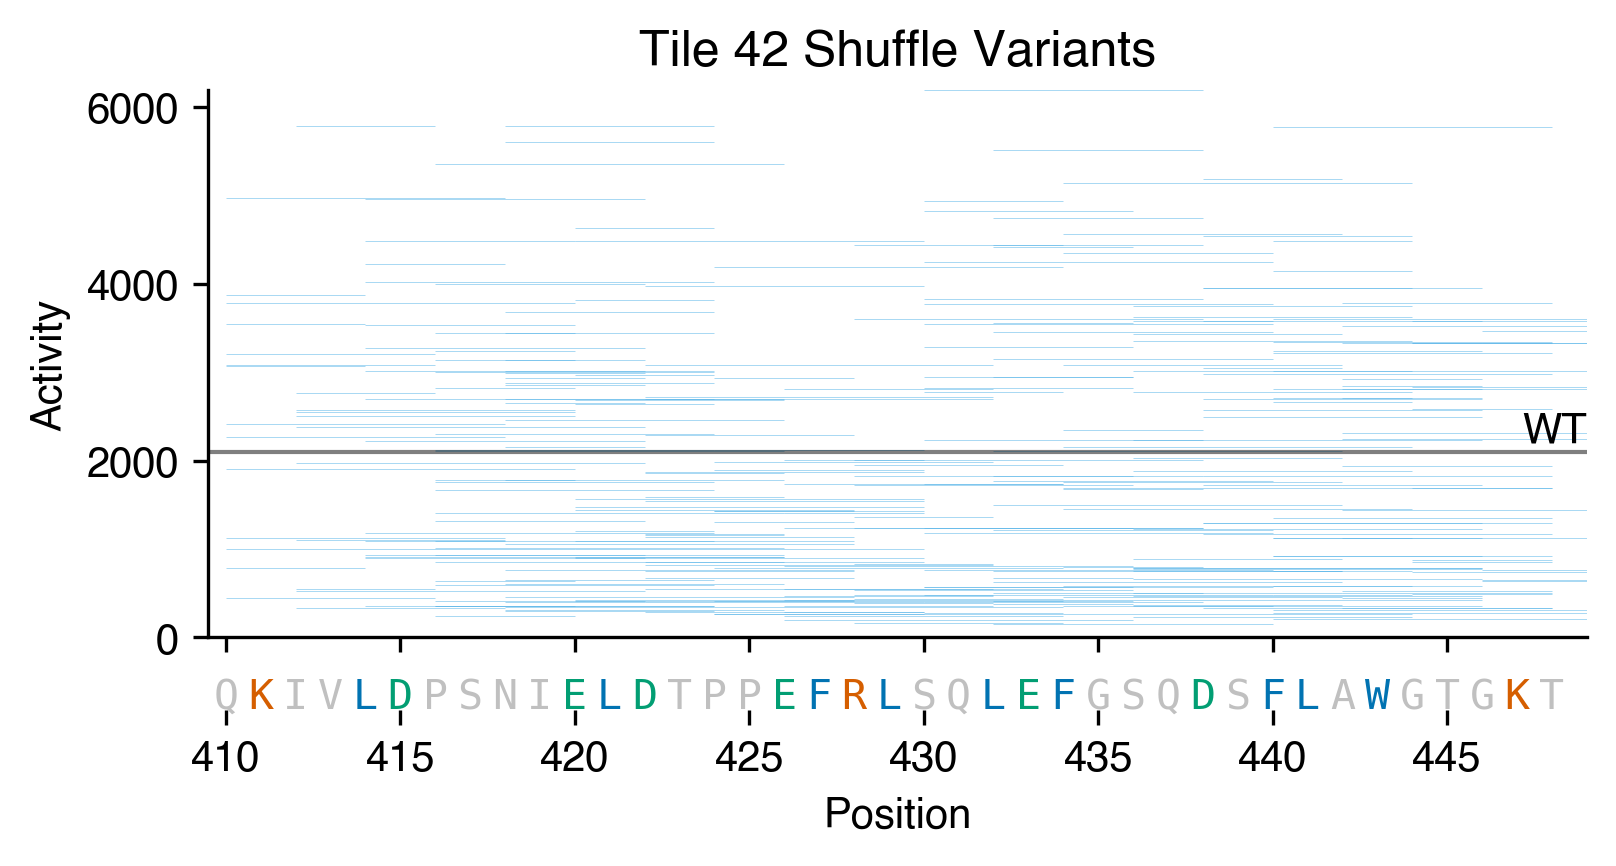

In [15]:
for tile in shuffle_vars_with_diff["tile"].unique():
#for tile in [33]:
    df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile]
    plot_shuffles(df)
    plt.savefig("../output/figures/shuffles/" + str(tile))

In [16]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [17]:
df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 33]
df = df[df["shuffle_size"] == 4]
df

,Start,End,Description_var,Other_var,mid,tile_var,Unnamed: 0_var,Activity_S3_1_var,Error_var,BC Count_var,...,BC Count_wt,activ_err_start_wt,activ_err_end_wt,vars,AAs,tile,shuffle_size,coordinates,pos_start,pos_end
52,321,360,33_shuffle_size4_ss2_pos0_1,shuffle_size4_ss2_pos0_1,341,DEMLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[321, 322, 323, 324]","[E, M, L, D]",33,4,0_1,321,325
53,321,360,33_shuffle_size4_ss2_pos0_2,shuffle_size4_ss2_pos0_2,341,MEDLDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[321, 322, 323, 324]","[E, M, L, D]",33,4,0_2,321,325
54,321,360,33_shuffle_size4_ss2_pos0_3,shuffle_size4_ss2_pos0_3,341,LEDMDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,4442.0,788.372225,NaN,1.0,...,18,306.539098,1697.738699,"[321, 322, 323, 324]","[E, M, L, D]",33,4,0_3,321,325
55,321,360,33_shuffle_size4_ss2_pos0_4,shuffle_size4_ss2_pos0_4,341,MDLEDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[321, 322, 324]","[E, M, D]",33,4,0_4,321,325
56,321,360,33_shuffle_size4_ss2_pos0_5,shuffle_size4_ss2_pos0_5,341,LDMEDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[321, 322, 323, 324]","[E, M, L, D]",33,4,0_5,321,325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,321,360,33_shuffle_size4_ss2_pos18_6,shuffle_size4_ss2_pos18_6,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSLQVQ,2386.0,712.585375,NaN,1.0,...,18,306.539098,1697.738699,"[357, 359, 360]","[Q, L, V]",33,4,18_6,357,361
231,321,360,33_shuffle_size4_ss2_pos18_7,shuffle_size4_ss2_pos18_7,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQVL,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[359, 360]","[L, V]",33,4,18_7,357,361
232,321,360,33_shuffle_size4_ss2_pos18_8,shuffle_size4_ss2_pos18_8,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSLQQV,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[357, 359]","[Q, L]",33,4,18_8,357,361
233,321,360,33_shuffle_size4_ss2_pos18_9,shuffle_size4_ss2_pos18_9,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQVQL,NaN,NaN,NaN,NaN,...,18,306.539098,1697.738699,"[358, 359, 360]","[Q, L, V]",33,4,18_9,357,361


In [18]:
# for shuffle_size in [2, 4, 6, 8, 10]:
#     df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 34]
#     df = df[df["shuffle_size"] == shuffle_size]
#     plot_shuffles(df)

##  Splitting up shuffles by state size

In [19]:
def plot_one_shuffle_track(tile, shuffle_size, ax1, shuffle_vars_with_diff = shuffle_vars_with_diff, alpha = 1, lw = 1):
    df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile]
    if shuffle_size:
        df = df[df["shuffle_size"] == shuffle_size]
    if len(df) > 0:
        
        max_y = 0
        for i in range(len(df)):
            row_vars = df["vars"].iloc[i]
            ax1.hlines(y=df[activity_col + "_var"].iloc[i], 
                       xmin=df["pos_start"].iloc[i], 
                       xmax=df["pos_end"].iloc[i], 
                       color=sns.color_palette('colorblind')[-1], 
                       linestyle='-', alpha = alpha, lw = lw)
            max_y = max(max_y, df[activity_col + "_var"].iloc[i])
            
    
                               
        ax1.axhline(df[activity_col + "_wt"].iloc[0], lw = 1, color = 'black', alpha = 0.5)
        ax1.set_xlim(df["Start"].iloc[i] - 0.5, df["End"].iloc[i])    
        ax1.set_ylim(0, max_y)
        if shuffle_size == 2:
            ax1.text(x = df["End"].iloc[i], y = df[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")
    sns.despine(ax = ax1, left = False)
        #ax2.set_yticklabels([])
    if shuffle_size:
        ax1.set_ylabel(str(shuffle_size) + "AA", rotation = 0, va = 'center')
    else:
        ax1.set_ylabel("All", rotation = 0, va = 'center')

def plot_AA_track(start, end, ax2):
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(start, end):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax2.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')

    ax2.set_ylim(0.8, 1)
    sns.despine(ax = ax2, left = True, bottom = True)

    #ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax2.set_xlabel("Position")


def plot_marg_hist(tile_df, ax):
    sns.histplot(data = tile_df, y = "Activity_S3_1_var", ax = ax, edgecolor = 'white', color = sns.color_palette('colorblind')[-1], stat = 'density', bins = 15)
    sns.despine(ax = ax)

In [20]:
shuffle_vars_with_diff.columns

Index(['Start', 'End', 'Description_var', 'Other_var', 'mid', 'tile_var',
       'Unnamed: 0_var', 'Activity_S3_1_var', 'Error_var', 'BC Count_var',
       'activ_err_start_var', 'activ_err_end_var', 'Description_wt',
       'Other_wt', 'tile_wt', 'Unnamed: 0_wt', 'Activity_S3_1_wt', 'Error_wt',
       'BC Count_wt', 'activ_err_start_wt', 'activ_err_end_wt', 'vars', 'AAs',
       'tile', 'shuffle_size', 'coordinates', 'pos_start', 'pos_end'],
      dtype='object')

In [22]:
# shuffle_vars_with_diff_for_JD = shuffle_vars_with_diff[["Start", "End", "Description_var", "tile_var", "Activity_S3_1_var", "Activity_S3_2_var", "tile_wt", "Activity_S3_1_wt", "Activity_S3_2_wt"]]
# shuffle_vars_with_diff_for_JD

In [23]:
# shuffle_vars_with_diff.to_csv("../data/all_shuffle_vars.csv")

In [24]:
# shuffle_vars_with_diff_for_JD.to_csv("../data/all_shuffle_vars_JD.csv")

In [25]:
def plot_size_sep_shuffles(tile_num):
    fig, axs = plt.subplots(7, 2, figsize = (5,6), dpi = 300, sharex = 'col', sharey = 'row', gridspec_kw={'height_ratios': [1, 1, 1, 1, 1, 1, 0.2], 'width_ratios' : [1, 0.2]})

    i = 0
    for ss in [2, 4, 6, 8, 10]:
        plot_one_shuffle_track(tile_num, ss, axs[i][0], shuffle_vars_with_diff, alpha = 0.25, lw = 0.6)

        df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile_num]
        df = df[df["shuffle_size"] == ss]
        #display(df)
        plot_marg_hist(df, axs[i][1])
        if len(df) > 0:
            axs[i][1].axhline(df["Activity_S3_1_wt"].iloc[0], lw = 1, color = 'black', alpha = 0.5)
        i += 1

    df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile_num]
    plot_one_shuffle_track(tile_num, False, axs[-2][0], shuffle_vars_with_diff, alpha = 0.25, lw = 0.6)
    plot_marg_hist(df, axs[-2][1])
    axs[-2][1].axhline(df["Activity_S3_1_wt"].iloc[0], lw = 1, color = 'black', alpha = 0.5)
   
    plot_AA_track(df["Start"].iloc[0], df["End"].iloc[1], axs[-1][0])
    #plot_marg_hist(pd.DataFrame(), axs[-1][0])
    #sns.despine(ax = axs[-1][0], left = True)

        
    axs[0][1].set_visible(False)
    axs[-1][1].set_visible(False)
    
    print(axs[-1][1].get_xticks())

    axs[-2][1].tick_params(axis='x', labelbottom=True) 
    labels = [item.get_text() for item in axs[-2][1].get_xticklabels()]
    axs[-2][1].set_xticklabels([str(round(float(label), 4)) for label in labels])

    #sns.despine(ax = axs[-1][1], left = True, bottom = True)
    
    fig.tight_layout(pad = 0)
    fig.supylabel("Activity, Shuffle Size", x = -0.04)
    fig.suptitle("Tile " + str(tile_num) + " Shuffles", y = 1.02, x = 0.57)
    plt.savefig("../output/figures/shuffle_size_split/" + str(tile_num) + ".png")

In [26]:
# ! mkdir ../output/figures/shuffle_size_split

In [27]:
# fig, axs = plt.subplots(1, 2, sharey = True, sharex = 'col')
# plot_one_shuffle_track(34, False, axs[0], shuffle_vars_with_diff = shuffle_vars_with_diff, alpha = 0.5, lw = 0.5)
# plot_marg_hist(shuffle_vars_with_diff, axs[1])

# sns.despine(ax = axs[1])
# plt.tight_layout(pad = 0)

[0.     0.0025 0.005 ]


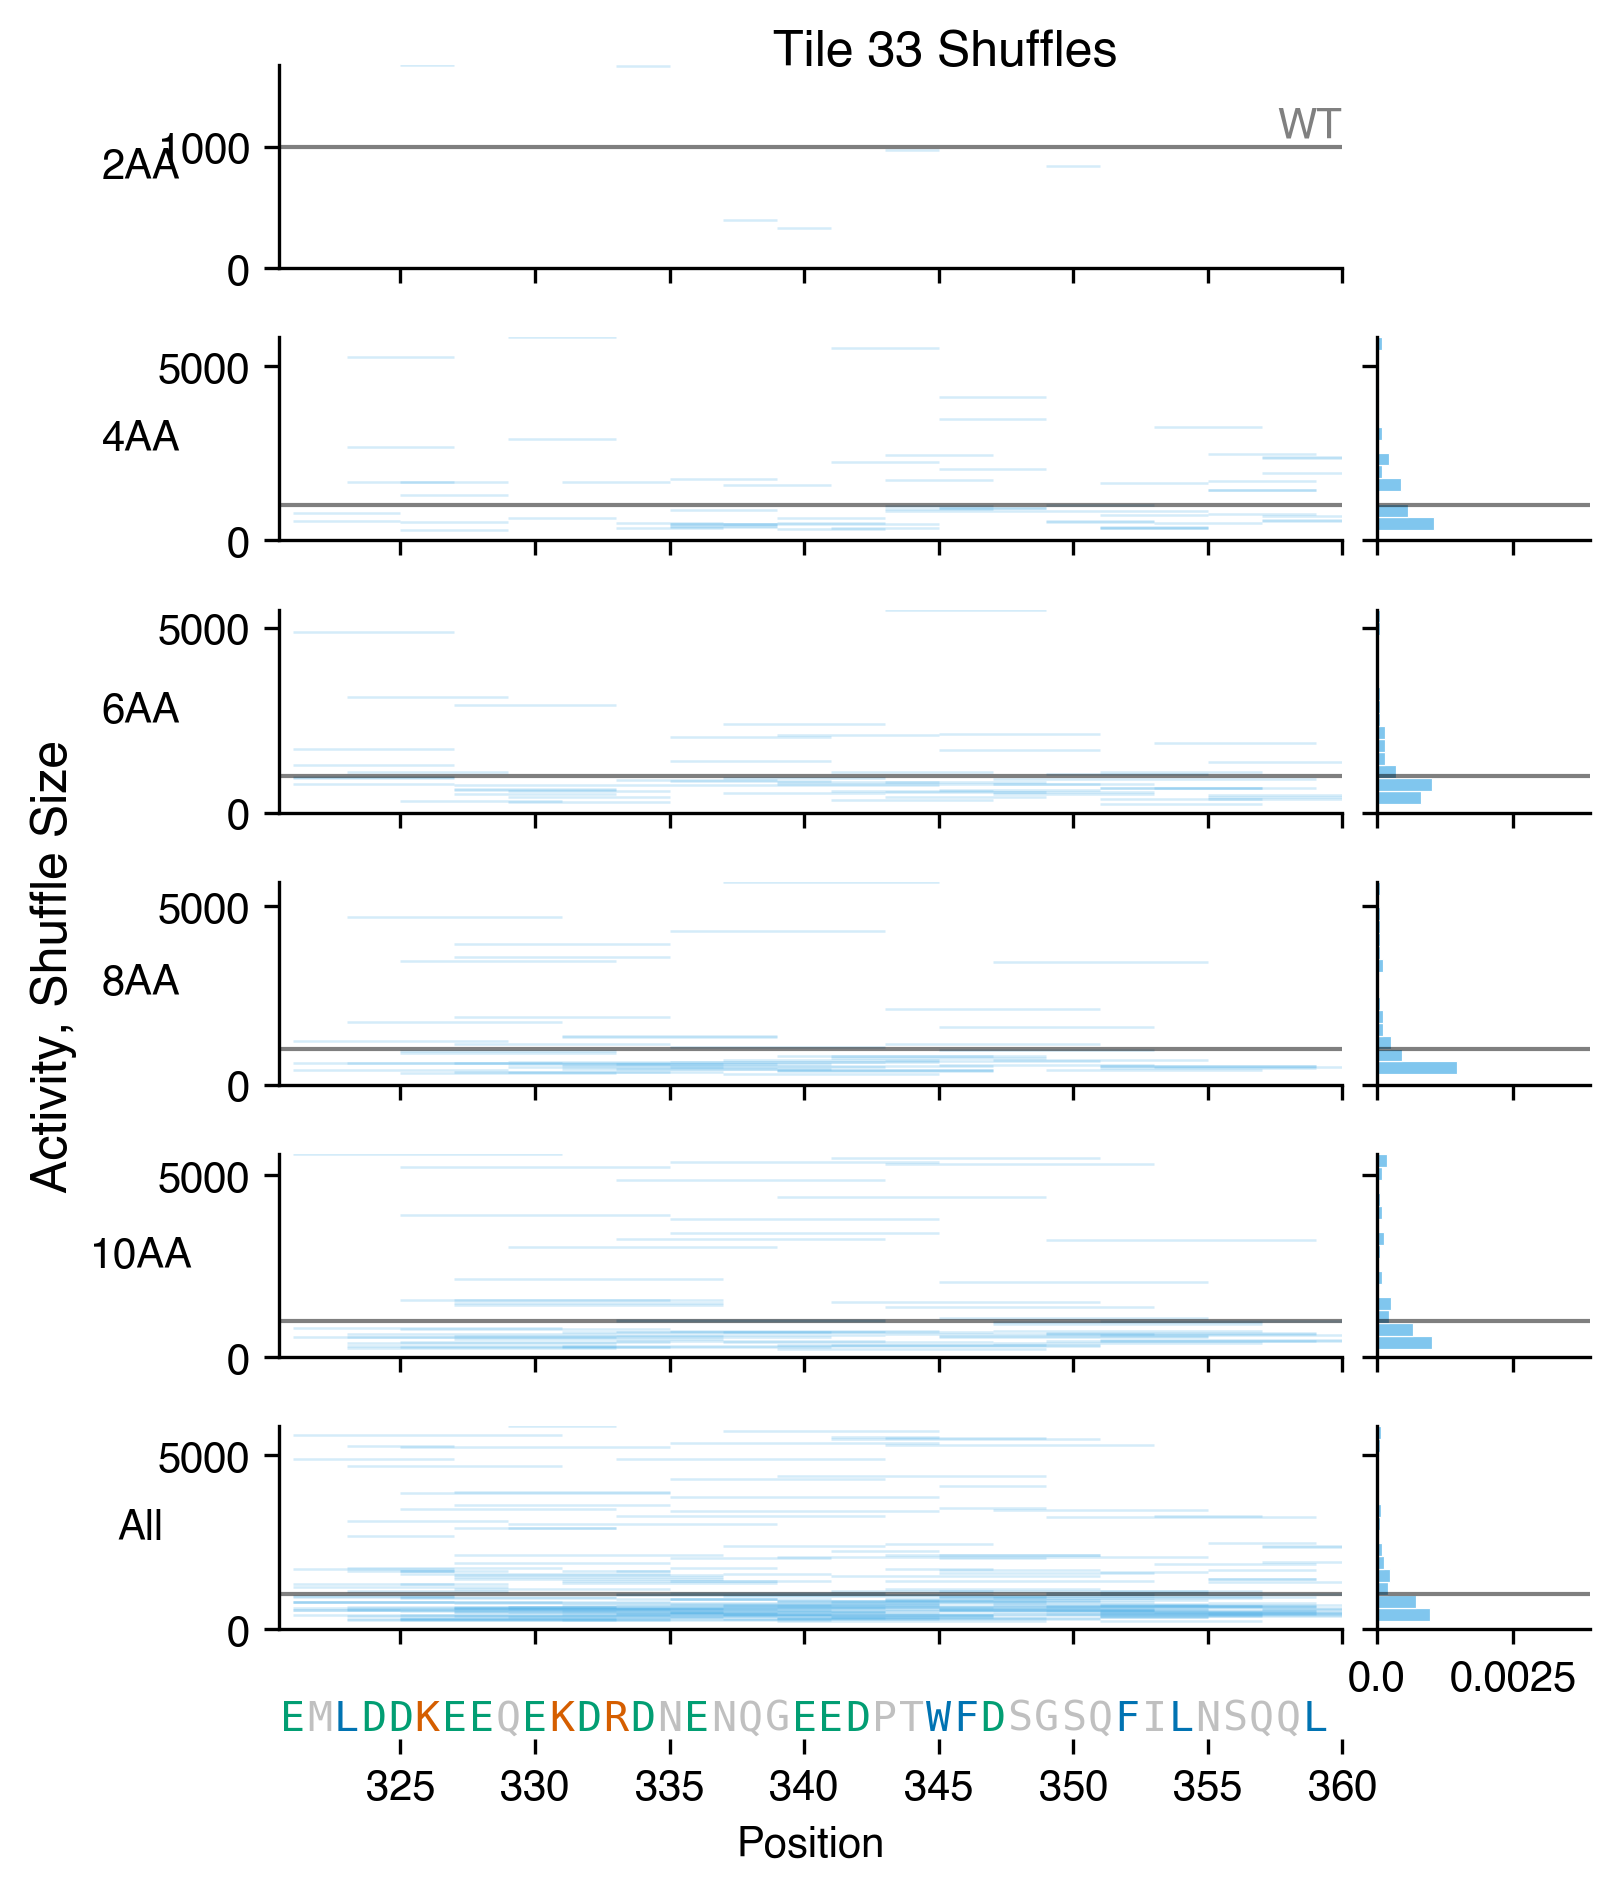

In [28]:
plot_size_sep_shuffles(33)

33
[0.     0.0025 0.005 ]
34
[0.    0.001 0.002]
35
[0.    0.001 0.002]
41
[0.    0.001 0.002]
42
[0.     0.0005 0.001 ]


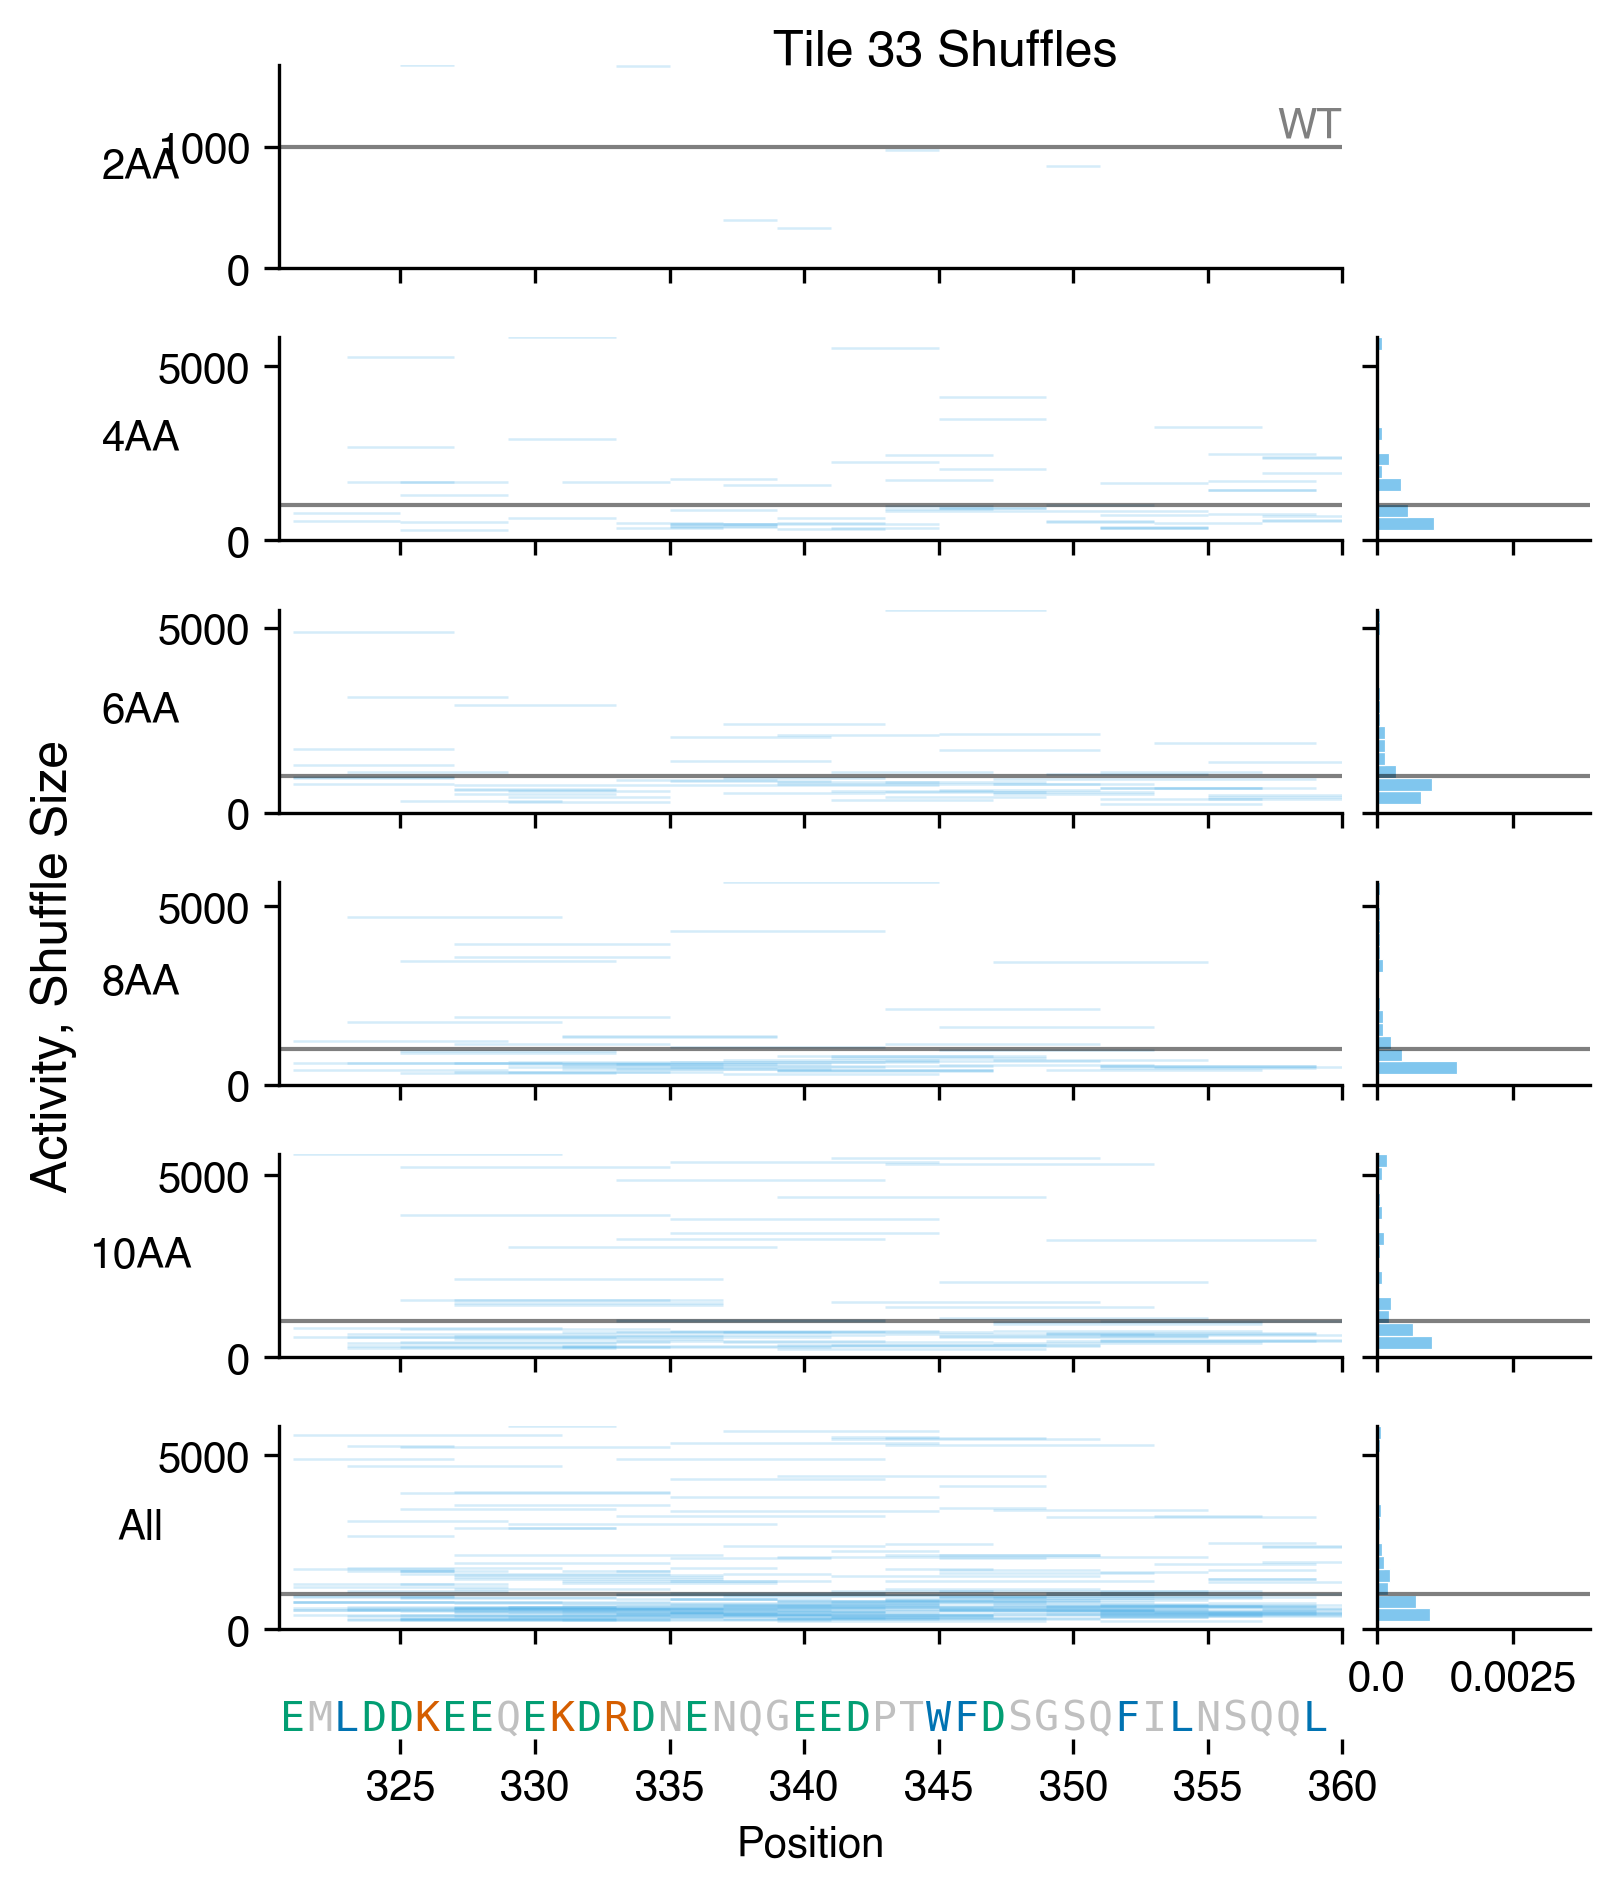

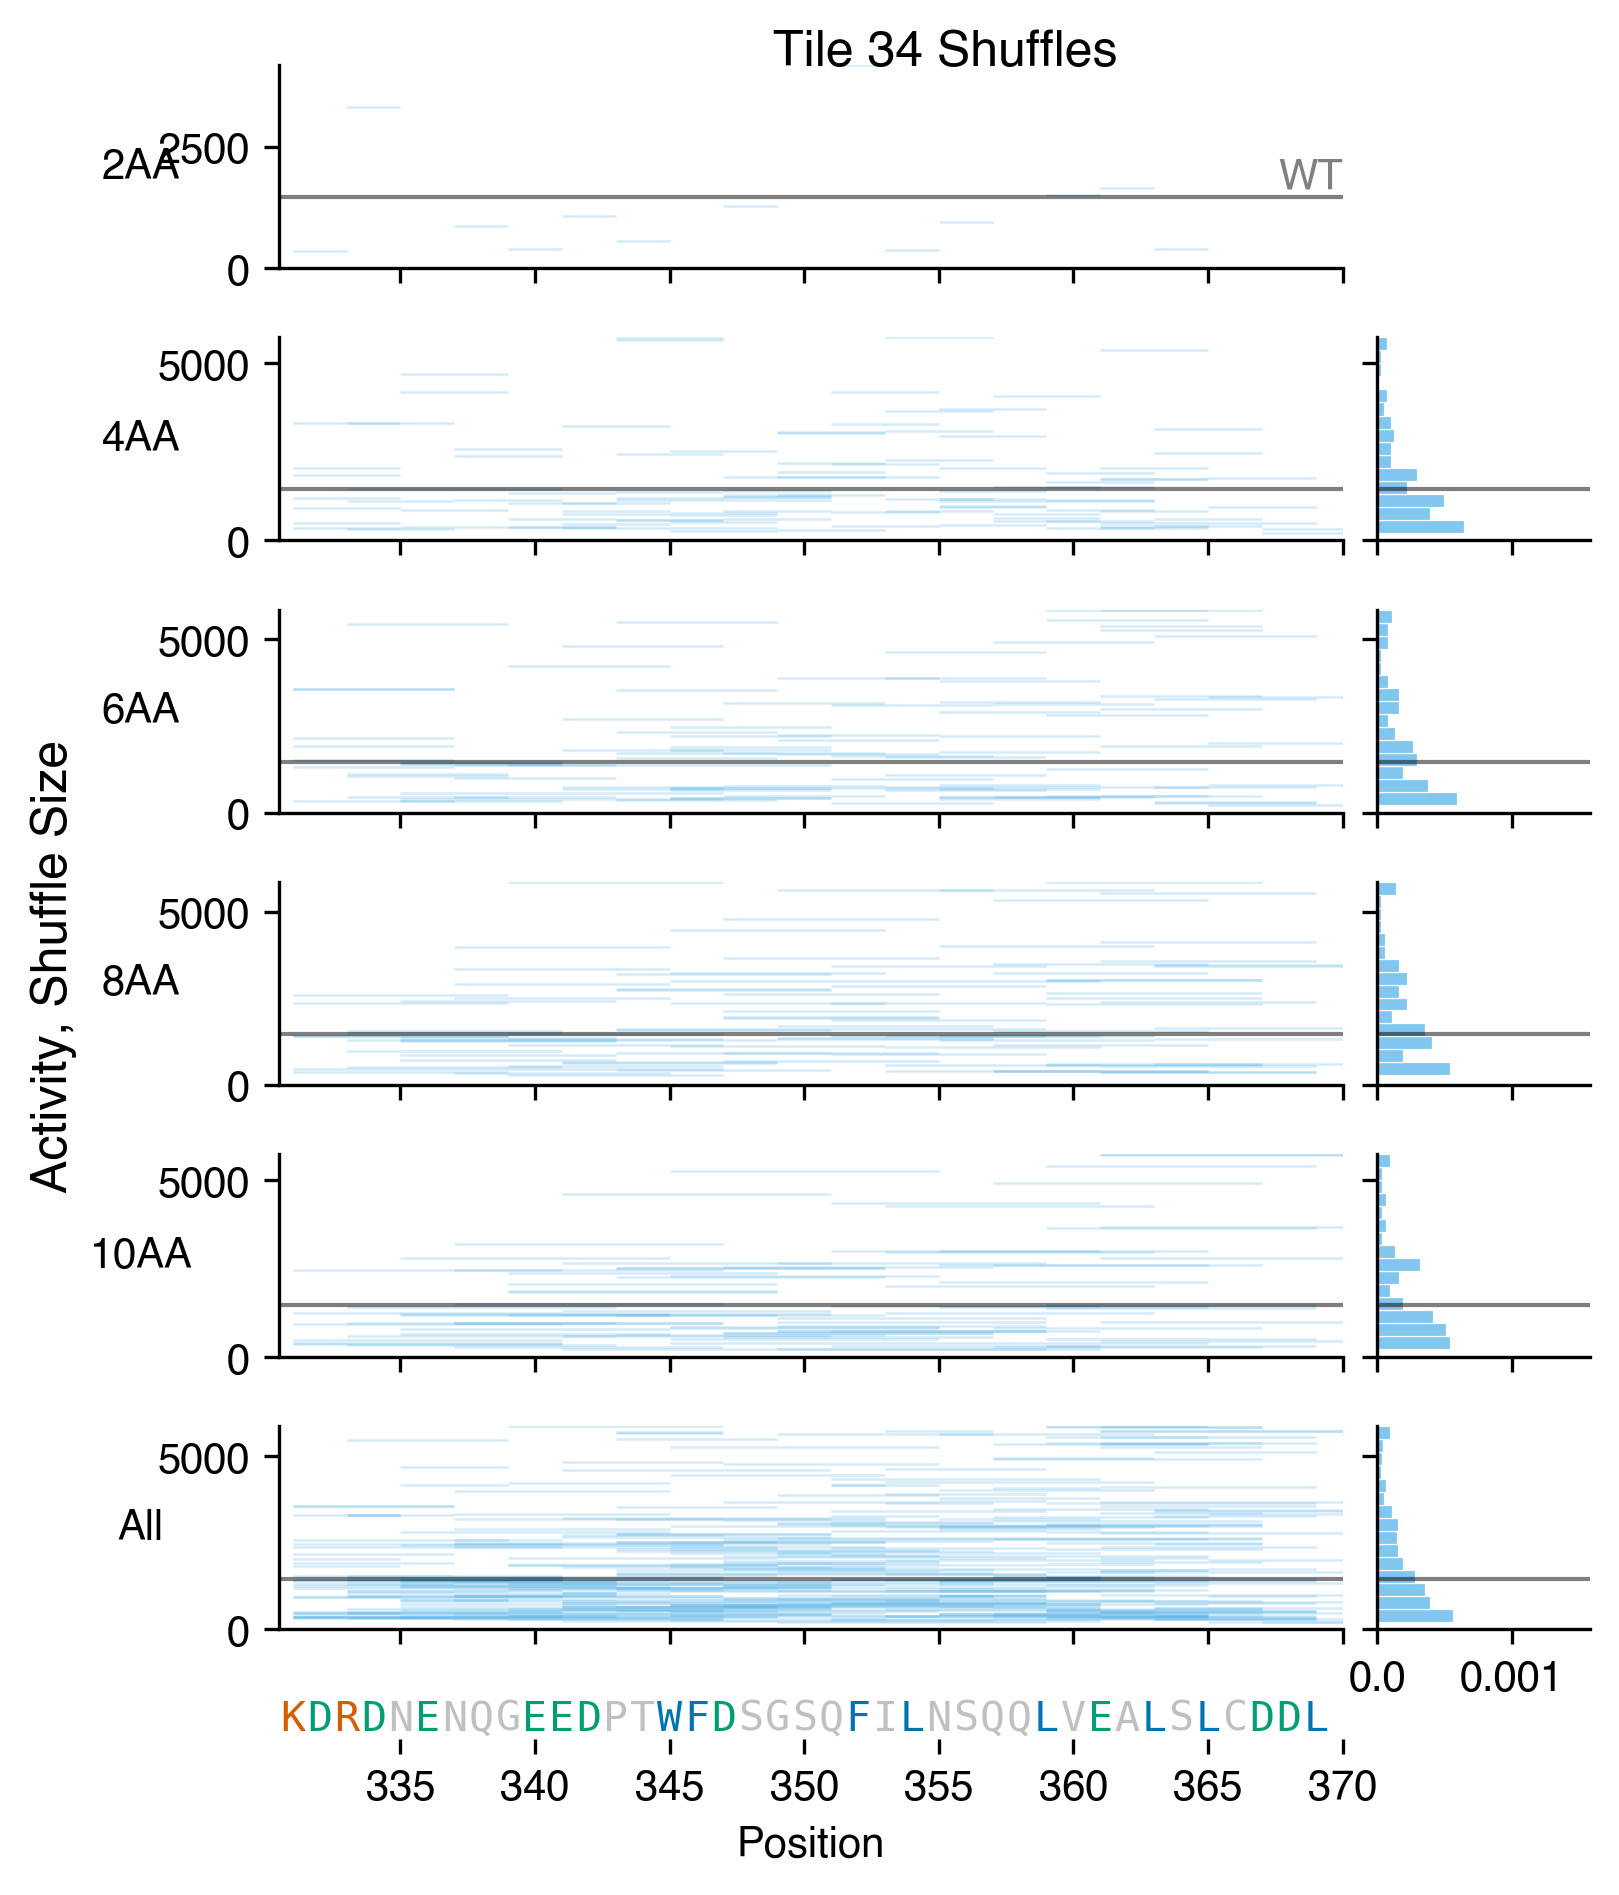

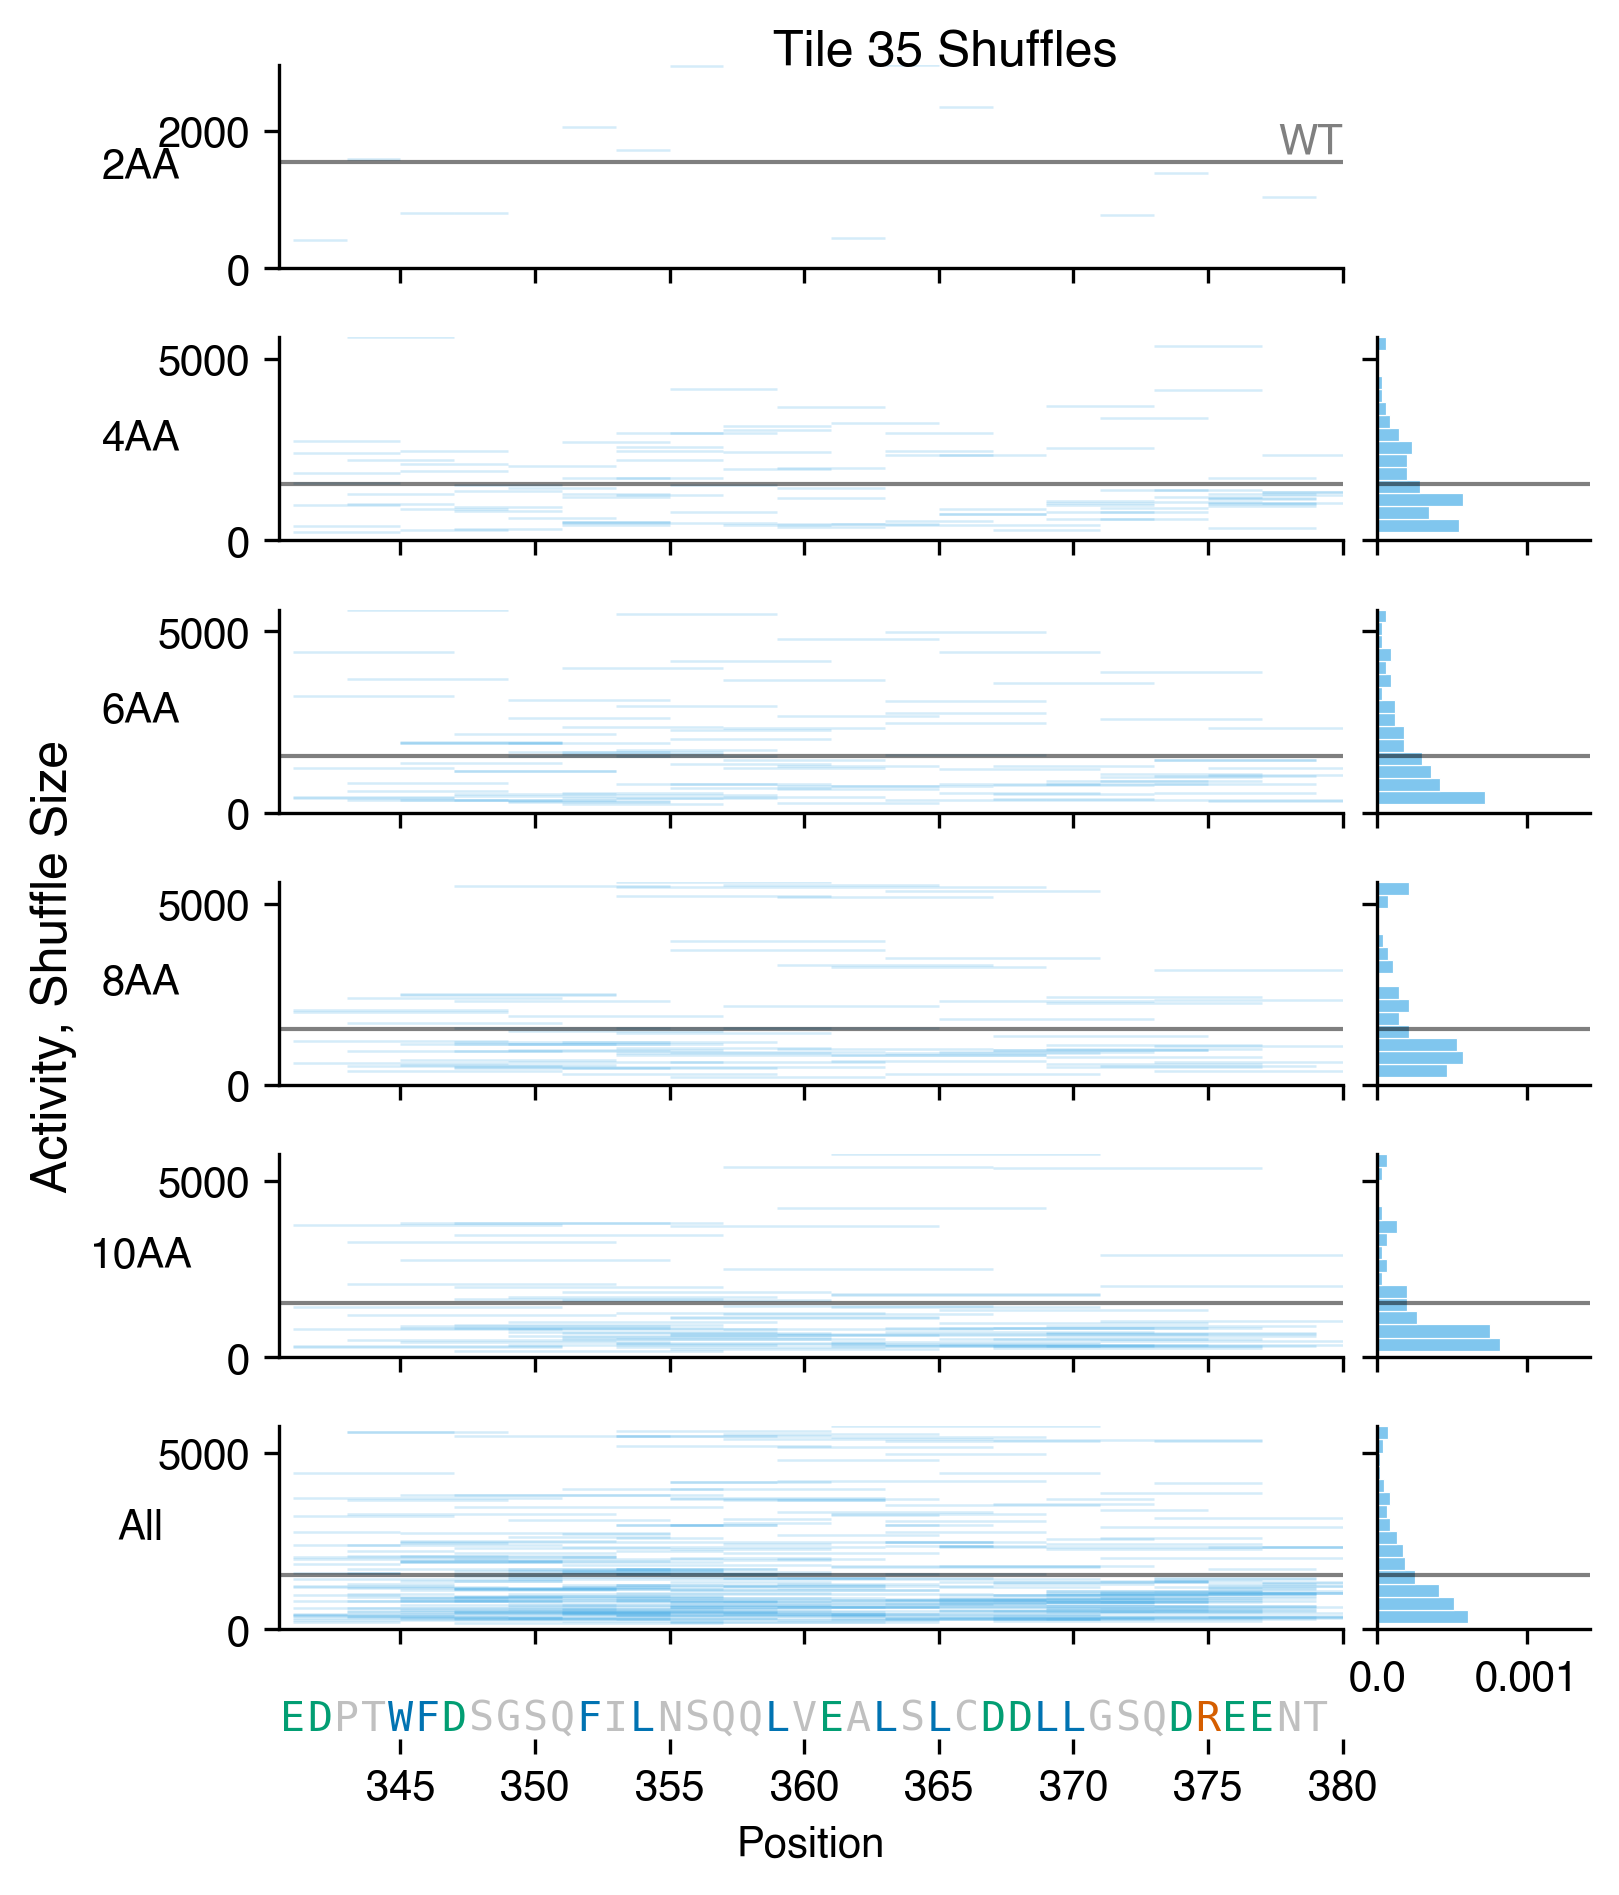

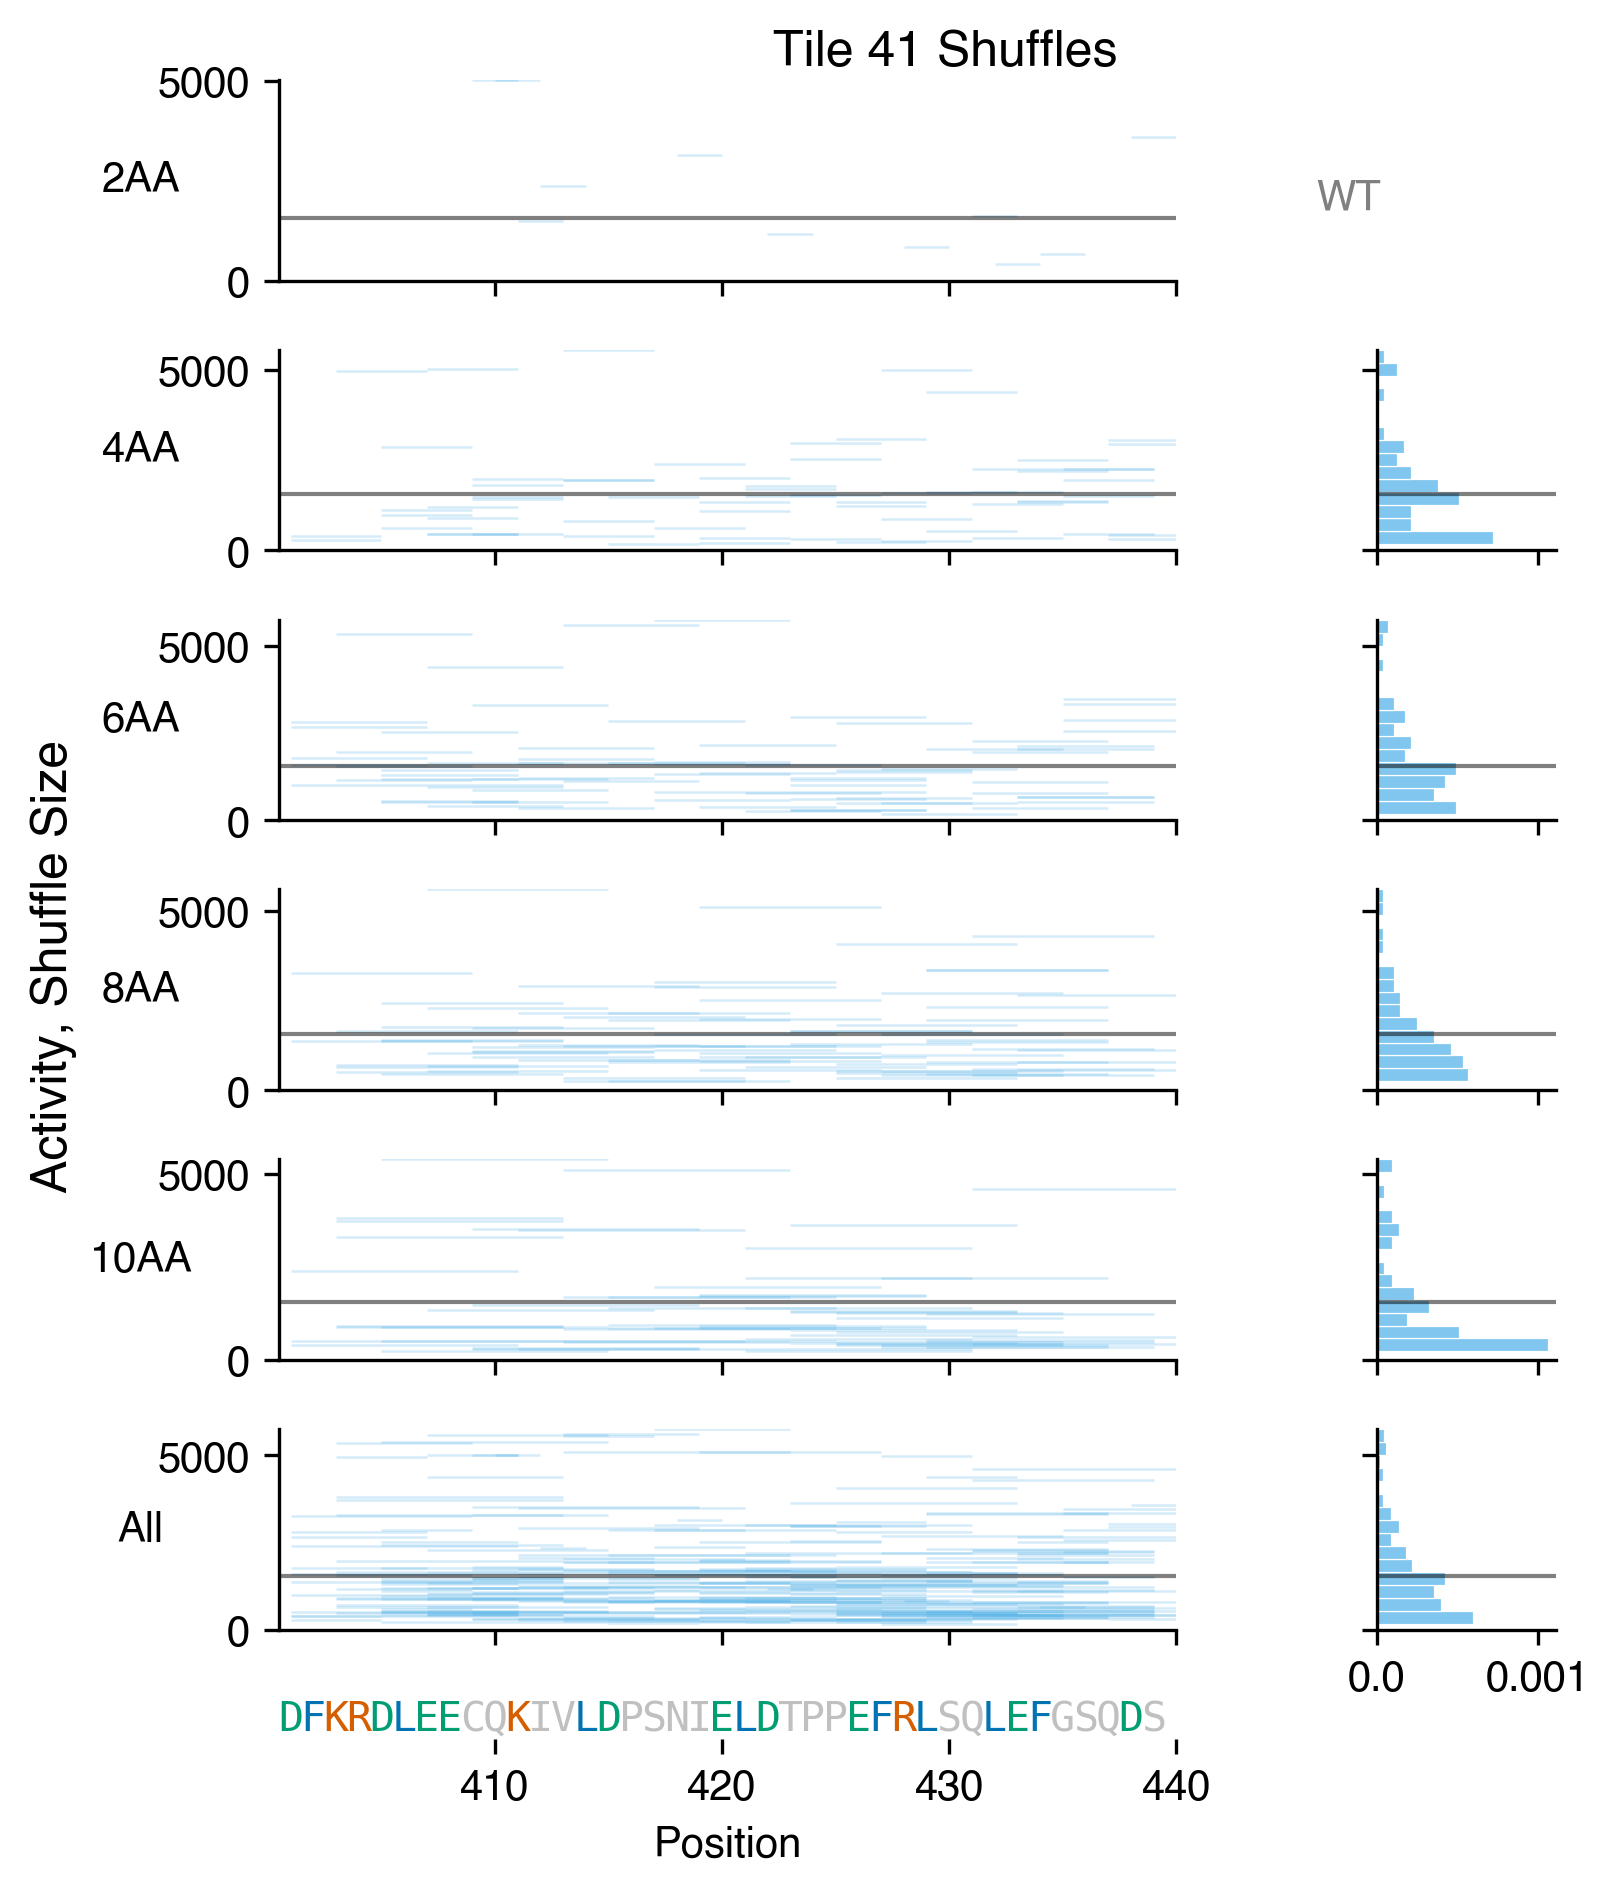

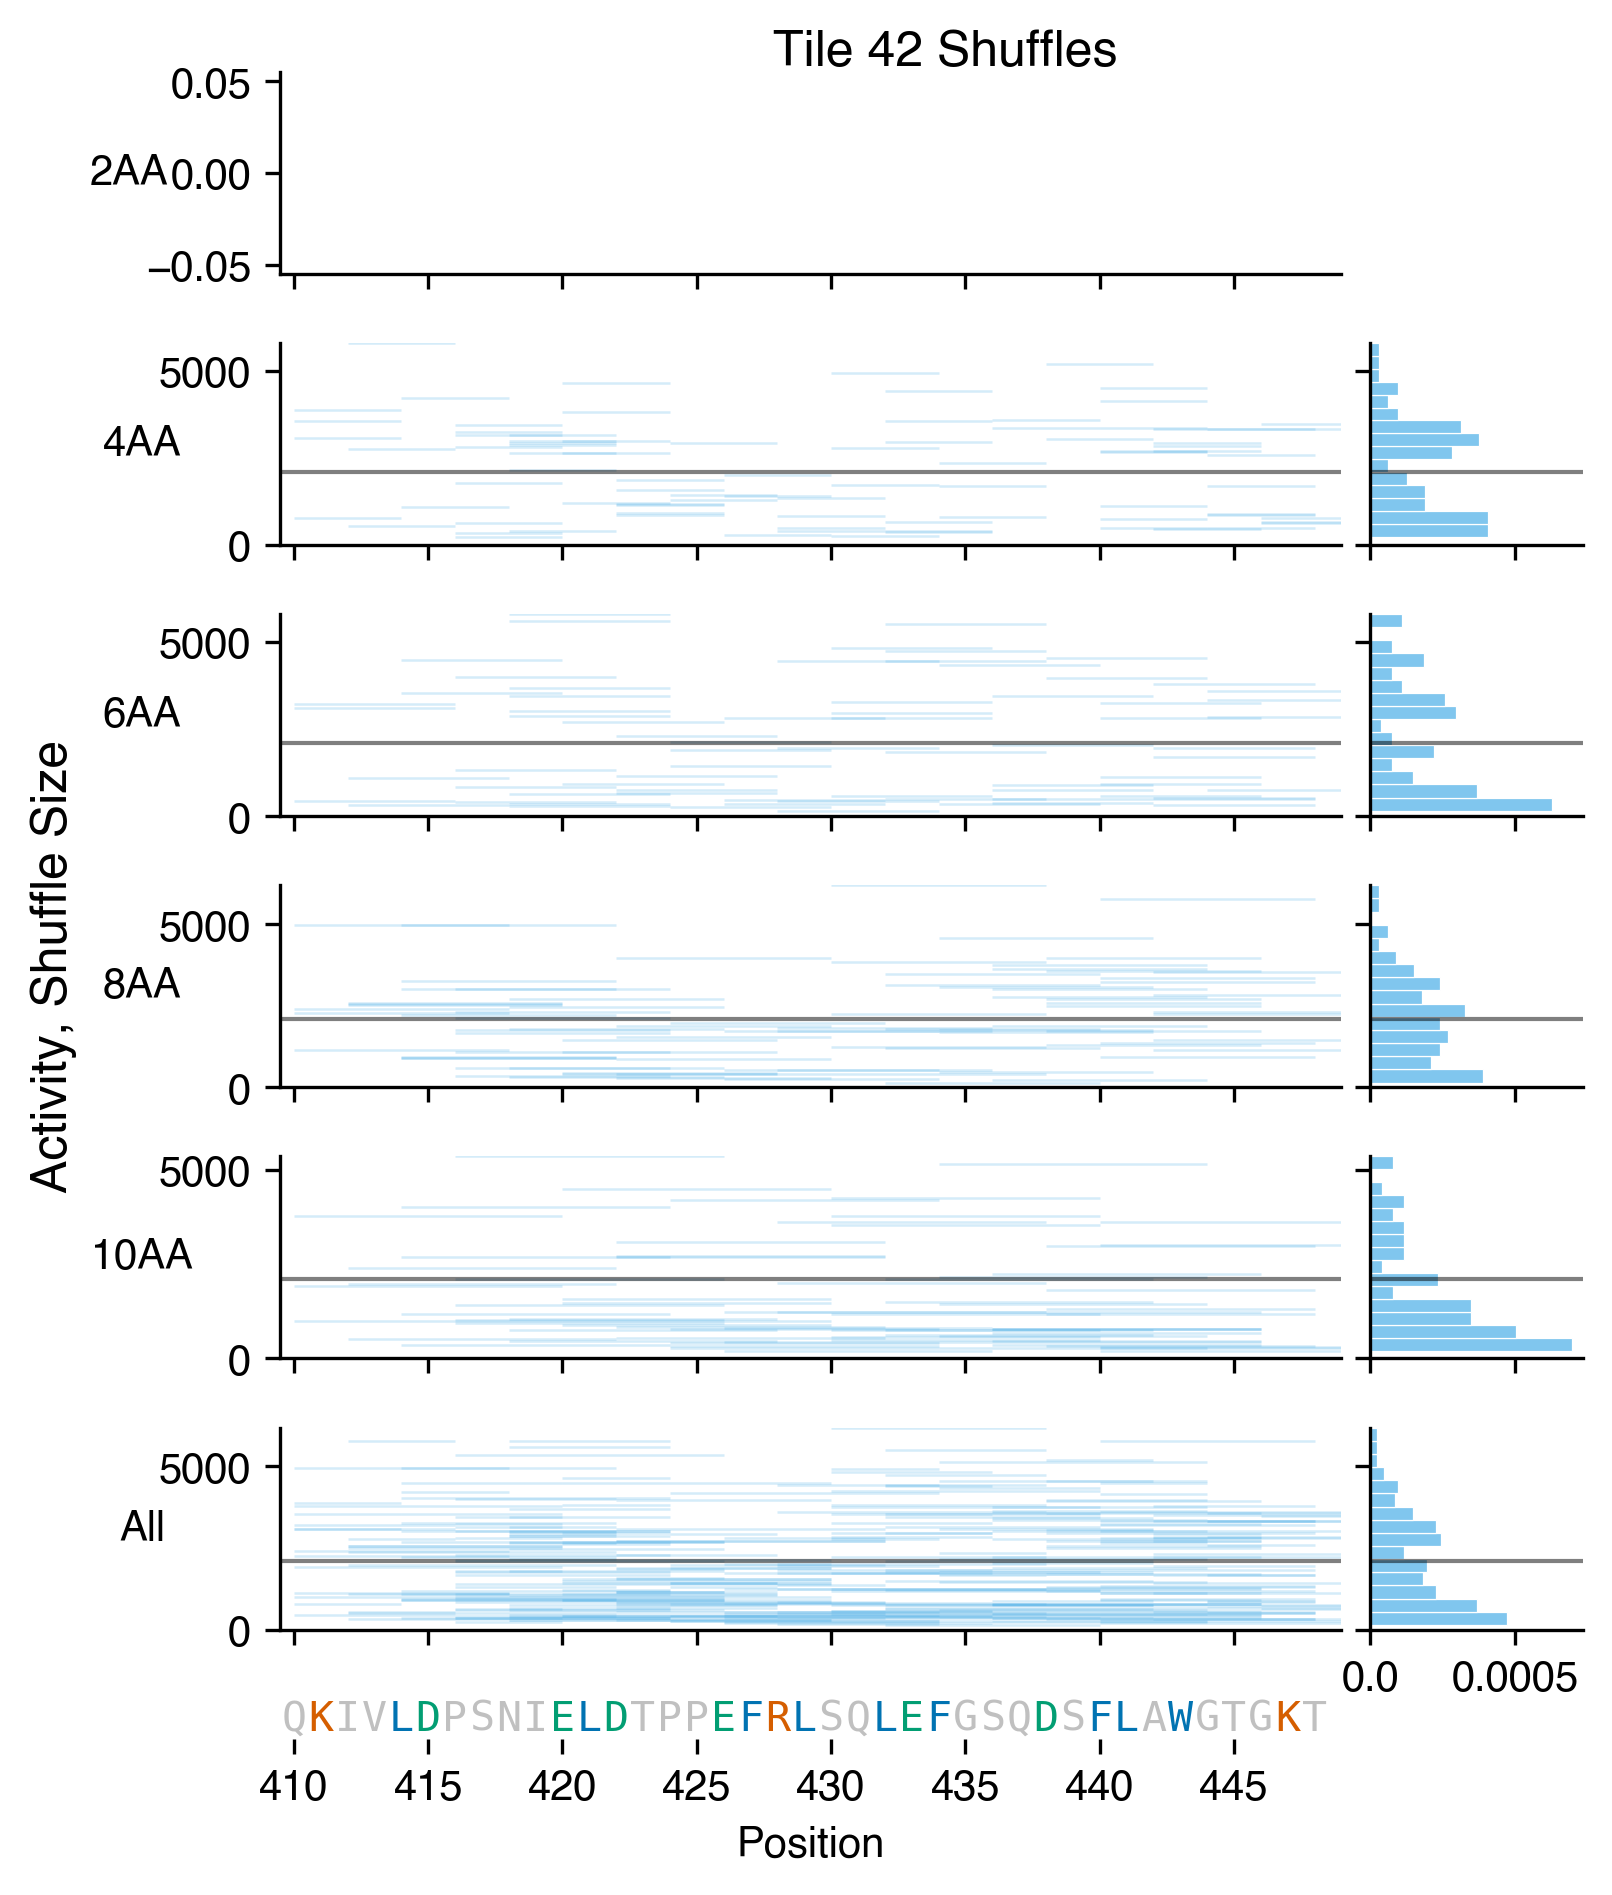

In [29]:
for tile in shuffle_vars_with_diff["tile"].unique():
    print(tile) 
    plot_size_sep_shuffles(tile)
    

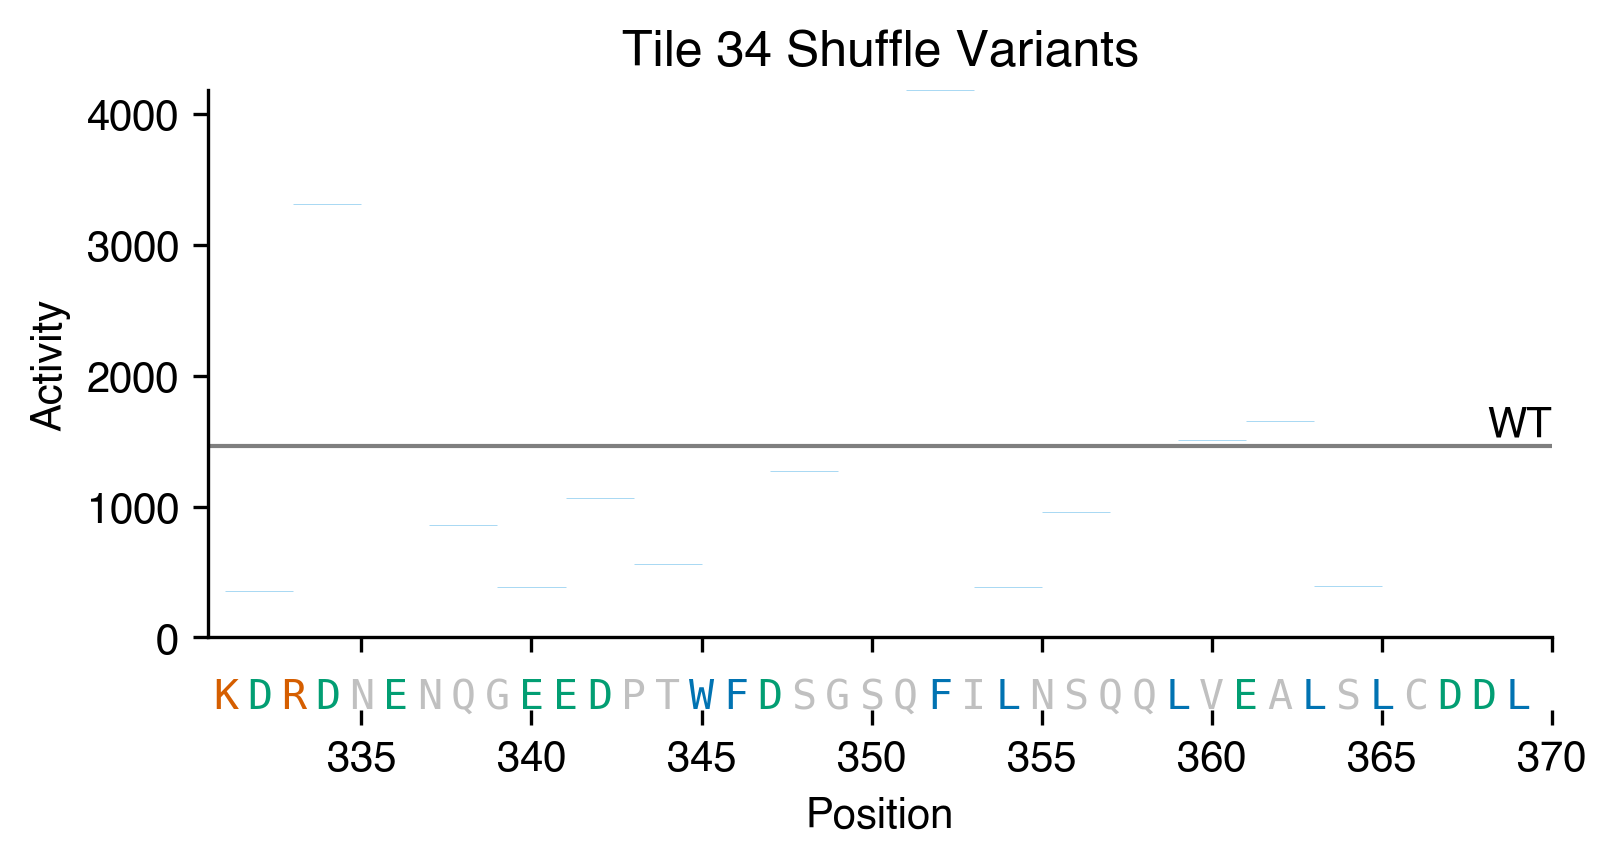

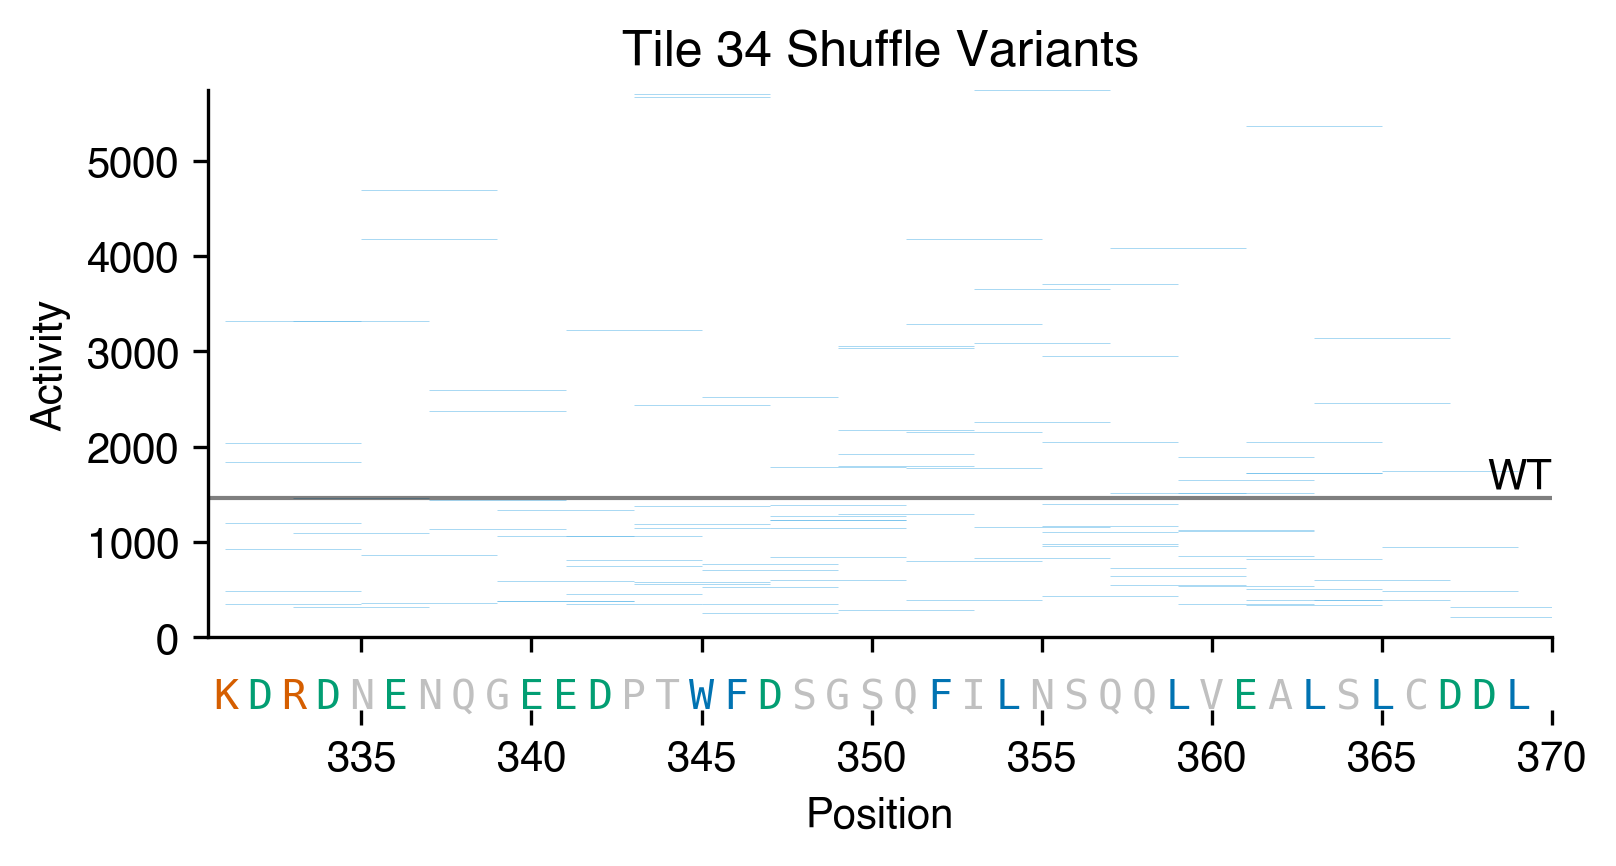

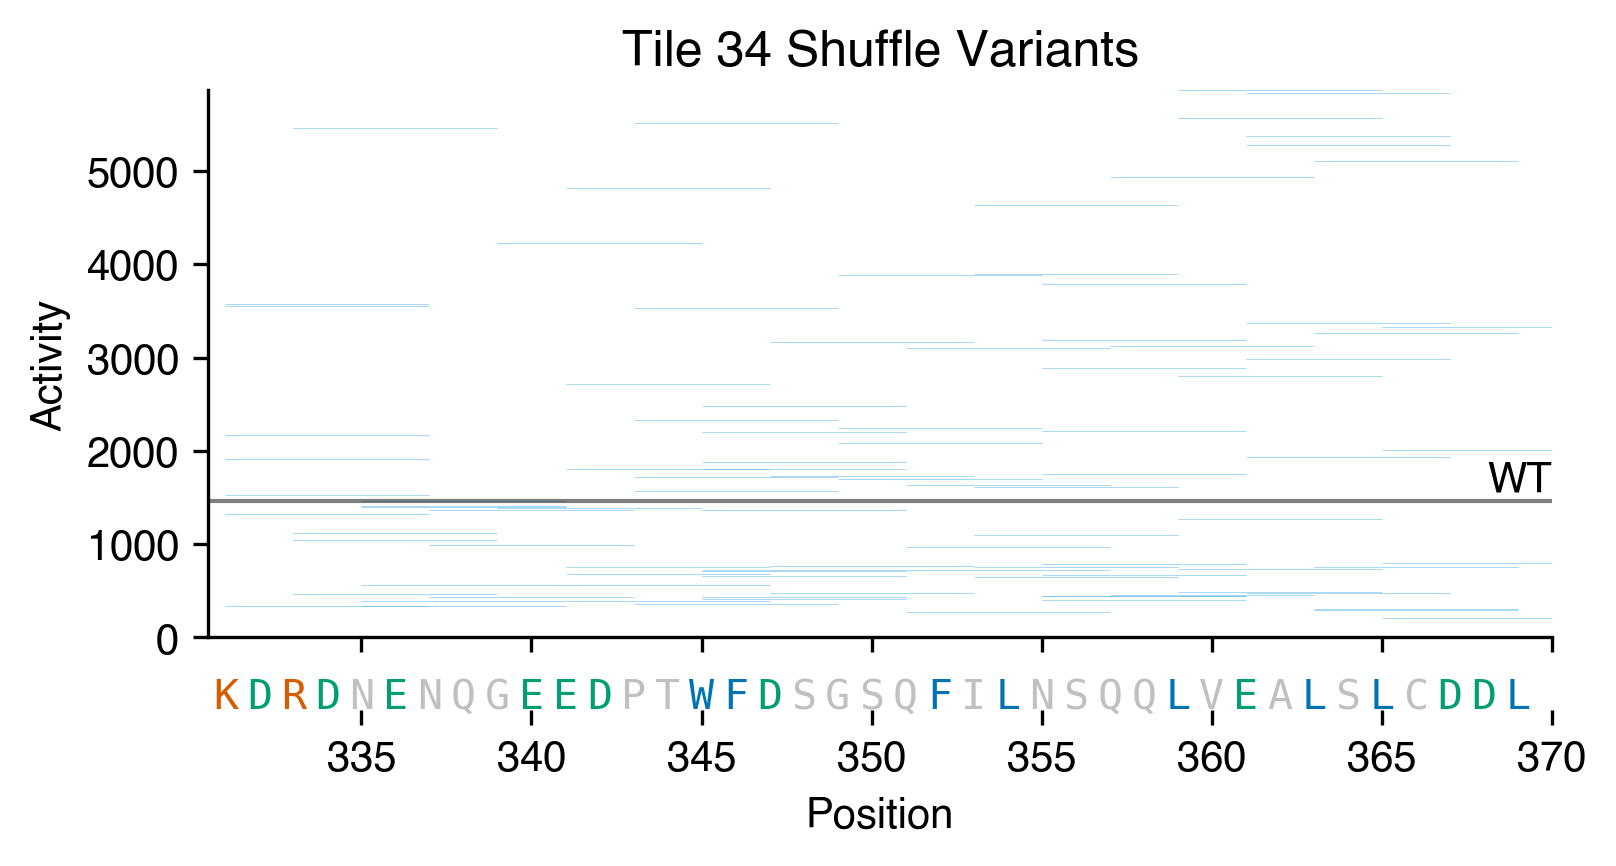

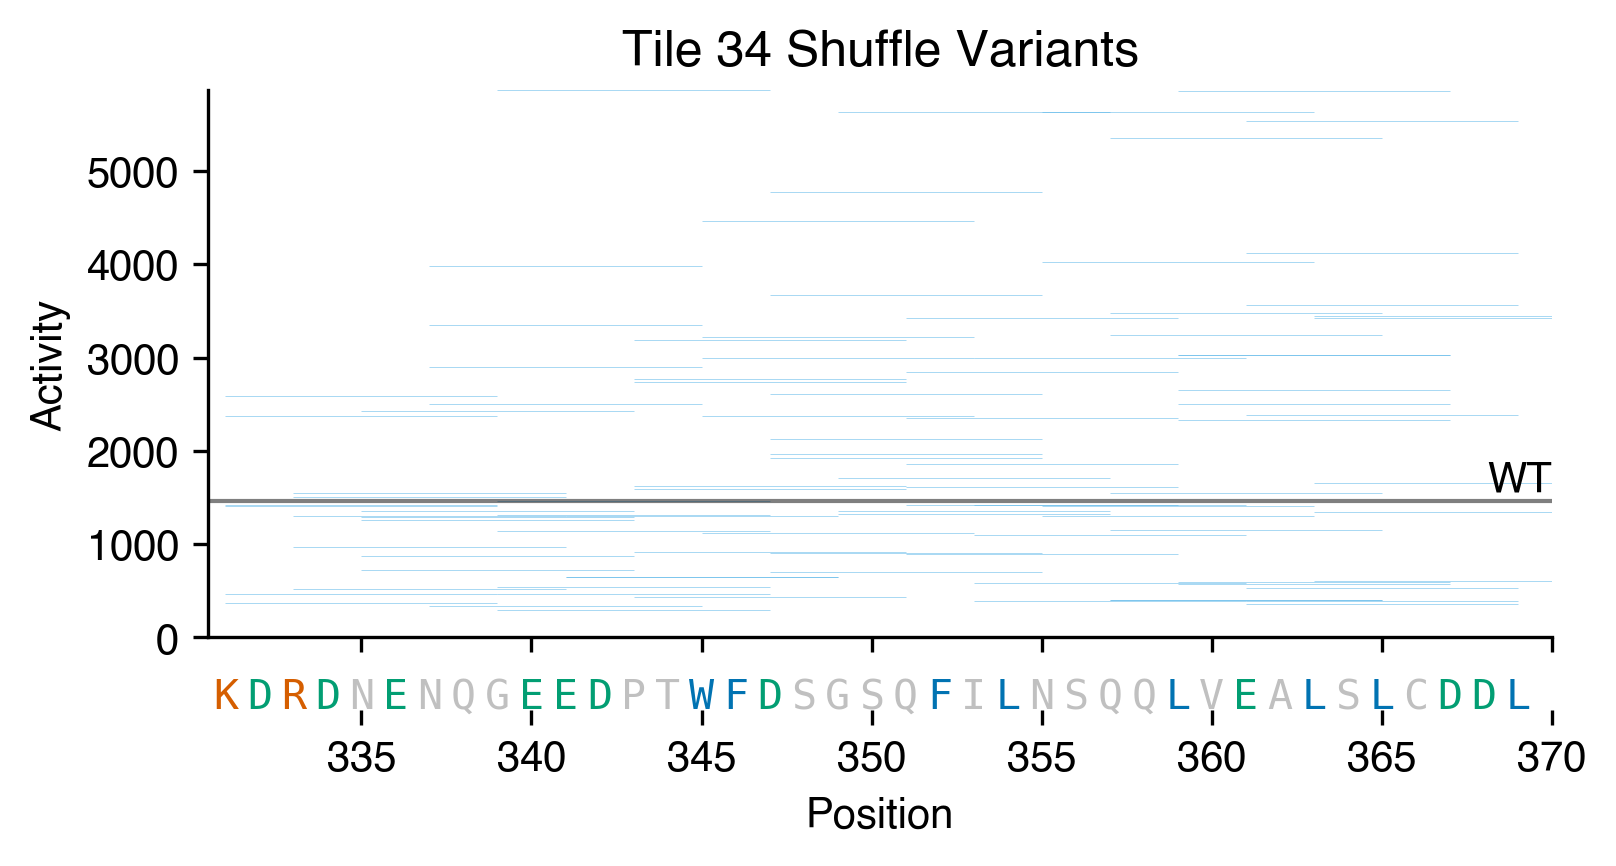

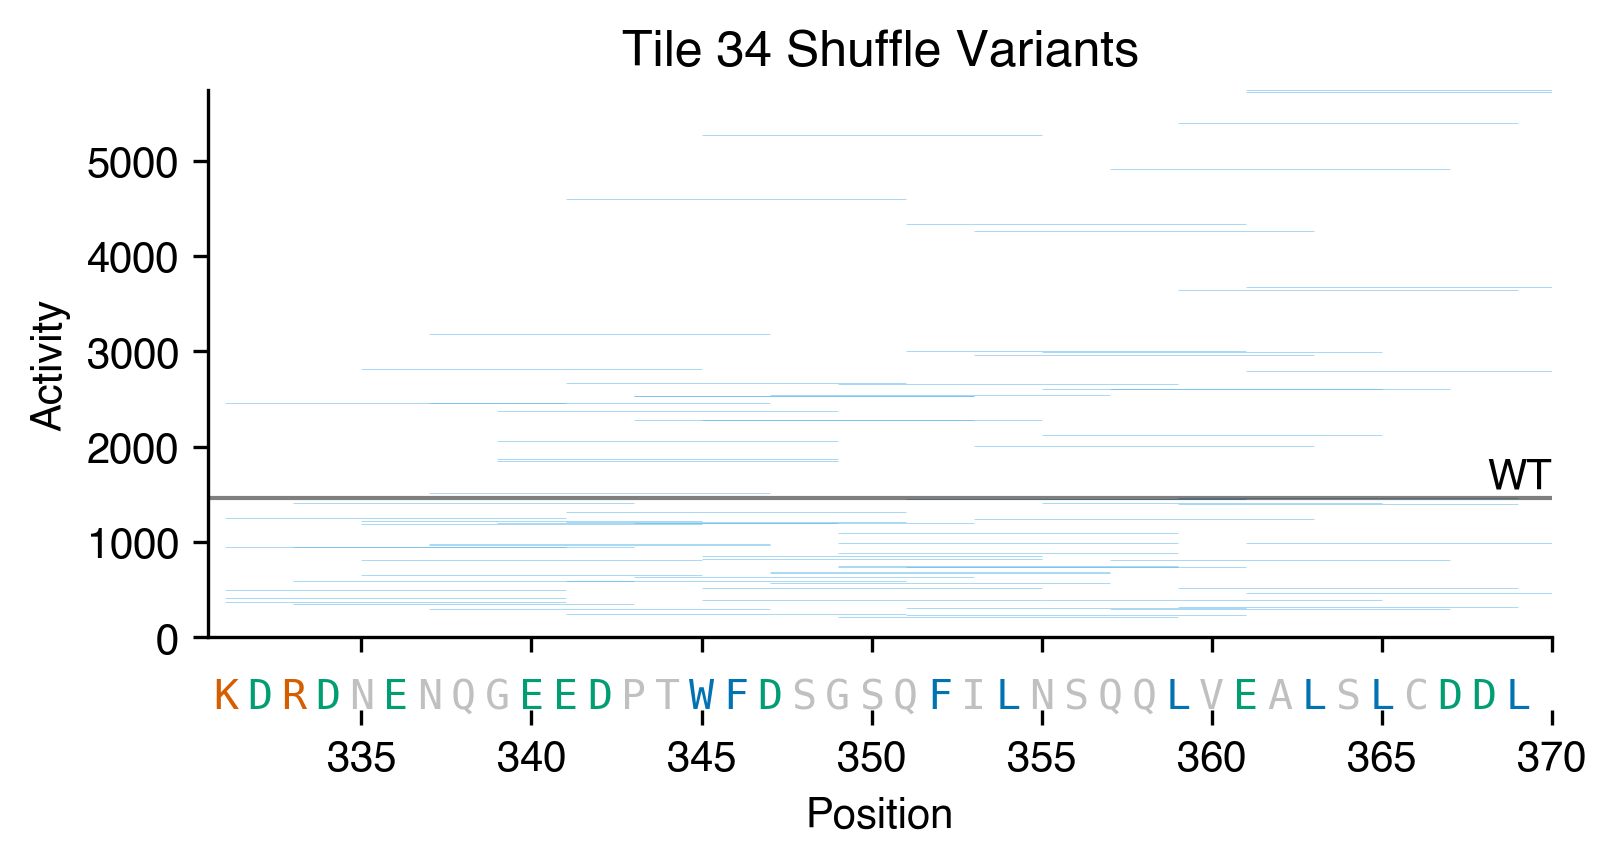

In [31]:
for shuffle_size in [2, 4, 6, 8, 10]:
    df = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == 34]
    df = df[df["shuffle_size"] == shuffle_size]
    plot_shuffles(df)

# Alanines

In [32]:
Ascan = sog1_helpers.return_activities("Ascan")
Ascan_s = Ascan[~Ascan["Description"].str.contains("comb")]#["Other"].value_counts()
Ascan_s

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,21,60,3_Ascan_1-4,NaN,41,AAAADPRQVVWKSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,NaN,NaN,NaN
1,21,60,3_Ascan_5-8,NaN,41,SASSAAAAVVWKSNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,NaN,NaN,NaN
2,21,60,3_Ascan_9-12,NaN,41,SASSDPRQAAAASNPSRHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,NaN,NaN,NaN
3,21,60,3_Ascan_13-16,NaN,41,SASSDPRQVVWKAAAARHCPKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,NaN,NaN,NaN
4,21,60,3_Ascan_17-20,NaN,41,SASSDPRQVVWKSNPSAAAAKCQHVIDNSDAVDDWPGLPR,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
175,410,449,42_Ascan_21-24,NaN,430,QKIVLDPSNIELDTPPEFRLAAAAFGSQDSFLAWGTGKTD,5585.0,695.992360,NaN,1.0,NaN,NaN
176,410,449,42_Ascan_25-28,NaN,430,QKIVLDPSNIELDTPPEFRLSQLEAAAADSFLAWGTGKTD,5626.0,1663.761747,NaN,1.0,NaN,NaN
177,410,449,42_Ascan_29-32,NaN,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQAAAAAWGTGKTD,NaN,NaN,NaN,NaN,NaN,NaN
178,410,449,42_Ascan_33-36,NaN,430,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAAAAGKTD,5666.0,791.840490,NaN,1.0,NaN,NaN


In [33]:
Ascan_s["tile_num"] = Ascan_s["Description"].str.split("_").str[0].astype(int)
Ascan_s["var_start"] = Ascan_s["Description"].str.split("_").str[-1].str.split("-").str[0].astype(int) + Ascan_s["Start"] - 1
Ascan_s["var_end"] = Ascan_s["Description"].str.split("_").str[-1].str.split("-").str[1].astype(int) + Ascan_s["Start"] - 1
Ascan_s["var_start"] = Ascan_s["var_start"].astype(int)
Ascan_s["var_end"] = Ascan_s["var_end"].astype(int)
Ascan_s = Ascan_s.dropna(subset = activity_col)
Ascan_s

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,tile_num,var_start,var_end
82,311,350,32_Ascan_9-12,NaN,331,LEHGLENGAAAALDDKEEQEKDRDNENQGEEDPTWFDSGS,4480.0,238.140026,NaN,1.0,NaN,NaN,32,319,322
86,311,350,32_Ascan_25-28,NaN,331,LEHGLENGAKEMLDDKEEQEKDRDAAAAGEEDPTWFDSGS,4530.0,1361.812856,880.631661,2.0,481.181195,2242.444517,32,335,338
91,321,360,33_Ascan_5-8,NaN,341,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2195.0,190.030157,NaN,1.0,NaN,NaN,33,325,328
94,321,360,33_Ascan_17-20,NaN,341,EMLDDKEEQEKDRDNEAAAAEDPTWFDSGSQFILNSQQLV,2277.0,410.195007,119.150579,3.0,291.044429,529.345586,33,337,340
95,321,360,33_Ascan_21-24,NaN,341,EMLDDKEEQEKDRDNENQGEAAAAWFDSGSQFILNSQQLV,2297.0,1126.796989,1219.169263,2.0,-92.372274,2345.966251,33,341,344
97,321,360,33_Ascan_29-32,NaN,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSAAAAILNSQQLV,2351.0,3072.682257,NaN,1.0,NaN,NaN,33,349,352
99,321,360,33_Ascan_37-40,NaN,341,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSAAAA,2385.0,1801.272060,NaN,1.0,NaN,NaN,33,357,360
100,331,370,34_Ascan_1-4,NaN,351,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,29.0,3029.102526,2430.172681,2.0,598.929845,5459.275208,34,331,334
101,331,370,34_Ascan_5-8,NaN,351,KDRDAAAAGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,3604.0,1169.831387,NaN,1.0,NaN,NaN,34,335,338
102,331,370,34_Ascan_9-12,NaN,351,KDRDNENQAAAAPTWFDSGSQFILNSQQLVEALSLCDDLL,3638.0,3662.861102,NaN,1.0,NaN,NaN,34,339,342


In [34]:
Ascan_s["tile_num"].value_counts()

tile_num
34    9
42    7
36    6
33    5
35    5
37    5
40    4
41    3
32    2
38    2
Name: count, dtype: int64

In [35]:
Ascan_s_with_diff = sog1_helpers.add_all_var_positions(Ascan_s, BasicArTh, activity_col, add_AAs = True)
Ascan_s_with_diff.head(3)

,Start,End,Description_var,Other_var,mid,tile_var,Unnamed: 0_var,Activity_S3_1_var,Error_var,BC Count_var,...,Other_wt,tile_wt,Unnamed: 0_wt,Activity_S3_1_wt,Error_wt,BC Count_wt,activ_err_start_wt,activ_err_end_wt,vars,AAs
0,311,350,32_Ascan_9-12,NaN,331,LEHGLENGAAAALDDKEEQEKDRDNENQGEEDPTWFDSGS,4480.0,238.140026,NaN,1.0,...,Q6NQK2,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,4546,594.768770,503.391459,11,91.377311,1098.160228,"[320, 321, 322]","[K, E, M]"
1,311,350,32_Ascan_25-28,NaN,331,LEHGLENGAKEMLDDKEEQEKDRDAAAAGEEDPTWFDSGS,4530.0,1361.812856,880.631661,2.0,...,Q6NQK2,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,4546,594.768770,503.391459,11,91.377311,1098.160228,"[335, 336, 337, 338]","[N, E, N, Q]"
2,321,360,33_Ascan_5-8,NaN,341,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2195.0,190.030157,NaN,1.0,...,Q6NQK2,EMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,2388,1002.138898,695.599801,18,306.539098,1697.738699,"[325, 326, 327, 328]","[D, K, E, E]"


In [64]:
def plot_tile_Ascan(tile):
    one_tile_Ascan = Ascan_s_with_diff[Ascan_s_with_diff["tile_num"] == tile]  
    
    fig, axs = plt.subplots(2, 1, sharex = True, figsize = (5,1.5), dpi = 300, gridspec_kw={'height_ratios': [1, 0.15]})

    ax1, ax2 = axs[0], axs[1]
    
    max_y = 0
    for i in range(len(one_tile_Ascan)):
        ax1.hlines(y=one_tile_Ascan[activity_col + "_var"].iloc[i], 
                   xmin=one_tile_Ascan["var_start"].iloc[i] - 0.5, 
                   xmax=one_tile_Ascan["var_end"].iloc[i] + 0.5, 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-')
        max_y = max(max_y, one_tile_Ascan[activity_col + "_var"].iloc[i])
        

    ax1.errorbar(0.5 * (one_tile_Ascan["var_start"] + one_tile_Ascan["var_end"]), 
                one_tile_Ascan[activity_col + "_var"], 
                yerr=[one_tile_Ascan["Error_var"], one_tile_Ascan["Error_var"]], 
                fmt='none', 
                ecolor='silver', 
                elinewidth=1, 
                capsize=2, 
                zorder = 2, alpha = 0.5)
                           
    ax1.axhline(one_tile_Ascan[activity_col + "_wt"].iloc[0], lw = 2, color = 'gray', alpha = 0.5)

    # Get the lower and upper bounds
    lower = one_tile_Ascan[activity_col + "_wt"].iloc[0] - one_tile_Ascan["Error_wt"].iloc[0]
    upper = one_tile_Ascan[activity_col + "_wt"].iloc[0] + one_tile_Ascan["Error_wt"].iloc[0]

    # Fill the region between the lines
    ax1.axhspan(lower, upper, color='gray', alpha=0.2)

    ax1.set_xlim(one_tile_Ascan["Start"].iloc[i] - 0.5, one_tile_Ascan["End"].iloc[i])    
    #ax1.set_ylim(0, max_y)
    ax1.text(x = one_tile_Ascan["End"].iloc[i], y = one_tile_Ascan[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")
    
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(one_tile_Ascan["Start"].iloc[i],
        one_tile_Ascan["End"].iloc[i] ):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax2.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')

    ax2.set_ylim(0.8, 1)
                
    ax1.set_title("Tile " + str(tile) + ": Alanine Scan")
    plt.tight_layout(pad=0)

    sns.despine(ax = ax1, left = False)
    sns.despine(ax = ax2, left = True, bottom = True)

    # for pos in np.arange(one_tile_Ascan["Start"].iloc[i],
    #     one_tile_Ascan["End"].iloc[i] ):
    #     if (pos - one_tile_Ascan["Start"].iloc[i]) % 4 == 0:
    #         ax1.axvline(pos- 0.5, color = 'silver', alpha = 0.5)

    #ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax1.set_ylabel("Activity")
    ax2.set_xlabel("Position")


In [62]:
! mkdir ../output/figures/Ascan

mkdir: ../output/figures/Ascan: File exists


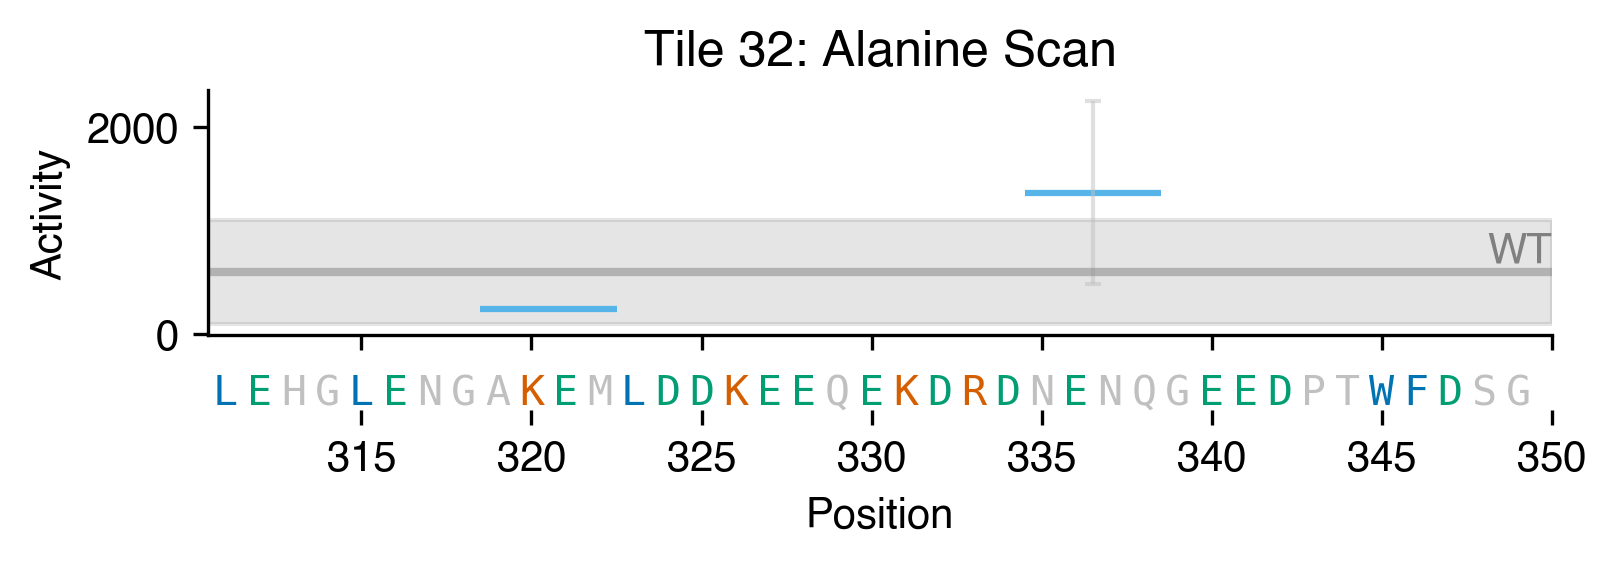

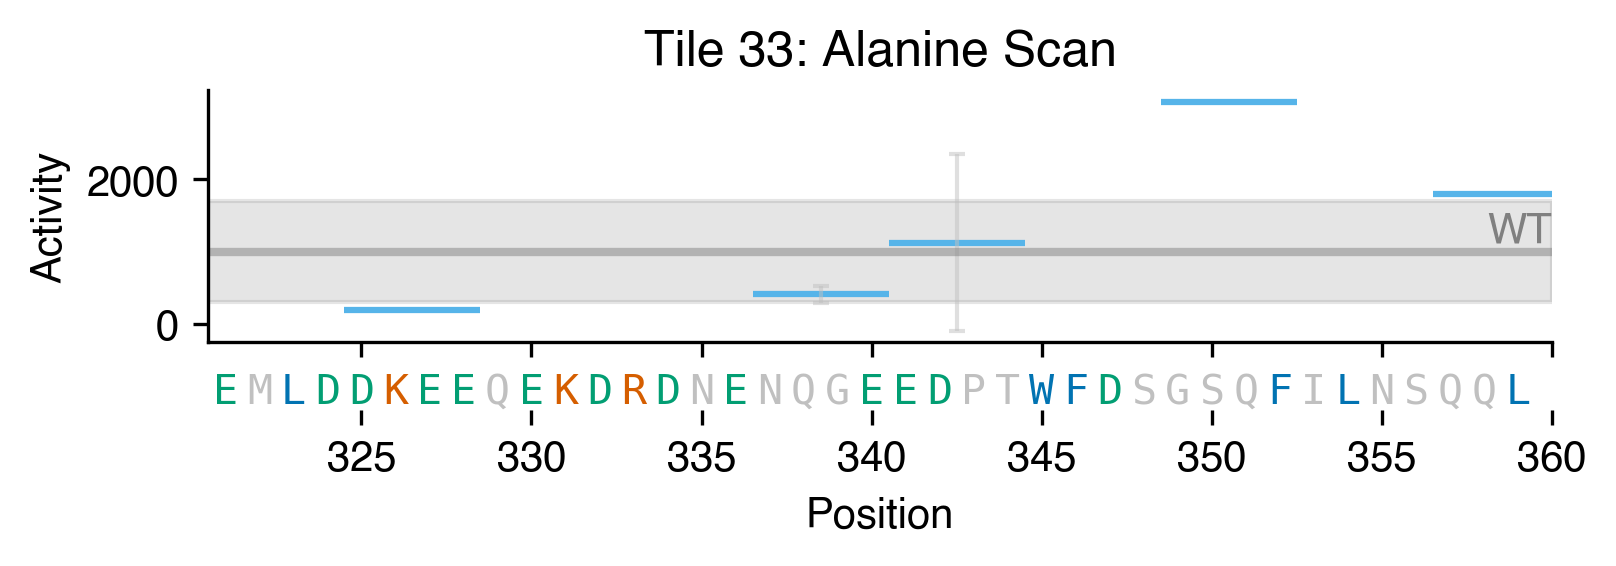

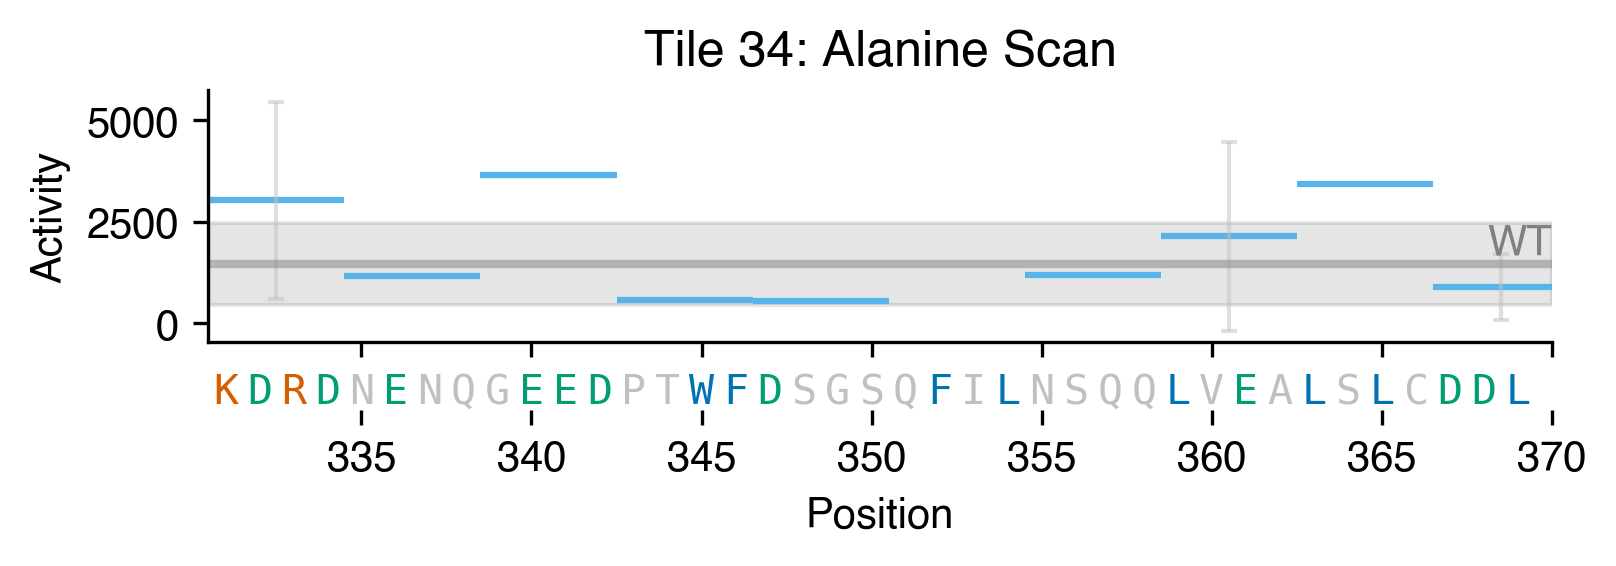

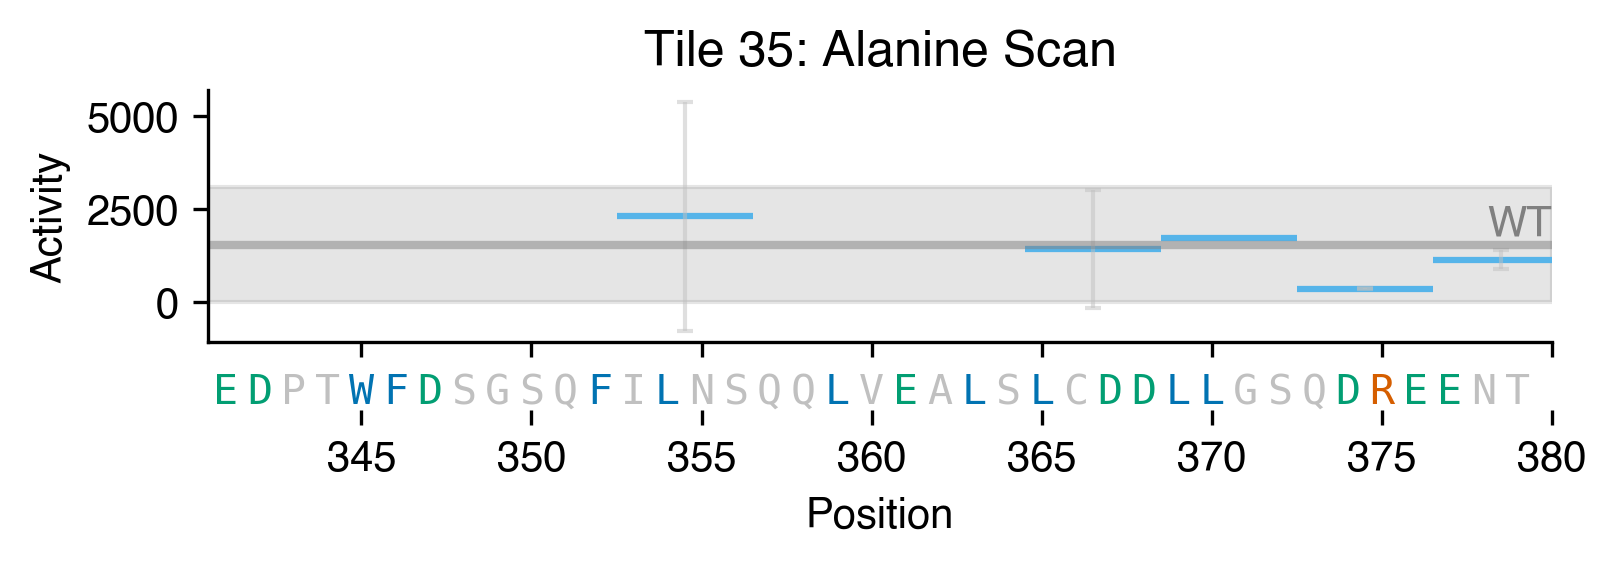

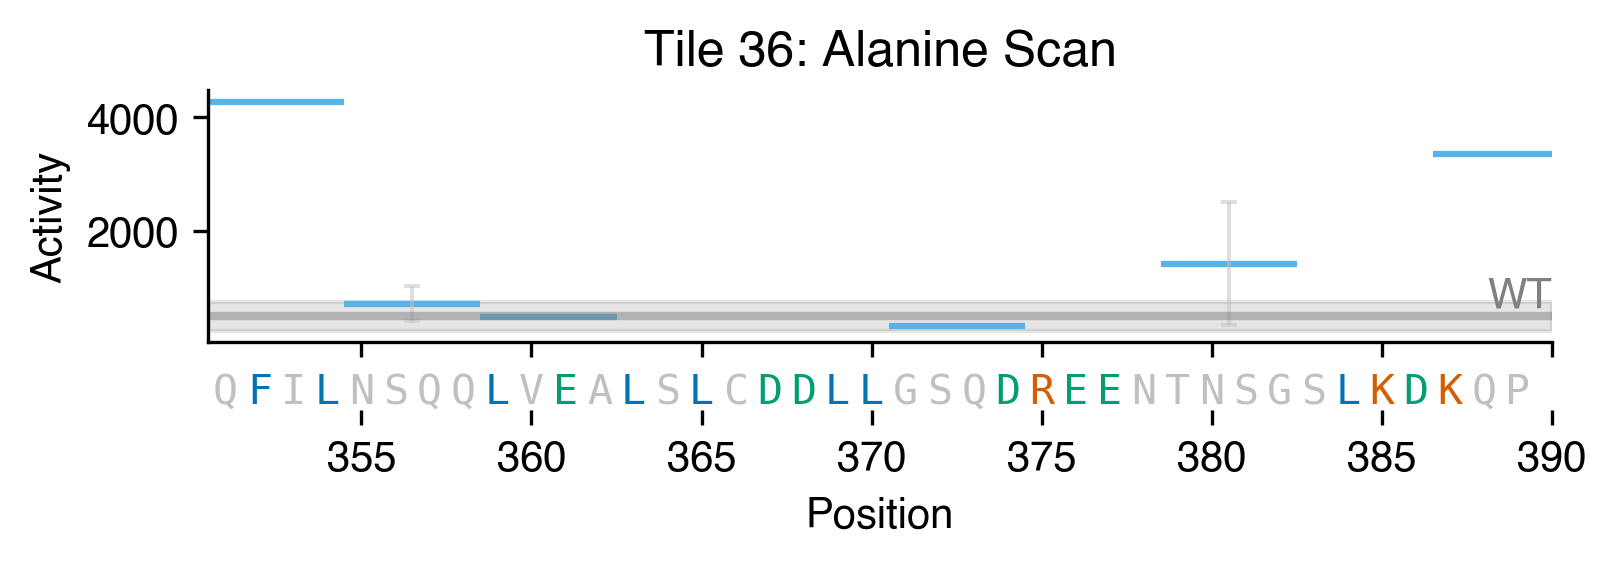

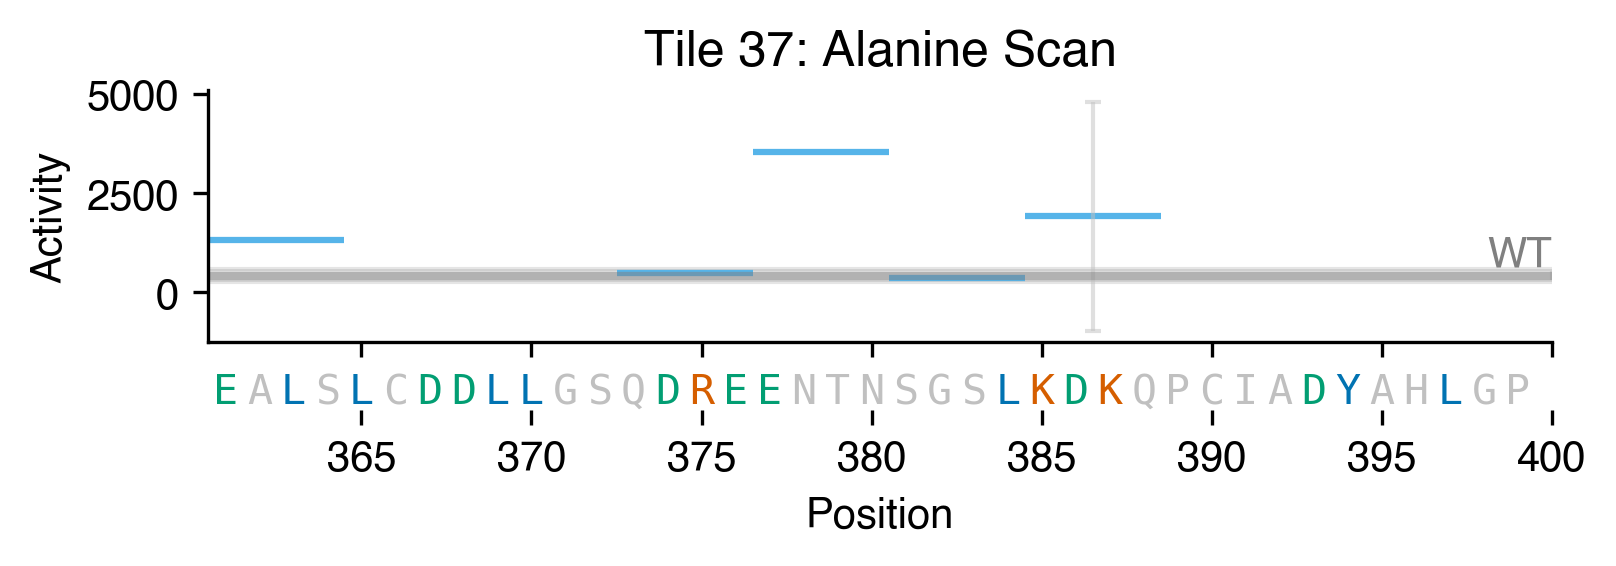

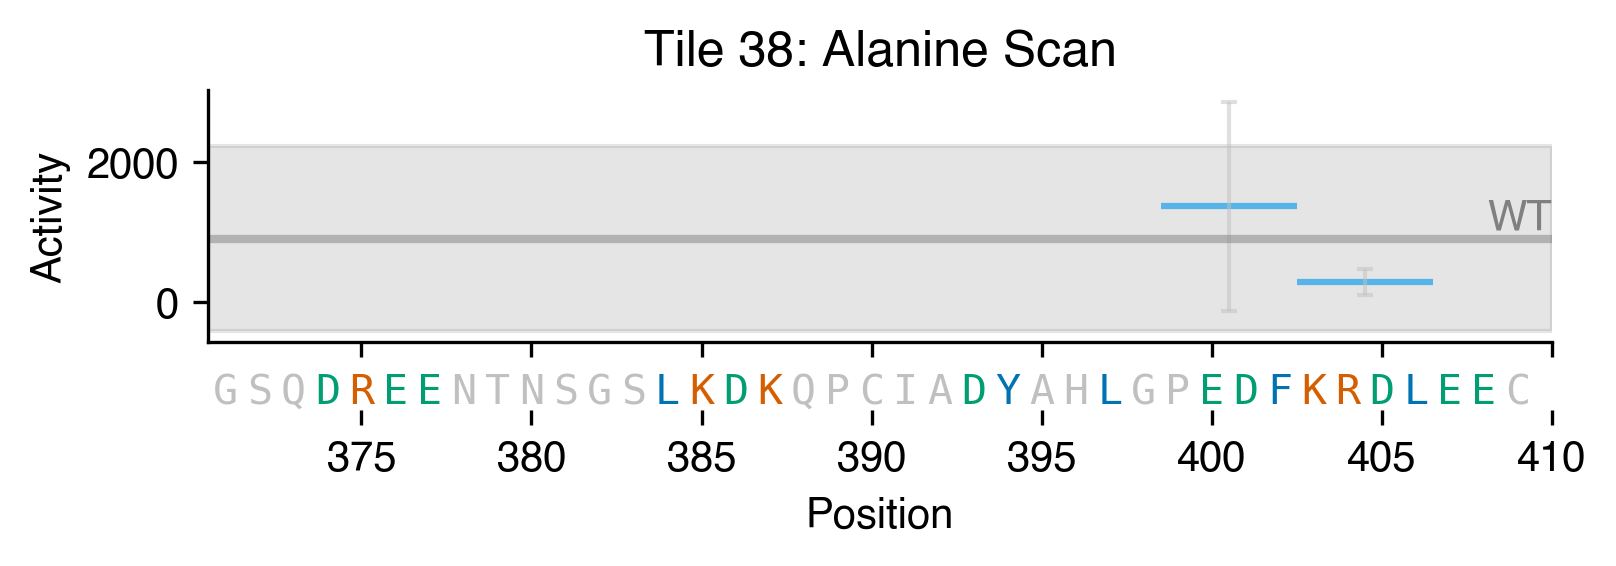

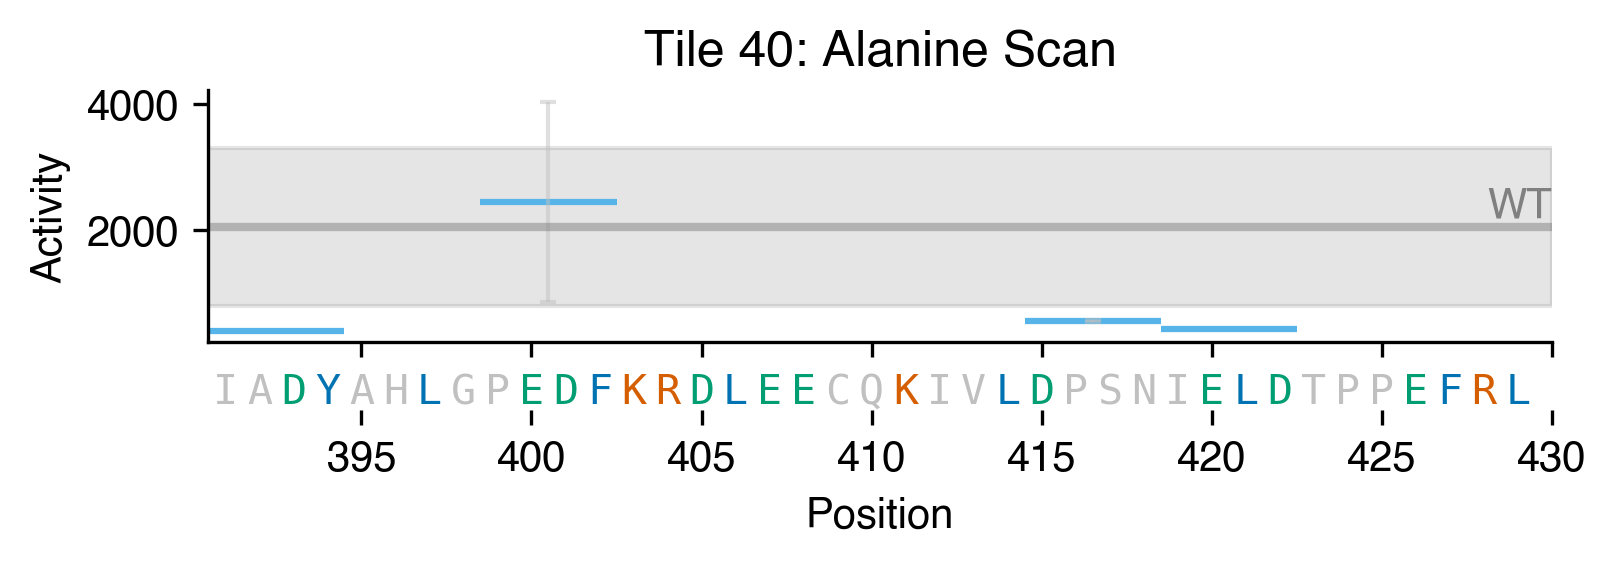

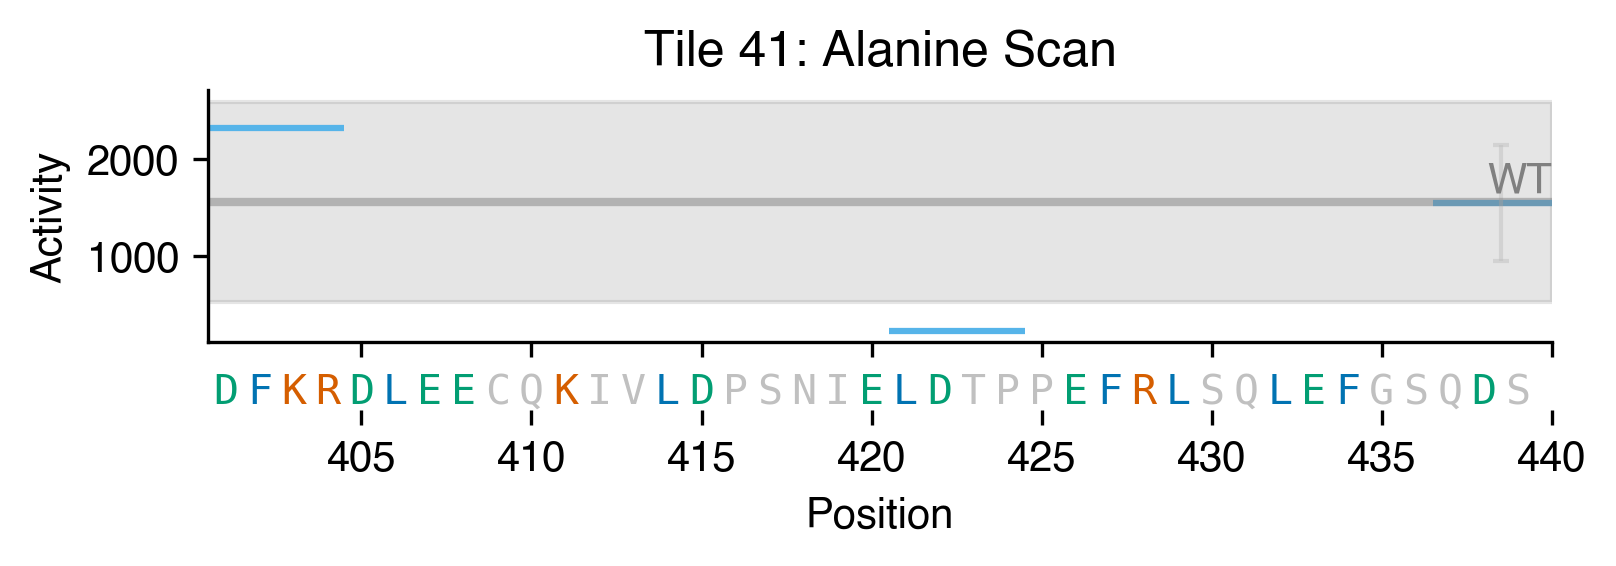

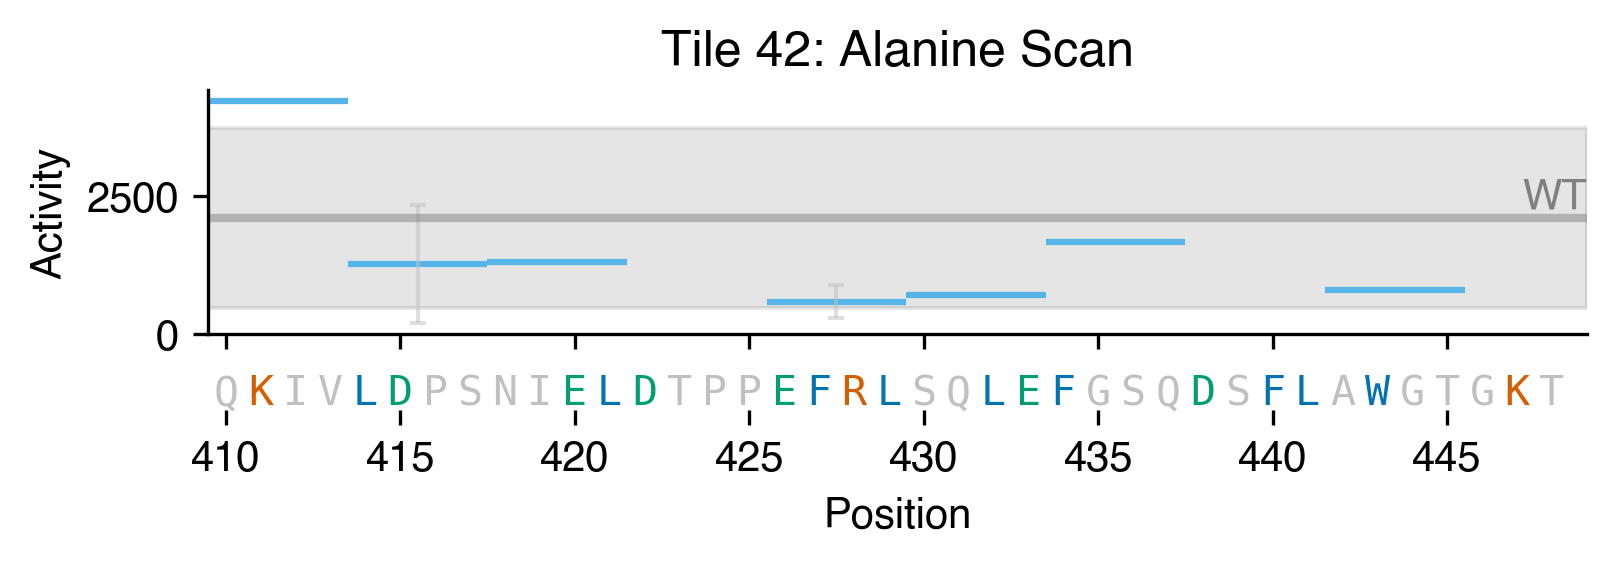

In [63]:
for i in Ascan_s["tile_num"].unique():
    plot_tile_Ascan(i)
    plt.savefig("../output/figures/Ascan/" + str(i) + ".png")

In [39]:
Ascan_s["tile_num"].unique()

array([32, 33, 34, 35, 36, 37, 38, 40, 41, 42])

In [90]:
Ascan_s["tile_num"].value_counts()

tile_num
41    10
42     9
32     8
34     8
35     8
36     8
37     8
40     8
38     7
33     6
Name: count, dtype: int64

# Add A scan below shuffle

In [69]:
def plot_shuffles_and_A_scan(tile):
    one_tile_shuffles = shuffle_vars_with_diff[shuffle_vars_with_diff["tile"] == tile]
    
    fig, axs = plt.subplots(3, 1, sharex = True, figsize = (5,3), dpi = 300, gridspec_kw={'height_ratios': [1, 0.5, 0.1]})

    ax1, ax2, ax3 = axs[0], axs[1], axs[2]
    
    max_y = 0
    
    for i in range(len(one_tile_shuffles)):
        row_vars = one_tile_shuffles["vars"].iloc[i]
        ax1.hlines(y=one_tile_shuffles[activity_col + "_var"].iloc[i], 
                   xmin=min(row_vars), 
                   xmax=max(row_vars), 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-', alpha = 0.6, lw = 0.2)
        max_y = max(max_y, one_tile_shuffles[activity_col + "_var"].iloc[i])
        
    ax1.axhline(one_tile_shuffles[activity_col + "_wt"].iloc[0], lw = 2, color = 'gray', alpha = 0.5)

    ax1.set_xlim(one_tile_shuffles["Start"].iloc[i] - 0.5, one_tile_shuffles["End"].iloc[i])    
    ax1.set_ylim(0, max_y)
    ax1.text(x = one_tile_shuffles["End"].iloc[i], y = one_tile_shuffles[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")
    
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(one_tile_shuffles["Start"].iloc[i],
        one_tile_shuffles["End"].iloc[i] ):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax3.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')
                
    ax1.set_title("Tile " + str(one_tile_shuffles["tile"].iloc[i]))
    plt.tight_layout(pad=0)


    ax3.set_yticks([])
    ax1.set_ylabel("Shuffle\nActivity", rotation = 0, labelpad = 25)
    ax2.set_ylabel("Alanine\nScan\nActivity", rotation = 0, labelpad = 25)
    ax3.set_xlabel("Position")



    one_tile_Ascan = Ascan_s_with_diff[Ascan_s_with_diff["tile_num"] == tile]  
    

    max_y = 0
    for i in range(len(one_tile_Ascan)):
        ax2.hlines(y=one_tile_Ascan[activity_col + "_var"].iloc[i], 
                   xmin=one_tile_Ascan["var_start"].iloc[i] - 0.5, 
                   xmax=one_tile_Ascan["var_end"].iloc[i] + 0.5, 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-')
        max_y = max(max_y, one_tile_Ascan[activity_col + "_var"].iloc[i])
        
    ax2.errorbar(0.5 * (one_tile_Ascan["var_start"] + one_tile_Ascan["var_end"]), 
                one_tile_Ascan[activity_col + "_var"], 
                yerr=[one_tile_Ascan["Error_var"], one_tile_Ascan["Error_var"]], 
                fmt='none', 
                ecolor='silver', 
                elinewidth=1, 
                capsize=2, 
                zorder = 2, alpha = 0.5)
                           
    ax2.axhline(one_tile_Ascan[activity_col + "_wt"].iloc[0], lw = 2, color = 'gray', alpha = 0.5)

    # Get the lower and upper bounds
    lower = one_tile_Ascan[activity_col + "_wt"].iloc[0] - one_tile_Ascan["Error_wt"].iloc[0]
    upper = one_tile_Ascan[activity_col + "_wt"].iloc[0] + one_tile_Ascan["Error_wt"].iloc[0]

    # Fill the region between the lines
    ax2.axhspan(lower, upper, color='gray', alpha=0.2)  
                           
    ax2.axhline(one_tile_Ascan[activity_col + "_wt"].iloc[0], lw = 2, color = 'gray', alpha = 0.5)
    ax2.text(x = one_tile_Ascan["End"].iloc[i], y = one_tile_Ascan[activity_col + "_wt"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")

    sns.despine()
    sns.despine(ax = ax3, left = True, bottom = True)

    x_ticks = np.arange(one_tile_shuffles["Start"].iloc[i], one_tile_shuffles["End"].iloc[i], 4)
    ax1.set_xticks(x_ticks, x_ticks)

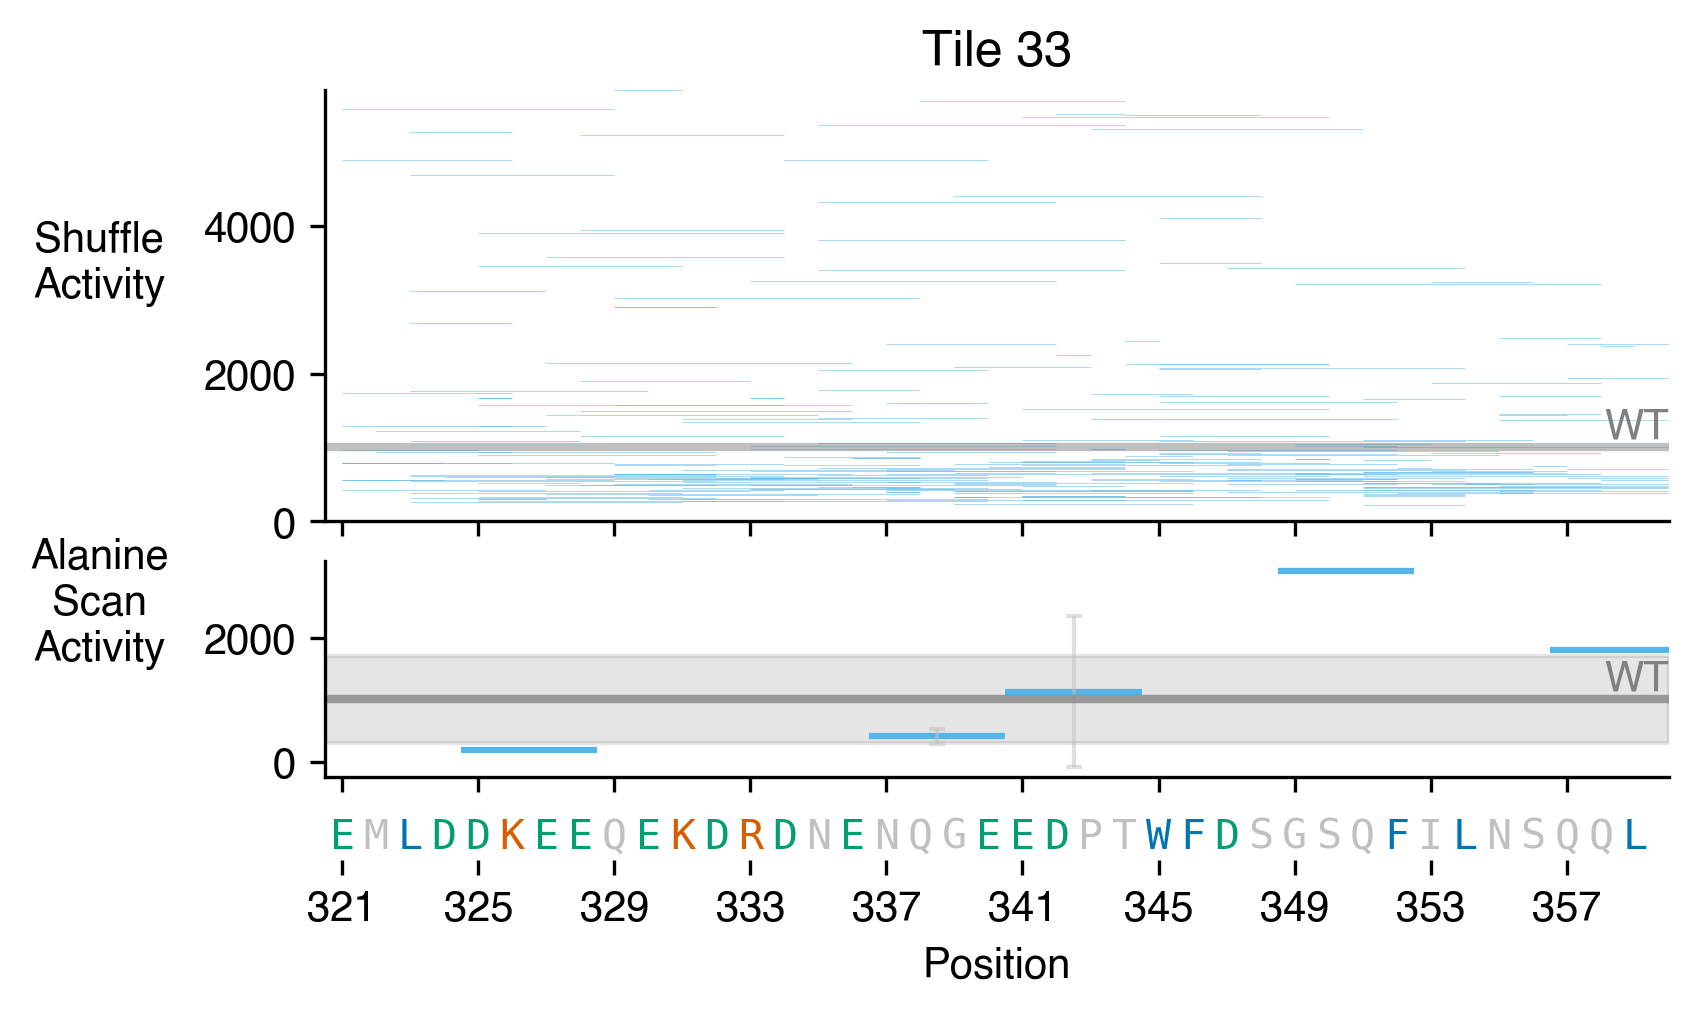

In [71]:
plot_shuffles_and_A_scan(33)

In [93]:
! mkdir ../output/figures/shuffles_and_Ascan/

mkdir: ../output/figures/shuffles_and_Ascan/: File exists


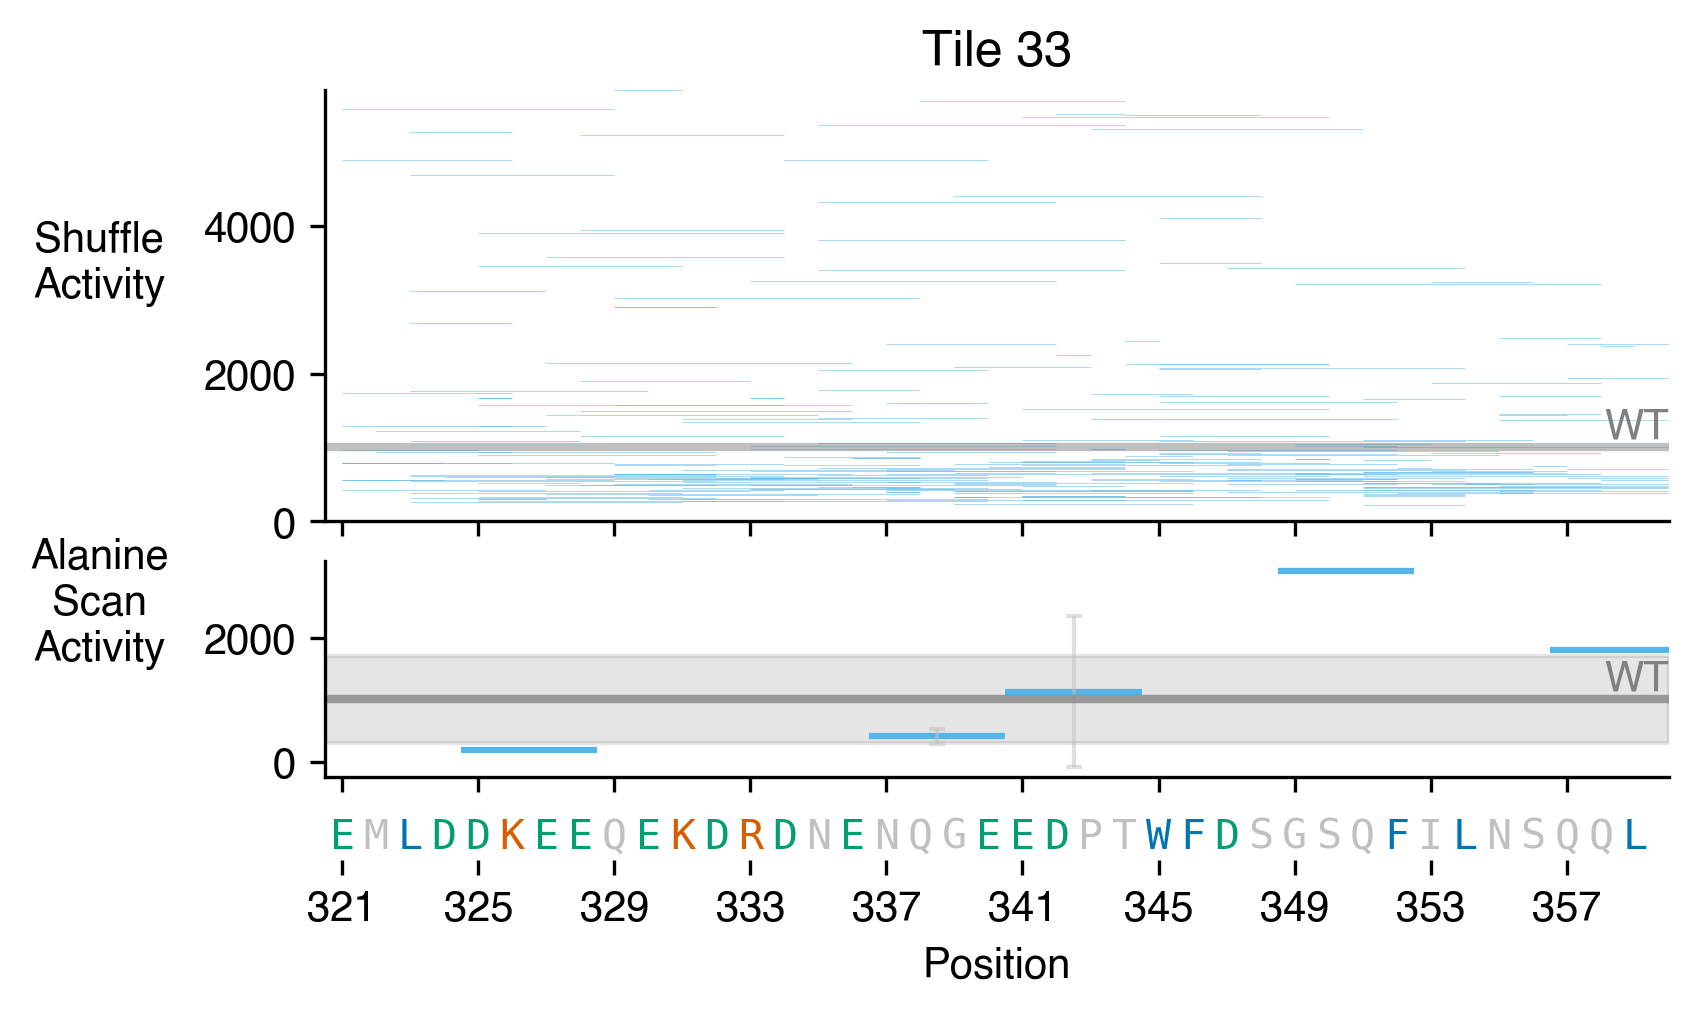

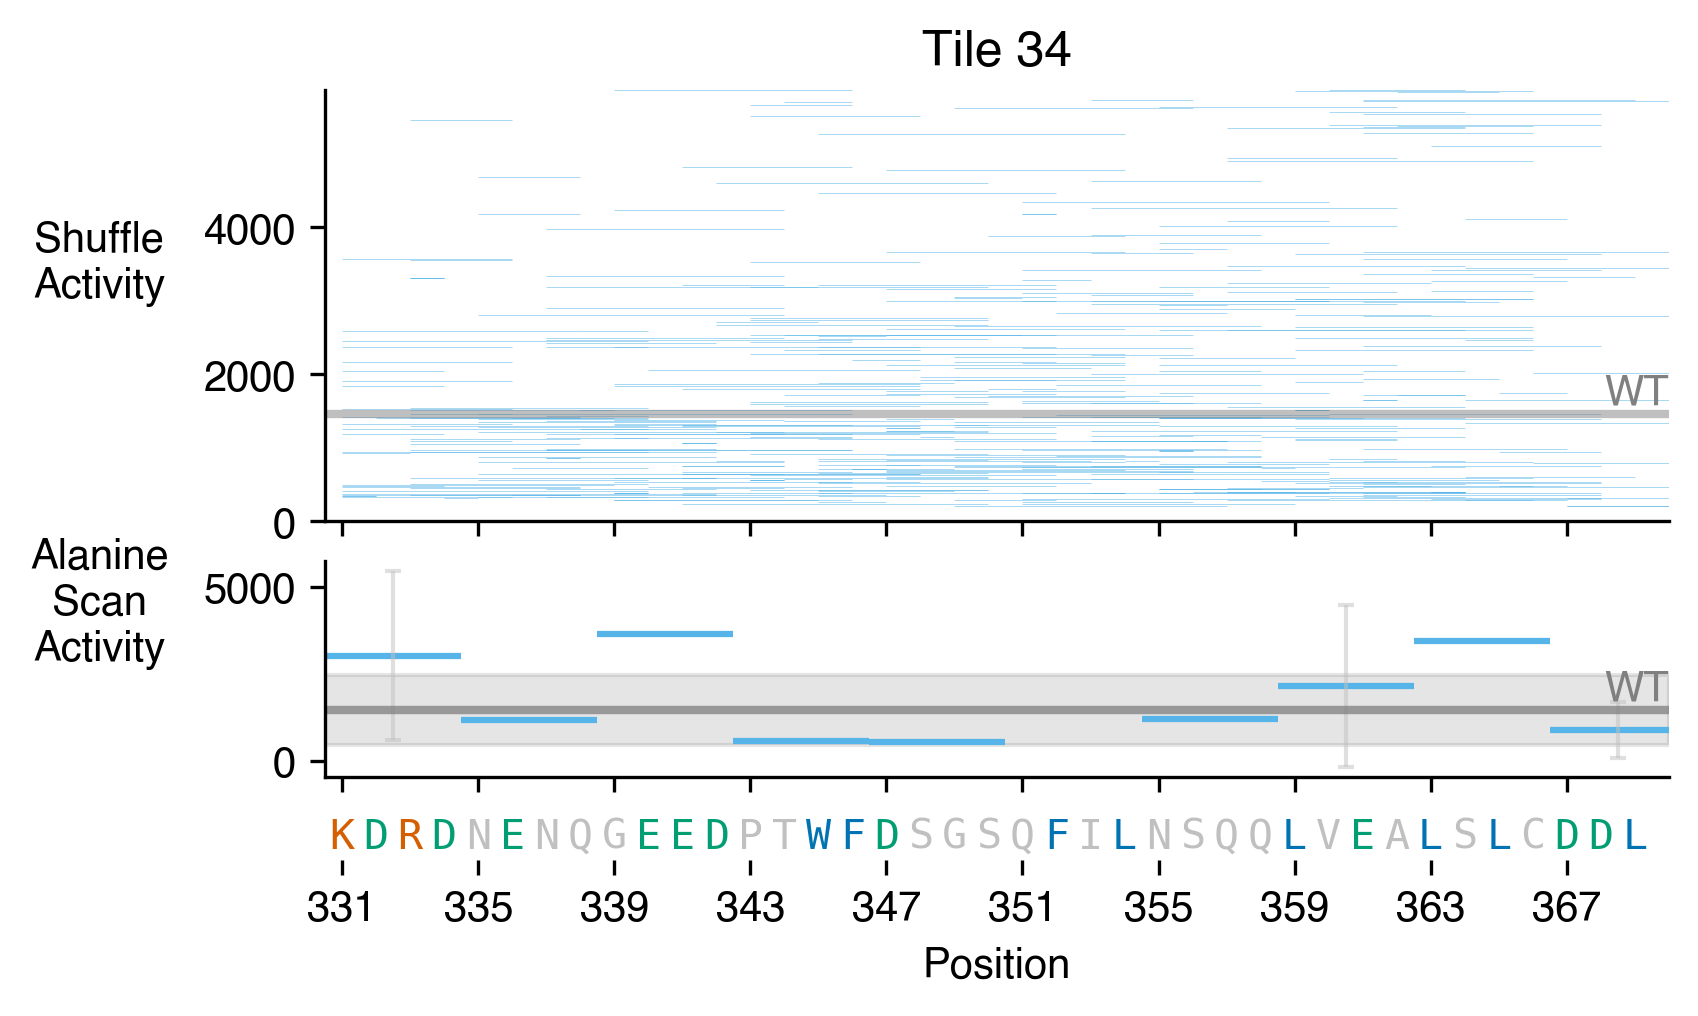

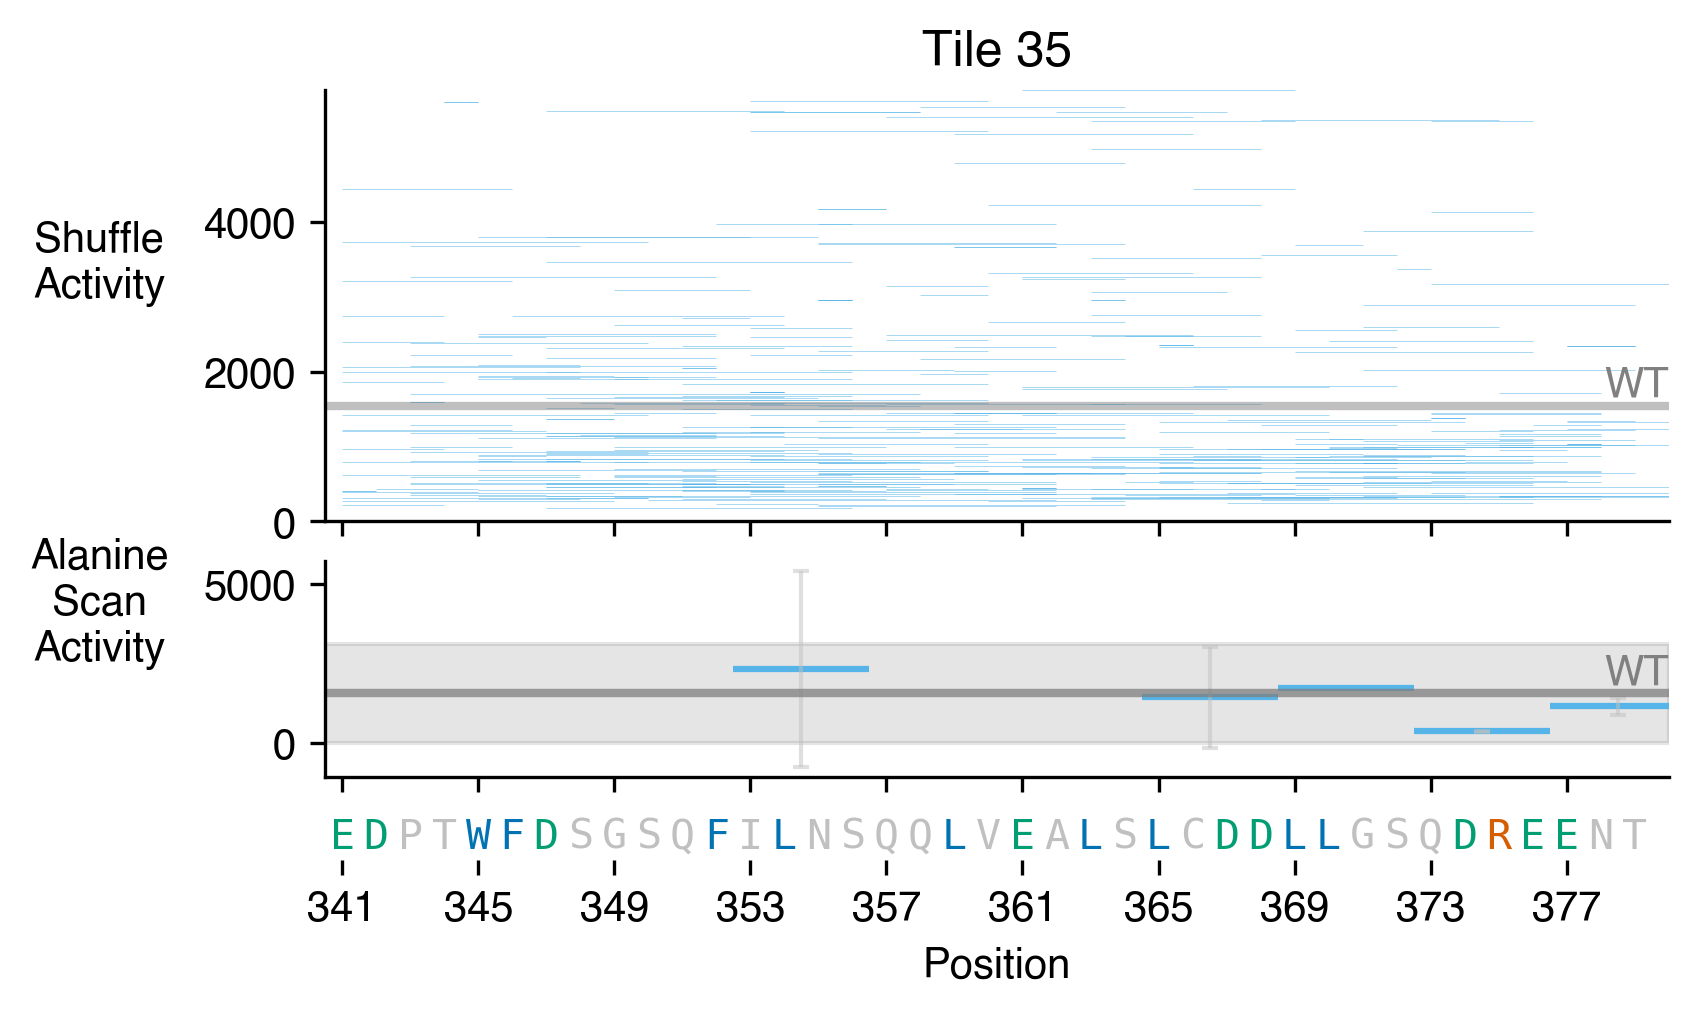

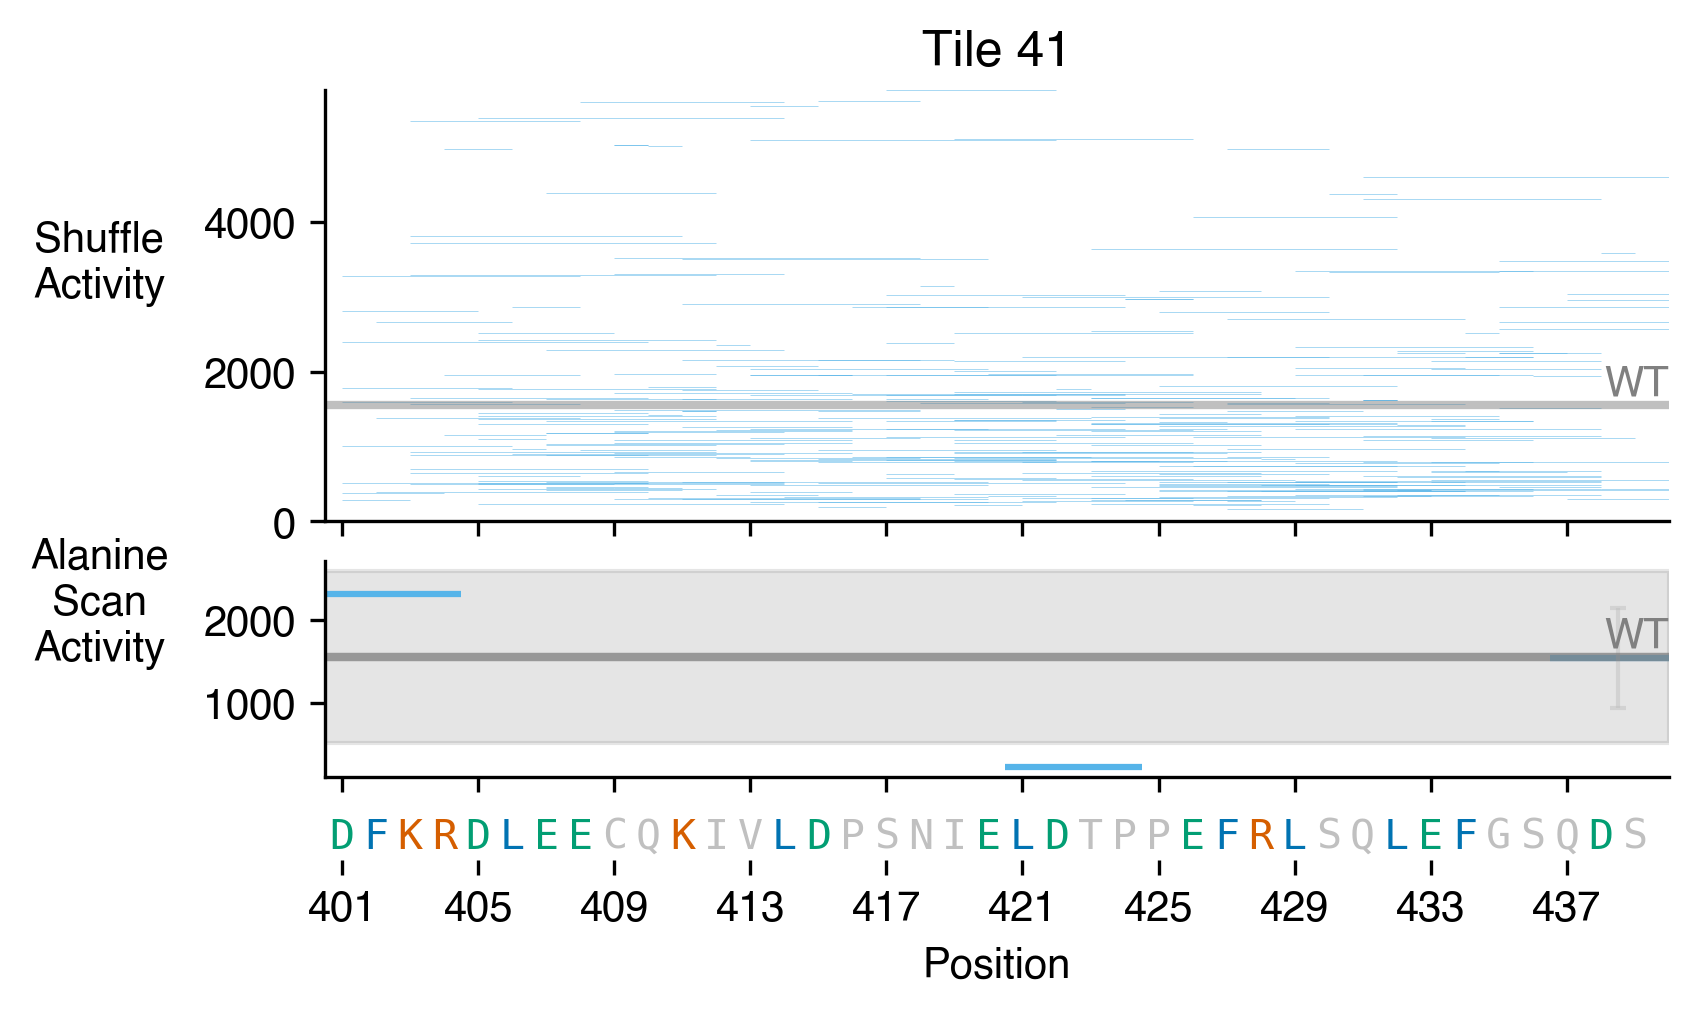

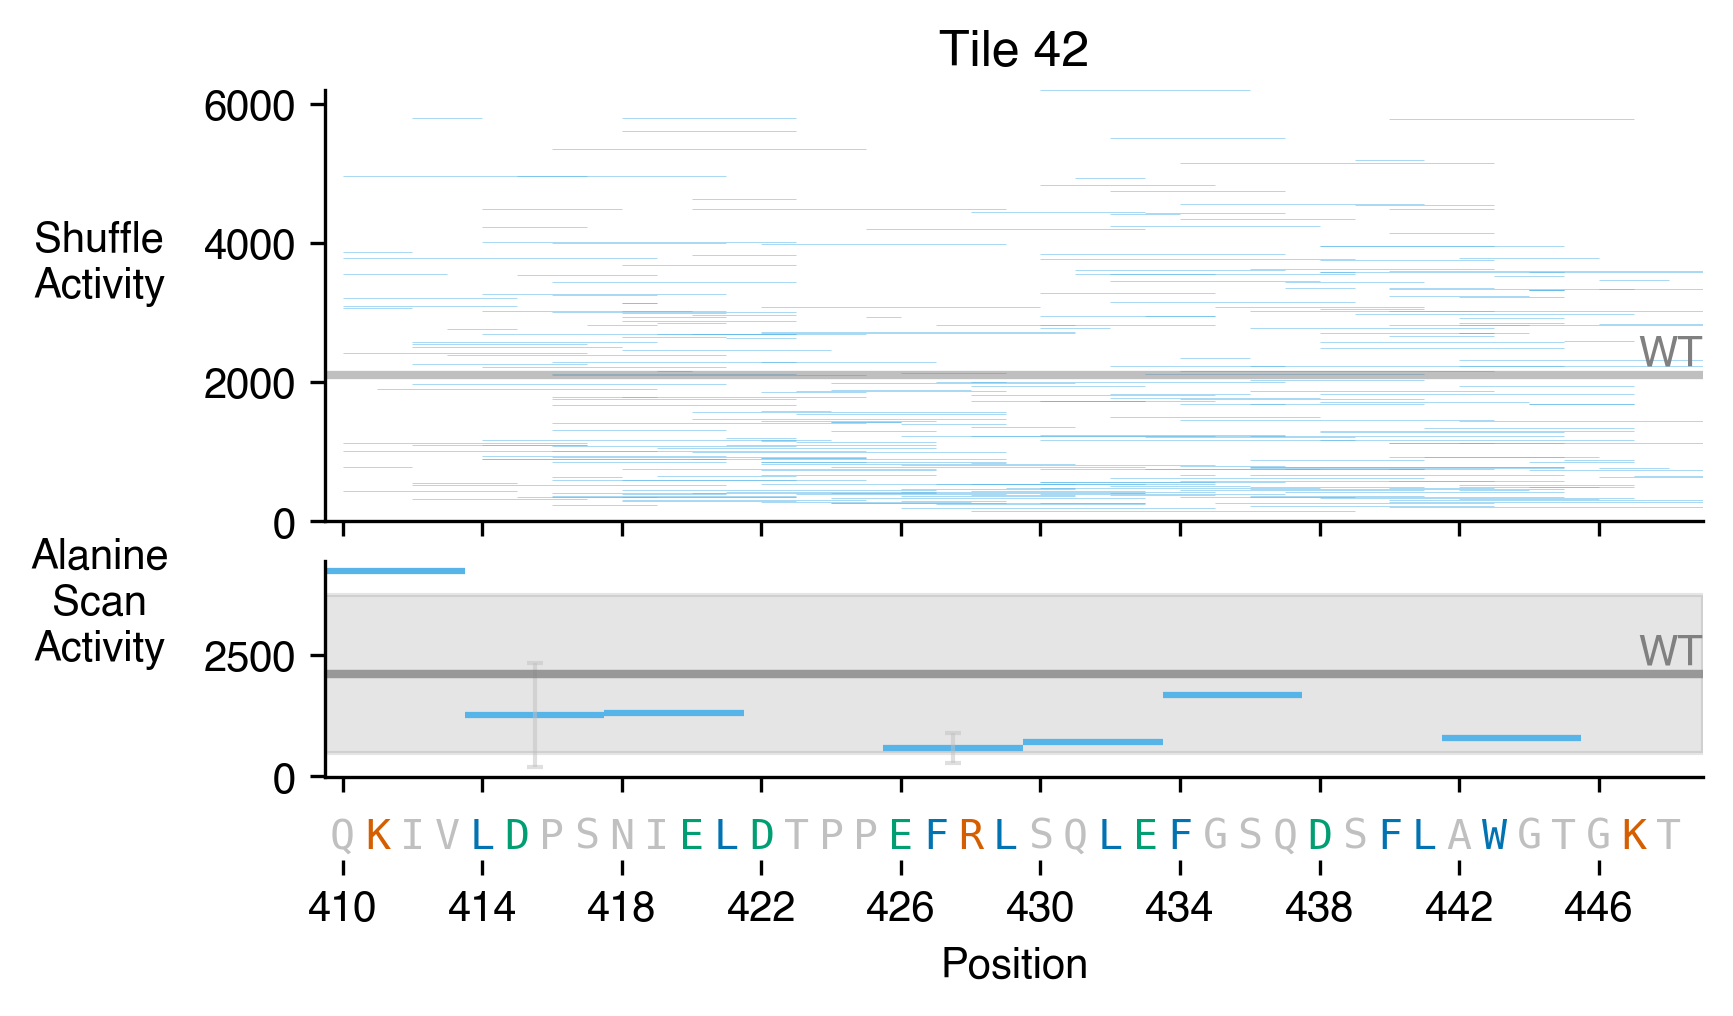

In [72]:
for tile_num in list(set(shuffle_vars_with_diff["tile"]) & set(Ascan_s_with_diff["tile_num"])):
    plot_shuffles_and_A_scan(tile_num)
    plt.savefig("../output/figures/shuffles_and_Ascan/" + str(tile_num) + ".png")

# A scan and shuffles

In [116]:
Ascan_s_with_diff["var_end_adj"] = Ascan_s_with_diff["var_end"] + 1
Ascan_s_with_diff[["var_start", "var_end_adj", "tile_num"]]

,var_start,var_end_adj,tile_num
0,315,319,32
1,319,323,32
2,323,327,32
3,331,335,32
4,335,339,32
...,...,...,...
75,430,434,42
76,434,438,42
77,438,442,42
78,442,446,42


In [117]:
shuffle_vars_with_diff["tile_num"] = shuffle_vars_with_diff["Description_var"].str.split("_").str[0].astype(int)
shuffle_vars_with_diff[["pos_start", "pos_end", "tile_num"]]

,pos_start,pos_end,tile_num
0,321,323,33
1,323,325,33
2,325,327,33
3,329,331,33
4,331,333,33
...,...,...,...
3568,440,450,42
3569,440,450,42
3570,440,450,42
3571,440,450,42


In [118]:
shuffle_Ascan_lined_up = pd.merge(Ascan_s_with_diff, 
         shuffle_vars_with_diff, 
         suffixes = ("_A", "_shuffle"), 
         left_on = ["var_start", "var_end_adj", "tile_num"], 
         right_on = ["pos_start", "pos_end", "tile_num"])
shuffle_Ascan_lined_up

,Description_var_A,Other_var_A,Start_A,mid_A,End_A,tile_var_A,Activity_S3_1_var_A,Activity_S3_2_var_A,lib2_avg_var_A,tile_num,...,Activity_S3_1_wt_shuffle,Activity_S3_2_wt_shuffle,lib2_avg_wt_shuffle,vars_shuffle,AAs_shuffle,tile,shuffle_size,coordinates,pos_start,pos_end
0,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[325, 326, 327, 328]","[D, K, E, E]",33,4,2_1,325,329
1,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[325, 326, 327]","[D, K, E]",33,4,2_2,325,329
2,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[325, 326, 327, 328]","[D, K, E, E]",33,4,2_3,325,329
3,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[326, 328]","[K, E]",33,4,2_4,325,329
4,33_Ascan_5-8,NaN,321,341,361,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,253.483884,255.626832,254.555358,33,...,940.578923,884.466877,912.522900,"[325, 326, 327]","[D, K, E]",33,4,2_5,325,329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,42_Ascan_37-40,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,356.514075,376.657884,366.585980,42,...,2221.196339,2039.845552,2130.520945,"[446, 448]","[G, T]",42,4,18_6,446,450
401,42_Ascan_37-40,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,356.514075,376.657884,366.585980,42,...,2221.196339,2039.845552,2130.520945,"[446, 447, 448, 449]","[G, K, T, D]",42,4,18_7,446,450
402,42_Ascan_37-40,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,356.514075,376.657884,366.585980,42,...,2221.196339,2039.845552,2130.520945,"[446, 447, 448, 449]","[G, K, T, D]",42,4,18_8,446,450
403,42_Ascan_37-40,NaN,410,430,450,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,356.514075,376.657884,366.585980,42,...,2221.196339,2039.845552,2130.520945,"[446, 447, 449]","[G, K, D]",42,4,18_9,446,450


In [120]:
shuffle_Ascan_lined_up[["tile_var_A", "tile_var_shuffle"]]

,tile_var_A,tile_var_shuffle
0,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDEEKDQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
1,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDEDKEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
2,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDEEDKQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
3,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDDEEKQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
4,EMLDAAAAQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV,EMLDKEDEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLV
...,...,...
400,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTTKGD
401,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTTDKG
402,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTDGKT
403,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTAAAA,QKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTKDTG


In [119]:
shuffle_Ascan_lined_up["Description_var_A"].value_counts()

Description_var_A
33_Ascan_5-8      10
35_Ascan_37-40    10
41_Ascan_5-8      10
41_Ascan_9-12     10
41_Ascan_13-16    10
41_Ascan_17-20    10
41_Ascan_21-24    10
41_Ascan_25-28    10
41_Ascan_29-32    10
41_Ascan_33-36    10
41_Ascan_37-40    10
42_Ascan_1-4      10
42_Ascan_5-8      10
42_Ascan_9-12     10
42_Ascan_17-20    10
42_Ascan_21-24    10
42_Ascan_25-28    10
42_Ascan_29-32    10
42_Ascan_33-36    10
41_Ascan_1-4      10
35_Ascan_33-36    10
33_Ascan_13-16    10
35_Ascan_29-32    10
33_Ascan_17-20    10
33_Ascan_21-24    10
33_Ascan_29-32    10
33_Ascan_37-40    10
34_Ascan_1-4      10
34_Ascan_5-8      10
34_Ascan_13-16    10
34_Ascan_21-24    10
34_Ascan_25-28    10
34_Ascan_29-32    10
34_Ascan_33-36    10
35_Ascan_1-4      10
35_Ascan_13-16    10
35_Ascan_17-20    10
35_Ascan_21-24    10
35_Ascan_25-28    10
42_Ascan_37-40    10
34_Ascan_37-40     5
Name: count, dtype: int64

In [53]:
shuffle_Ascan_lined_up["tile_num"].value_counts()

tile_num
34    180
35    160
33    140
32    130
36    100
41    100
42     90
37     60
40     50
38     30
Name: count, dtype: int64

In [54]:
shuffle_Ascan_lined_up[shuffle_Ascan_lined_up["tile_num"] == 34][["tile_var_A", "tile_var_shuffle"]]

,tile_var_A,tile_var_shuffle
270,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQERKDDNENQGEEDPTWFDSGSQFILNSQQLV
271,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQEKDDRNENQGEEDPTWFDSGSQFILNSQQLV
272,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQEDDRKNENQGEEDPTWFDSGSQFILNSQQLV
273,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQERDDKNENQGEEDPTWFDSGSQFILNSQQLV
274,AAAANENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,EMLDDKEEQEDRKDNENQGEEDPTWFDSGSQFILNSQQLV
...,...,...
445,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCAAAA,EDPTWFDSGSQFILNSQQLVEALSLCLDDLGSQDREENTN
446,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCAAAA,EDPTWFDSGSQFILNSQQLVEALSLCDLDLGSQDREENTN
447,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCAAAA,EDPTWFDSGSQFILNSQQLVEALSLCLLDDGSQDREENTN
448,KDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCAAAA,EDPTWFDSGSQFILNSQQLVEALSLCDLLDGSQDREENTN


In [124]:
shuffle_Ascan_lined_up.columns

Index(['Description_var_A', 'Other_var_A', 'Start_A', 'mid_A', 'End_A',
       'tile_var_A', 'Activity_S3_1_var_A', 'Activity_S3_2_var_A',
       'lib2_avg_var_A', 'tile_num', 'var_start', 'var_end',
       'Description_wt_A', 'Other_wt_A', 'tile_wt_A', 'Activity_S3_1_wt_A',
       'Activity_S3_2_wt_A', 'lib2_avg_wt_A', 'vars_A', 'AAs_A', 'var_end_adj',
       'Description_var_shuffle', 'Other_var_shuffle', 'Start_shuffle',
       'mid_shuffle', 'End_shuffle', 'tile_var_shuffle',
       'Activity_S3_1_var_shuffle', 'Activity_S3_2_var_shuffle',
       'lib2_avg_var_shuffle', 'Description_wt_shuffle', 'Other_wt_shuffle',
       'tile_wt_shuffle', 'Activity_S3_1_wt_shuffle',
       'Activity_S3_2_wt_shuffle', 'lib2_avg_wt_shuffle', 'vars_shuffle',
       'AAs_shuffle', 'tile', 'shuffle_size', 'coordinates', 'pos_start',
       'pos_end'],
      dtype='object')

In [220]:
def plot_tile_Ascan_and_shuffles(tile):
    one_tile = shuffle_Ascan_lined_up[shuffle_Ascan_lined_up["tile_num"] == tile]#[["var_start", "var_end_adj", "Activity_S3_1_var_A", "Activity_S3_1_var_shuffle"]]
    
    fig, axs = plt.subplots(2, 1, sharex = True, figsize = (5,1.5), dpi = 300, gridspec_kw={'height_ratios': [1, 0.15]})

    ax1, ax2 = axs[0], axs[1]


    one_tile_Ascan = one_tile[["var_start", "var_end_adj", "Activity_S3_1_var_A"]].drop_duplicates()
    
    max_y = 0

    label = "A Scan"
    
    for i in range(len(one_tile_Ascan)):
        if label:
            ax1.hlines(y=one_tile_Ascan["Activity_S3_1_var_A"].iloc[i], 
                       xmin=one_tile_Ascan["var_start"].iloc[i] - 0.5, 
                       xmax=one_tile_Ascan["var_end_adj"].iloc[i] - 0.5, 
                       color=sns.color_palette('colorblind')[-1], 
                       linestyle='-', label = label)
            label = False
        else:
            ax1.hlines(y=one_tile_Ascan["Activity_S3_1_var_A"].iloc[i], 
                   xmin=one_tile_Ascan["var_start"].iloc[i] - 0.5, 
                   xmax=one_tile_Ascan["var_end_adj"].iloc[i] - 0.5, 
                   color=sns.color_palette('colorblind')[-1], 
                   linestyle='-')
        
        max_y = max(max_y, one_tile_Ascan["Activity_S3_1_var_A"].iloc[i])

    label = "Shuffle"
        
    for i in range(len(one_tile)):
        if label:
            ax1.hlines(y=one_tile["Activity_S3_1_var_shuffle"].iloc[i], 
                       xmin=one_tile["var_start"].iloc[i] - 0.5, 
                       xmax=one_tile["var_end_adj"].iloc[i] - 0.5, 
                       color=sns.color_palette('colorblind')[1], 
                       linestyle='--', lw = 0.5, label = label)
            label = False
        else:
            ax1.hlines(y=one_tile["Activity_S3_1_var_shuffle"].iloc[i], 
                       xmin=one_tile["var_start"].iloc[i] - 0.5, 
                       xmax=one_tile["var_end_adj"].iloc[i] - 0.5, 
                       color=sns.color_palette('colorblind')[1], 
                       linestyle='--', lw = 0.5)
        max_y = max(max_y, one_tile["Activity_S3_1_var_shuffle"].iloc[i])

    ax1.legend(bbox_to_anchor = (1,1))
    
    ax1.axhline(one_tile[activity_col + "_wt_A"].iloc[0], lw = 2, color = 'gray', alpha = 0.5)
    ax1.set_xlim(one_tile["Start_A"].iloc[i] - 0.5, one_tile["End_A"].iloc[i])    
    ax1.set_ylim(0, max_y)
    ax1.text(x = one_tile["End_A"].iloc[i], y = one_tile[activity_col + "_wt_A"].iloc[0], ha = 'right', va = 'bottom', s = "WT", color = "gray")
    
    color_dict = {"D" : sns.color_palette('colorblind')[2], 
                  "E" :sns.color_palette('colorblind')[2], 
                  "R" : sns.color_palette('colorblind')[3], 
                  "K" : sns.color_palette('colorblind')[3], 
                  "W" : sns.color_palette('colorblind')[0], 
                  "F" :sns.color_palette('colorblind')[0], 
                  "Y" :sns.color_palette('colorblind')[0], 
                  "L" : sns.color_palette('colorblind')[0]}
        
    for pos in np.arange(one_tile["Start_A"].iloc[i],
        one_tile["End_A"].iloc[i] ):
        AA = sog1_aa_features[sog1_aa_features["pos"] == pos]["aa"].iloc[0]

        if AA in color_dict.keys():
            color = color_dict[AA]
        else: 
            color = 'silver'
        ax2.text(x = pos, y = 1, s = AA, font = 'monospace', ha = 'center', color = color, va = 'top')

    ax2.set_ylim(0.8, 1)
                
    ax1.set_title("Tile " + str(tile))
    plt.tight_layout(pad=0)

    sns.despine(ax = ax1, left = False)
    sns.despine(ax = ax2, left = True, bottom = True)

    # # for pos in np.arange(one_tile_Ascan["Start"].iloc[i],
    # #     one_tile_Ascan["End"].iloc[i] ):
    # #     if (pos - one_tile_Ascan["Start"].iloc[i]) % 4 == 0:
    # #         ax1.axvline(pos- 0.5, color = 'silver', alpha = 0.5)

    #ax2.set_yticklabels([])
    ax2.set_yticks([])
    ax1.set_ylabel("Activity")
    ax2.set_xlabel("Position")


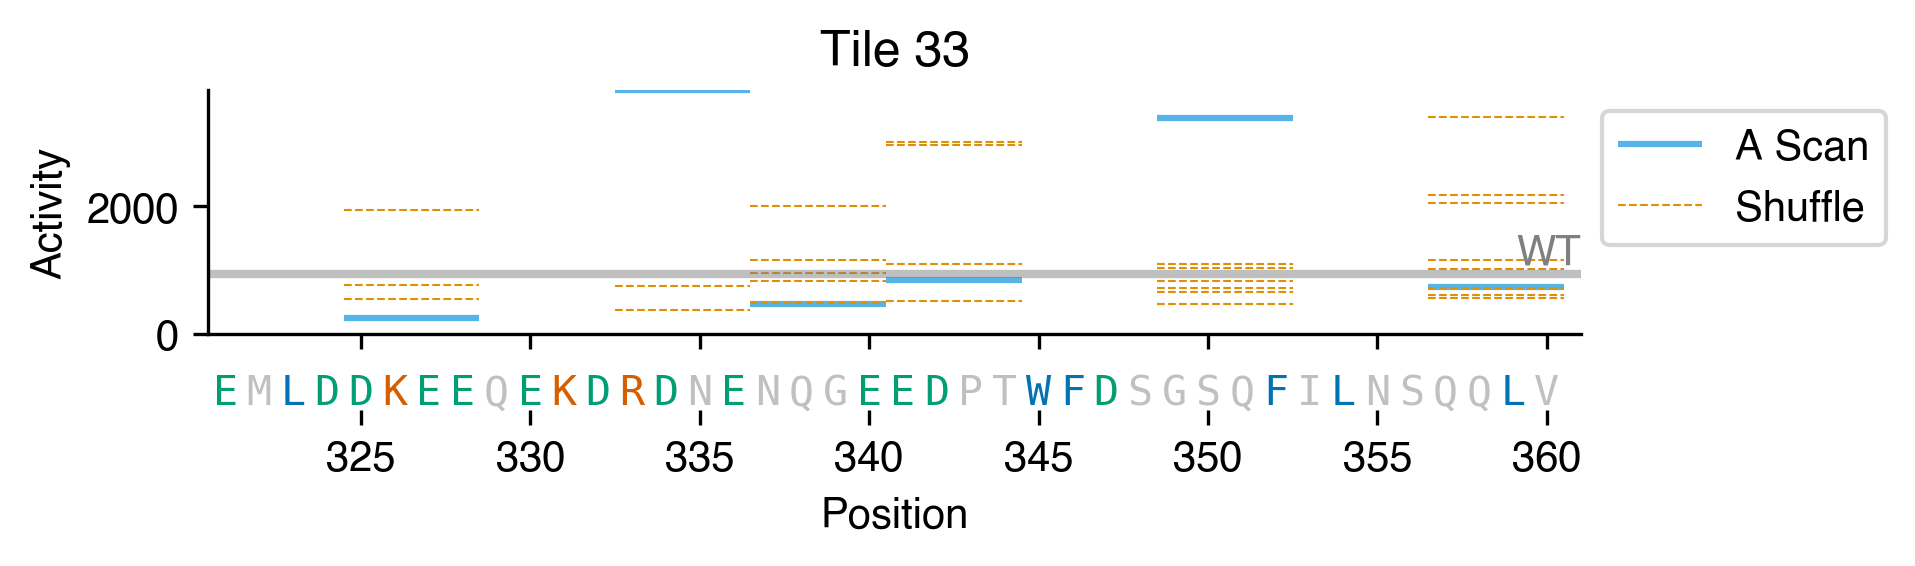

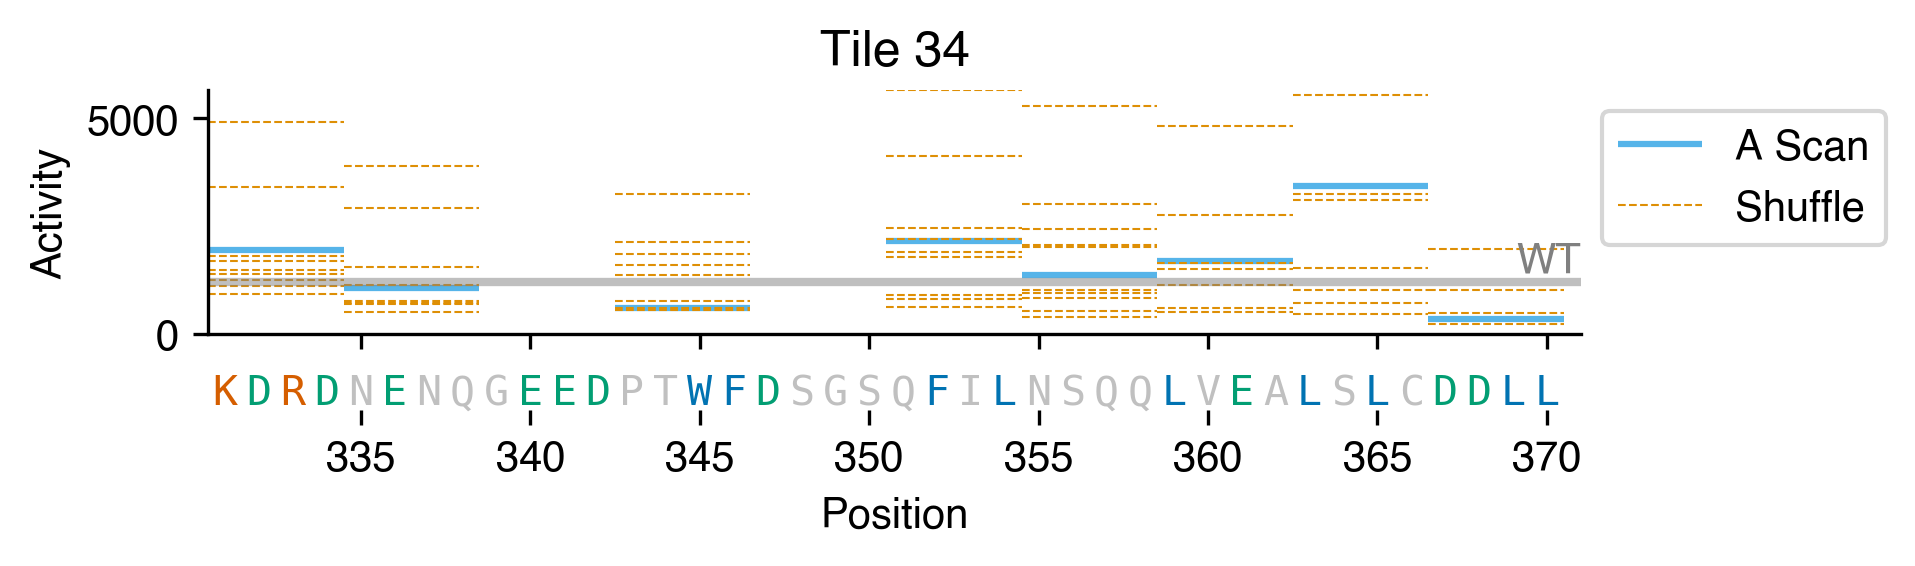

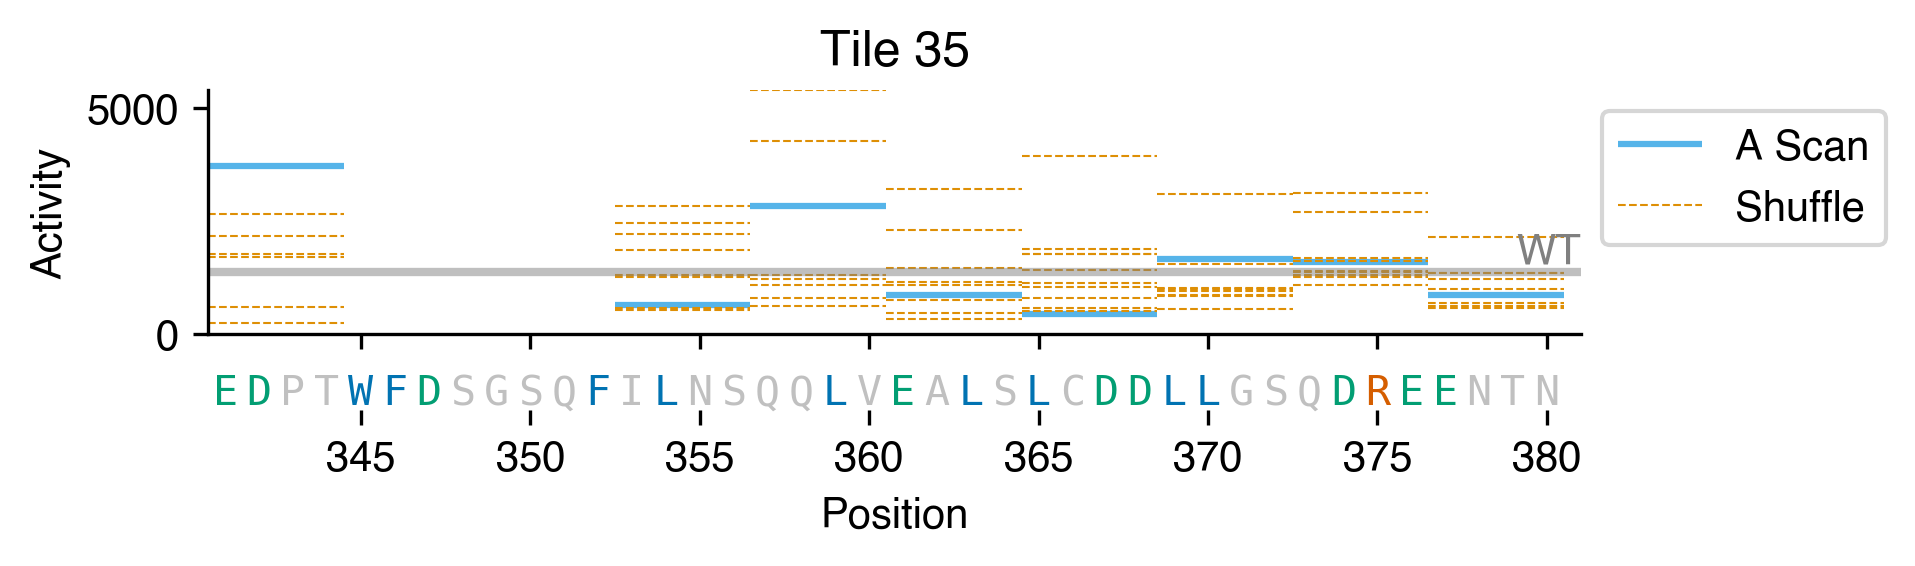

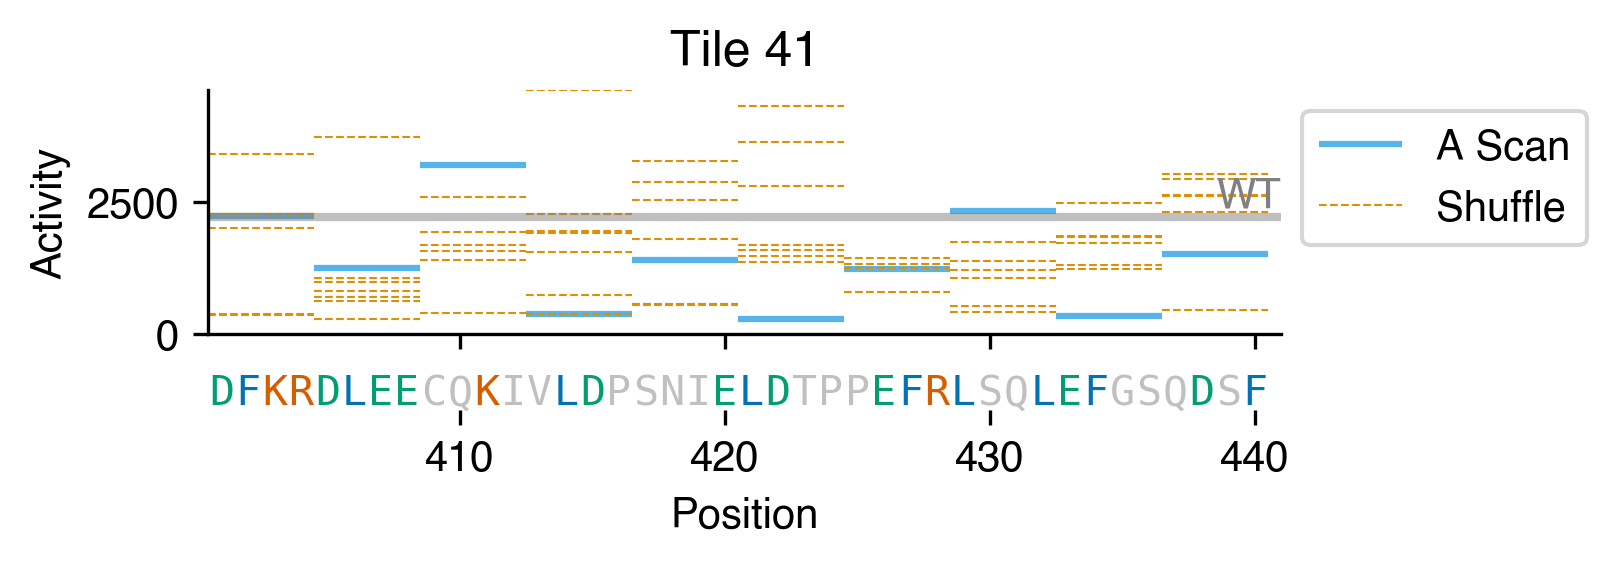

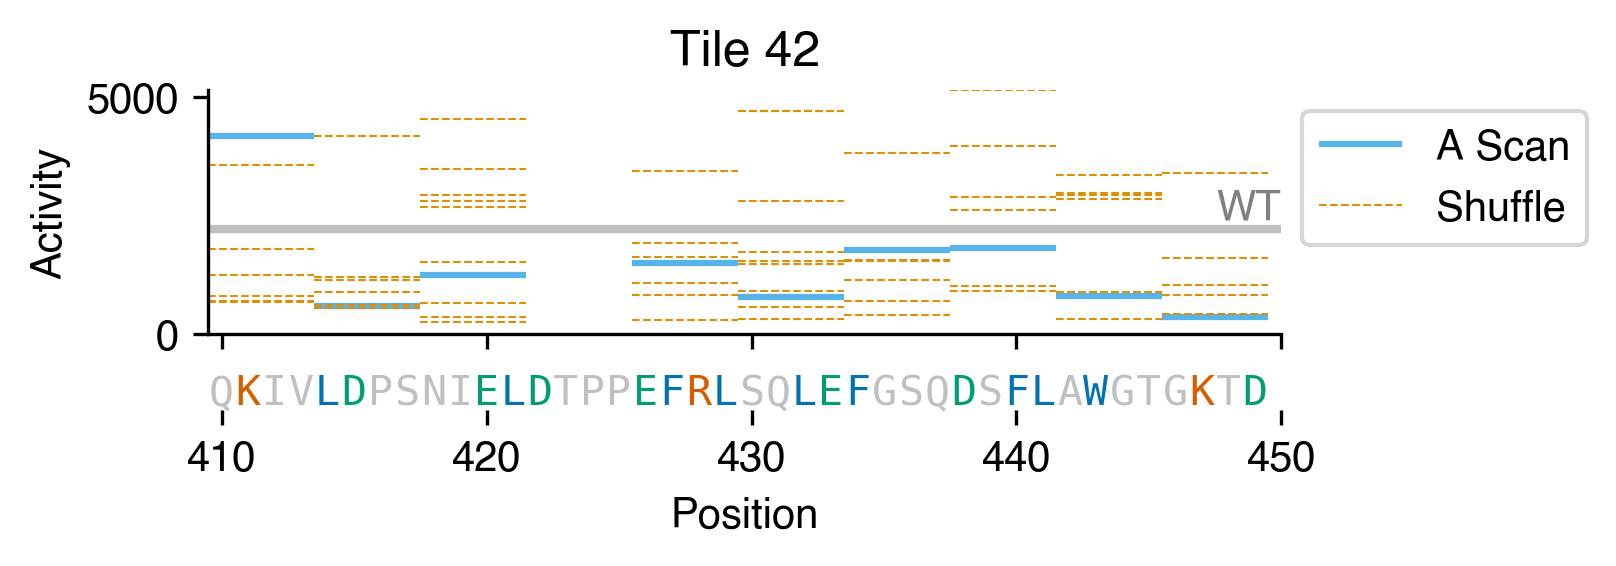

In [221]:
for tile_num in list(set(shuffle_vars_with_diff["tile"]) & set(Ascan_s_with_diff["tile_num"])):
    plot_tile_Ascan_and_shuffles(tile_num)
    #plt.savefig("../output/figures/shuffles_and_Ascan/" + str(tile_num) + ".png")

In [127]:
shuffle_Ascan_lined_up[shuffle_Ascan_lined_up["tile_num"] == 33][["var_start", "var_end_adj", "Activity_S3_1_var_A", "Activity_S3_1_var_shuffle"]]

,var_start,var_end_adj,Activity_S3_1_var_A,Activity_S3_1_var_shuffle
0,325,329,253.483884,NaN
1,325,329,253.483884,NaN
2,325,329,253.483884,NaN
3,325,329,253.483884,NaN
4,325,329,253.483884,NaN
5,325,329,253.483884,NaN
6,325,329,253.483884,541.754026
7,325,329,253.483884,1940.821638
8,325,329,253.483884,760.610922
9,325,329,253.483884,NaN
